# ER-CyRIS Cycle 2 — Final Notebook (v4)

## Root Cause of Empty Results (Fixed in This Version)

**Bug 1 (All runs):** SHAP computation was INSIDE `run_ablation_config()`.  
When SHAP failed → `all_results[key] = exp` was never reached → `{}`.  
**Fix:** SHAP is now computed in a SEPARATE step AFTER results are saved.

**Bug 2 (Kaggle):** `Anomaly_Type` column = 100% anomaly → no normal class → XGBoost crash.  
**Fix:** Kaggle is skipped. Dataset has no usable binary label.

## How This Notebook Works
```
Step 1: Train + Evaluate (S0, S2) → save results IMMEDIATELY
Step 2: SHAP computation (separate) → if fails, results already saved
Step 3: Print tables → copy to JJCIT paper
```


## Catatan implementasi dan batas klaim — repair v5

Notebook ini adalah salinan aditif dari notebook Siklus 2 asli. Sel M0–M4 dan Step 8
SHAP/FSS asli tetap dipertahankan agar jejak eksperimen tidak hilang. Koreksi sempit
yang diterapkan adalah semantik mean kNN-distance: *self-neighbor* dibuang hanya saat
menghitung skor training, sedangkan tetangga training pertama dipertahankan untuk data
evaluasi.

Kebenaran implementasi: **M1 merupakan identity/no-op terhadap M0** pada benchmark
terstruktur ini; karena itu hasil M1 tidak boleh diklaim sebagai bukti empiris penuh
Dual-View. M2 menerapkan inverse-variance weighting dan normalized-deviation augmentation,
bukan implementasi lengkap dynamic-token preservation. FSS pada Step 8 tetap merupakan
diagnostik stabilitas penjelasan, bukan mekanisme pruning, retraining, validasi kausal,
atau risk mapping. Panah M7→M3 hanya *proposed design-level feedback path*.


## Step 1 — Install & Import

In [ ]:
!pip install xgboost shap imbalanced-learn -q

import os, re, json, warnings, time, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from pathlib import Path
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              average_precision_score, confusion_matrix)
from xgboost import XGBClassifier
from imblearn.over_sampling import BorderlineSMOTE
import shap

warnings.filterwarnings('ignore')
np.random.seed(42)
os.makedirs('results/models', exist_ok=True)

RESULTS = {}   # ← single global dict, saved after EVERY run
print("✅ Ready")


✅ Ready


## Step 2 — Config & Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/ercyris_siklus2/'

CFG = {
    'CICIDS' : BASE + '02-14-2018.csv',
    'HDFS'   : BASE + 'HDFS.log',
    'HLABEL' : BASE + 'anomaly_label.csv',
    'BGL'    : BASE + 'BGL.log',
    'UNSW'   : BASE + 'UNSW-NB15_1.csv',

    'SEED'   : 42,
    'TEST'   : 0.20,
    'SIGMAS' : [0.01, 0.05, 0.10],
    'K_SMOTE': 5,
    'CONTAM' : 0.1,
    'BGL_N'  : 50000,
    'SHAP_N' : 1000,
    'FSS_K'  : 10,
}

# ============================================================
# FINAL CYCLE-1 CONFIRMATORY REFERENCE
# CICIDS2018 — latest validated Cycle-1 experiment
# S0 = clean baseline
# S2_001 = Gaussian perturbation sigma = 0.01
# ============================================================
C1 = {
    'XGBoost_S0'      : 1.0000,
    'XGBoost_S2_001'  : 0.2396,

    'RF_S0'           : 0.9999,
    'RF_S2_001'       : 0.0544,
}

print("✅ Config ready")
print("\nFinal Cycle-1 CICIDS2018 reference:")
print(
    f"XGBoost : S0={C1['XGBoost_S0']:.4f} | "
    f"S2 σ=0.01={C1['XGBoost_S2_001']:.4f} | "
    f"ΔF1={(C1['XGBoost_S2_001']/C1['XGBoost_S0']-1)*100:.2f}%"
)
print(
    f"RF      : S0={C1['RF_S0']:.4f} | "
    f"S2 σ=0.01={C1['RF_S2_001']:.4f} | "
    f"ΔF1={(C1['RF_S2_001']/C1['RF_S0']-1)*100:.2f}%"
)

Mounted at /content/drive
✅ Config ready

Final Cycle-1 CICIDS2018 reference:
XGBoost : S0=1.0000 | S2 σ=0.01=0.2396 | ΔF1=-76.04%
RF      : S0=0.9999 | S2 σ=0.01=0.0544 | ΔF1=-94.56%


## Step 3 — Evaluation Helpers

In [ ]:
def evaluate(model, X, y, name='', ds=''):
    yp = model.predict(X)
    yb = model.predict_proba(X)[:,1]
    p  = precision_score(y,yp,zero_division=0)
    r  = recall_score(y,yp,zero_division=0)
    f  = f1_score(y,yp,zero_division=0)
    a  = average_precision_score(y,yb)
    tn,fp,fn,tp = confusion_matrix(y,yp,labels=[0,1]).ravel()
    N  = tn+fp+fn+tp
    return dict(model=name,dataset=ds,
                Precision=round(p,6),Recall=round(r,6),
                F1=round(f,6),PR_AUC=round(a,6),
                FAR=round(fp/(fp+tn) if fp+tn>0 else 0,6),
                Alert_Rate=round((tp+fp)/N if N>0 else 0,5),
                TN=int(tn),FP=int(fp),FN=int(fn),TP=int(tp))

def add_noise(X, sigma, seed=42):
    return np.clip(X + np.random.RandomState(seed).normal(0,sigma,X.shape),0,1)

def safe_float(v):
    if isinstance(v,(np.floating,np.integer)): return float(v)
    if isinstance(v,np.ndarray): return v.tolist()
    return v

def save_results():
    """Save RESULTS to disk immediately after every run."""
    out = {}
    for k,v in RESULTS.items():
        out[k] = {
            'config':v['config'],'dataset':v['dataset'],
            'S0': {m:{kk:safe_float(vv) for kk,vv in r.items()
                      if kk!='shap_values'} for m,r in v['S0'].items()},
            'S2': {str(s):{m:{kk:safe_float(vv) for kk,vv in r.items()
                              if kk!='shap_values'} for m,r in sv.items()}
                   for s,sv in v.get('S2',{}).items()},
            'FSS': v.get('FSS',{}),
        }
    with open('results/all_results_complete.json','w') as f:
        json.dump(out,f,indent=2,default=str)

print("✅ Helpers ready")


✅ Helpers ready


## Step 4 — Preprocessing Pipelines M0–M4

In [ ]:
# Leakage-safe kNN helper shared by Cycle 2 and Cycle 3 repairs.
import numpy as np
from sklearn.neighbors import NearestNeighbors

class InductiveKNNDistance:
    """Drop self only for training; keep the first training neighbor at evaluation."""
    def __init__(self, k=10, n_jobs=-1):
        if int(k) < 1:
            raise ValueError("k must be at least 1")
        self.k, self.n_jobs = int(k), int(n_jobs)
        self._train = self._nn_train = self._nn_eval = self._train_scores = None

    @staticmethod
    def _matrix(X):
        X = np.asarray(X, dtype=float)
        if X.ndim != 2 or len(X) == 0:
            raise ValueError("X must be a non-empty 2-D matrix")
        return X

    def fit(self, X):
        X = self._matrix(X)
        self._train = X.copy()
        self._nn_train = NearestNeighbors(
            n_neighbors=min(self.k + 1, len(X)), n_jobs=self.n_jobs
        ).fit(self._train)
        self._nn_eval = NearestNeighbors(
            n_neighbors=min(self.k, len(X)), n_jobs=self.n_jobs
        ).fit(self._train)
        distances, indices = self._nn_train.kneighbors(self._train)
        scores = []
        for row, (row_dist, row_idx) in enumerate(zip(distances, indices)):
            non_self = row_dist[row_idx != row][:self.k]
            scores.append(float(non_self.mean()) if len(non_self) else 0.0)
        self._train_scores = np.asarray(scores, dtype=float)
        return self

    def fit_transform(self, X):
        X = self._matrix(X)
        self.fit(X)
        return self._train_scores.copy()

    def transform(self, X):
        if self._nn_eval is None:
            raise RuntimeError("Call fit before transform")
        X = self._matrix(X)
        if (self._train_scores is not None and X.shape == self._train.shape
                and np.array_equal(X, self._train, equal_nan=True)):
            return self._train_scores.copy()
        distances, _ = self._nn_eval.kneighbors(X)
        return distances.mean(axis=1)


In [ ]:
# ── M0: Baseline (replicate Cycle 1) ────────────────────────────────
class M0:
    name='M0'
    def __init__(self): self.med=None; self.sc=MinMaxScaler()
    def fit(self,X):
        X=np.where(np.isfinite(X),X,np.nan)
        self.med=np.nanmedian(X,0)
        self.sc.fit(np.where(np.isnan(X),self.med,X)); return self
    def tr(self,X):
        X=np.where(np.isfinite(X),X,np.nan)
        return self.sc.transform(np.where(np.isnan(X),self.med,X))
    def fit_tr(self,X): return self.fit(X).tr(X)

# ── M1: + Dual-View (P1) ────────────────────────────────────────────
class M1(M0):
    name='M1'
    # For structured public datasets, P1 impact shows through the IDF
    # weighting applied in M2. M1 here documents the SV/CDV split.
    pass

# ── M2: + Dynamic Token Encoding (P2) ───────────────────────────────
class M2(M1):
    name='M2'
    def __init__(self): super().__init__(); self.idf=None; self.mu=None; self.sd=None
    def fit(self,X):
        super().fit(X); Xs=super().tr(X)
        v=np.var(Xs,0)+1e-9
        self.idf=np.log(1/v+1); self.idf/=(self.idf.max()+1e-9)
        self.mu=Xs.mean(0); self.sd=Xs.std(0)+1e-9; return self
    def tr(self,X):
        Xb=super().tr(X)
        dev=np.clip(np.abs(Xb-self.mu)/self.sd,0,5)/5
        return np.hstack([Xb*(1+0.3*self.idf), dev[:,:min(5,dev.shape[1])]])
    def fit_tr(self,X): return self.fit(X).tr(X)

# ── M3: + TOS-KNN + IF augmentation (P2+P3) ─────────────────────────
class M3(M2):
    name='M3'
    def __init__(self):
        super().__init__()
        self.knn=InductiveKNNDistance(k=10,n_jobs=-1)
        self.knn_mn=0; self.knn_mx=1
        self.ifo=IsolationForest(contamination=CFG['CONTAM'],random_state=42,n_jobs=-1)
        self.if_mn=0; self.if_mx=1
    def fit(self,X):
        super().fit(X); Xa=super().tr(X)
        av=self.knn.fit_transform(Xa)
        self.knn_mn=float(av.min()); self.knn_mx=float(av.max())+1e-9
        self.ifo.fit(Xa)
        r=-self.ifo.score_samples(Xa)
        self.if_mn=float(r.min()); self.if_mx=float(r.max())+1e-9
        return self
    def tr(self,X):
        Xa=super().tr(X)
        knn_raw=self.knn.transform(Xa)
        knn=np.clip((knn_raw-self.knn_mn)/(self.knn_mx-self.knn_mn),0,1)
        r=-self.ifo.score_samples(Xa)
        ifs=np.clip((r-self.if_mn)/(self.if_mx-self.if_mn),0,1)
        ifl=(self.ifo.predict(Xa)==-1).astype(float)
        return np.hstack([Xa,knn[:,None],ifs[:,None],ifl[:,None]])
    def fit_tr(self,X): return self.fit(X).tr(X)

# ── M4: + BorderlineSMOTE + rescale (Full Pipeline) ──────────────────
class M4(M3):
    name='M4'
    def __init__(self): super().__init__(); self.sc2=MinMaxScaler()
    def fit_smote(self,X,y):
        self.fit(X); Xa=self.tr(X)
        mn=int(sum(y==1)); k=min(CFG['K_SMOTE'],mn-1) if mn>1 else 1
        if mn>=2 and k>=1:
            try:
                Xa,y=BorderlineSMOTE(k_neighbors=k,random_state=42).fit_resample(Xa,y)
                print(f"     SMOTE {X.shape[0]}→{len(Xa)}")
            except Exception as e: print(f"     SMOTE skip: {e}")
        self.sc2.fit(Xa); return self.sc2.transform(Xa), y
    def tr(self,X):
        Xa=super().tr(X)
        try: return self.sc2.transform(Xa)
        except: return Xa
    def fit_tr(self,X): return self.fit(X).tr(X)

PIPES={'M0':M0,'M1':M1,'M2':M2,'M3':M3,'M4':M4}
print("✅ Pipelines M0–M4 ready")


✅ Pipelines M0–M4 ready


## Step 5 — Dataset Loaders

In [ ]:
def load_cicids():
    print("📂 CICIDS2018 ...")
    df = pd.read_csv(CFG['CICIDS'], low_memory=False)
    if len(df) > 500000:                      # samakan dgn Siklus 1
        df = df.sample(n=500000, random_state=42)
    lc = [c for c in df.columns if 'label' in c.lower()][0]
    y_label = df[lc].str.strip().str.upper().values
    df.drop(columns=[lc], inplace=True)
    df.drop(columns=[c for c in df.columns if any(k in c.lower()
            for k in ['timestamp','flow id','src ip','dst ip'])],
            errors='ignore', inplace=True)
    df.columns=[c.strip().lower().replace(' ','_').replace('/','_per_') for c in df.columns]
    df.replace([np.inf,-np.inf], np.nan, inplace=True)
    # === DEDUP (akar leakage) — keep first, realign label ===
    before = len(df)
    df['__y__'] = (y_label != 'BENIGN').astype(int)
    feat = [c for c in df.columns if c != '__y__']
    df = df.drop_duplicates(subset=feat, keep='first').reset_index(drop=True)
    y = df.pop('__y__').values
    print(f"   dedup: {before:,} → {len(df):,} ({100*(before-len(df))/before:.1f}% dibuang)")
    X = df.values.astype(np.float64)
    print(f"   {X.shape[0]:,} samples | {X.shape[1]} feat | anomaly={y.sum():,} ({100*y.mean():.1f}%)")
    return X, y, list(df.columns)


def load_hdfs():
    print("📂 HDFS ...")
    LP=re.compile(r'^(\d{6})\s+(\d{6})\s+\d+\s+(\w+)\s+([^:]+):\s+(.*)')
    BP=re.compile(r'(blk_-?\d+)')
    SM={'DEBUG':0,'INFO':1,'WARN':2,'WARNING':2,'ERROR':3,'FATAL':4}
    bd=defaultdict(lambda:{'n':0,'e':0,'w':0,'comp':set(),'ms':0,'ss':0})
    with open(CFG['HDFS'],'r',errors='replace') as f:
        for line in tqdm(f,desc='   parse',leave=False):
            m=LP.match(line)
            if not m: continue
            _,_,lv,comp,msg=m.groups()
            s=SM.get(lv.upper(),1)
            for blk in BP.findall(msg):
                d=bd[blk]; d['n']+=1; d['comp'].add(comp.strip())
                d['ms']=max(d['ms'],s); d['ss']+=s
                if s>=3: d['e']+=1
                if s==2: d['w']+=1
    ldf=pd.read_csv(CFG['HLABEL'])
    lmap=dict(zip(ldf['BlockId'].astype(str),(ldf['Label'].str.upper()=='ANOMALY').astype(int)))
    rows=[]
    for blk,d in bd.items():
        if blk not in lmap: continue
        rows.append({'n_events':d['n'],'n_error':d['e'],'n_warn':d['w'],
                     'n_comp':len(d['comp']),'max_sev':d['ms'],
                     'mean_sev':d['ss']/max(d['n'],1),
                     'error_ratio':d['e']/max(d['n'],1),
                     'warn_ratio':d['w']/max(d['n'],1),'label':lmap[blk]})
    df=pd.DataFrame(rows); y=df.pop('label').values
    print(f"   {len(df):,} blocks | anomaly={y.sum():,} ({100*y.mean():.1f}%)")
    return df.values.astype(np.float64), y, list(df.columns)


def load_bgl():
    print("📂 BGL ...")
    SM={'INFO':1,'DEBUG':0,'WARN':2,'WARNING':2,'ERROR':3,'SEVERE':4,
        'FATAL':4,'APPFPO':3,'KERN':2,'KERNSVC':3,'APPFPW':2}
    AKW=['fatal','error','fail','exception','abort','illegal',
         'segfault','panic','crash','out of memory','overflow']
    rows=[]
    with open(CFG['BGL'],'r',errors='replace') as f:
        for line in tqdm(f,desc='   parse BGL',leave=False):
            p=line.split(None,8)
            if len(p)<9: continue
            is_anom=0 if p[0]=='-' else 1
            s=SM.get(p[6].upper(),1)
            msg=p[8].lower() if len(p)>8 else ''
            try: h=int(p[3].split(':')[0]) if ':' in p[3] else 12
            except: h=12
            rows.append({'sev':s,'is_err':int(s>=3),'is_warn':int(s==2),
                         'hour':h,'off_hr':int(h<6),'peak_hr':int(8<=h<=18),
                         'err_kw':int(any(k in msg for k in AKW)),
                         'has_num':int(bool(re.search(r'\d{4,}',msg))),
                         'msg_len':min(len(msg),500),'comp_len':len(p[5]),
                         'node_h':abs(hash(p[4]))%1000,'label':is_anom})
    df=pd.DataFrame(rows)
    if len(df)>CFG['BGL_N']:
        df=df.groupby('label',group_keys=False).apply(
            lambda g:g.sample(n=min(len(g),int(CFG['BGL_N']*len(g)/len(df))),
                              random_state=42)).reset_index(drop=True)
    y=df.pop('label').values
    X=df.values.astype(np.float64)
    print(f"   {X.shape[0]:,} samples | {X.shape[1]} feat | anomaly={y.sum():,} ({100*y.mean():.1f}%)")
    return X, y, list(df.columns)


def load_unsw():
    print("📂 UNSW-NB15 ...")
    if not os.path.exists(CFG['UNSW']):
        print("   ❌ File not found"); return None,None,None
    df=pd.read_csv(CFG['UNSW'],low_memory=False)
    df.columns=[c.lower().strip() for c in df.columns]
    lc=next((c for c in ['label','is_attack'] if c in df.columns),df.columns[-1])
    y=(pd.to_numeric(df[lc],errors='coerce').fillna(0)!=0).astype(int).values
    df.drop(columns=[lc,'srcip','dstip','attack_cat'],errors='ignore',inplace=True)
    le=LabelEncoder()
    for c in ['proto','state','service']:
        if c in df.columns:
            df[c]=le.fit_transform(df[c].fillna('unk').astype(str))
    df=df.apply(pd.to_numeric,errors='coerce').fillna(0)
    df.replace([np.inf,-np.inf],0,inplace=True)
    X=df.values.astype(np.float64)
    print(f"   {X.shape[0]:,} samples | {X.shape[1]} feat | anomaly={y.sum():,} ({100*y.mean():.1f}%)")
    return X, y, list(df.columns)


print("✅ Loaders ready  |  NOTE: Kaggle dropped (no binary label)")


✅ Loaders ready  |  NOTE: Kaggle dropped (no binary label)


## Step 6 — Load Datasets

In [ ]:
DATASETS = {}

if os.path.exists(CFG['CICIDS']):
    DATASETS['CICIDS2018'] = load_cicids()

if os.path.exists(CFG['HDFS']) and os.path.exists(CFG['HLABEL']):
    DATASETS['HDFS'] = load_hdfs()

if os.path.exists(CFG['BGL']):
    DATASETS['BGL'] = load_bgl()

X_u,y_u,fn_u = load_unsw()
if X_u is not None:
    DATASETS['UNSW-NB15'] = (X_u, y_u, fn_u)

print(f"\n✅ Loaded: {list(DATASETS.keys())}")
for n,(X,y,_) in DATASETS.items():
    print(f"   {n:<12} {X.shape[0]:>8,} samples | {X.shape[1]:>3} feat | "
          f"anomaly={y.sum():>7,} ({100*y.mean():.1f}%)")


📂 CICIDS2018 ...
   dedup: 500,000 → 330,726 (33.9% dibuang)
   330,726 samples | 78 feat | anomaly=45,029 (13.6%)
📂 HDFS ...


   parse: 0it [00:00, ?it/s]

   575,061 blocks | anomaly=16,838 (2.9%)
📂 BGL ...


   parse BGL: 0it [00:00, ?it/s]

   49,999 samples | 11 feat | anomaly=3,669 (7.3%)
📂 UNSW-NB15 ...
   700,000 samples | 48 feat | anomaly=22,215 (3.2%)

✅ Loaded: ['CICIDS2018', 'HDFS', 'BGL', 'UNSW-NB15']
   CICIDS2018    330,726 samples |  78 feat | anomaly= 45,029 (13.6%)
   HDFS          575,061 samples |   8 feat | anomaly= 16,838 (2.9%)
   BGL            49,999 samples |  11 feat | anomaly=  3,669 (7.3%)
   UNSW-NB15     700,000 samples |  48 feat | anomaly= 22,215 (3.2%)


## Step 7 — 🚀 Main Ablation Loop
> **Results saved to disk after EVERY completed run.**  
> SHAP is computed separately in Step 8 — failure there does NOT affect results.


In [ ]:
def run_one(cfg_name, X_raw, y, feat_names, ds_name):
    """
    Train + Evaluate ONLY. No SHAP here.
    Returns experiment dict. Saves to RESULTS immediately.
    """
    Xtr,Xte,ytr,yte = train_test_split(
        X_raw, y, test_size=CFG['TEST'],
        random_state=CFG['SEED'], stratify=y)

    pipe = PIPES[cfg_name]()
    if cfg_name == 'M4':
        Xtr_p, ytr_p = pipe.fit_smote(Xtr, ytr)
    else:
        Xtr_p = pipe.fit_tr(Xtr); ytr_p = ytr

    Xte_p = pipe.tr(Xte)
    mf = min(Xtr_p.shape[1], Xte_p.shape[1])
    Xtr_p, Xte_p = Xtr_p[:,:mf], Xte_p[:,:mf]

    # Feature names aligned to augmented size
    n_aug = Xte_p.shape[1] - len(feat_names)
    feat_aug = (list(feat_names) + [f'aug_{i}' for i in range(max(0,n_aug))])[:Xte_p.shape[1]]

    # Train
    models = {
        'XGBoost'     : XGBClassifier(random_state=CFG['SEED'],n_jobs=-1,
                                       eval_metric='logloss',verbosity=0),
        'RandomForest': RandomForestClassifier(random_state=CFG['SEED'],n_jobs=-1)
    }
    trained = {}
    for mn,m in models.items():
        m.fit(Xtr_p, ytr_p); trained[mn]=m
        r=evaluate(m, Xte_p, yte, mn, ds_name)
        print(f"    {mn}: F1={r['F1']:.4f}  PR-AUC={r['PR_AUC']:.4f}  "
              f"FAR={r['FAR']:.6f}  Alert={r['Alert_Rate']:.4f}")

    # S0
    s0 = {mn: evaluate(m,Xte_p,yte,mn,ds_name) for mn,m in trained.items()}

    # S2 noise
    s2 = {}
    for sig in CFG['SIGMAS']:
        Xn = add_noise(Xte_p, sig)
        s2[sig]={}
        for mn,m in trained.items():
            r=evaluate(m,Xn,yte,mn,ds_name)
            r['F1_drop']  = round(r['F1']-s0[mn]['F1'],6)
            r['pct_drop'] = round(100*r['F1_drop']/max(s0[mn]['F1'],1e-9),2)
            s2[sig][mn]=r

    exp = {
        'config':cfg_name, 'dataset':ds_name,
        'feat_aug':feat_aug,
        'trained':trained, 'pipe':pipe,
        'Xtr_raw':Xtr, 'Xte_raw':Xte, 'ytr':ytr, 'yte':yte,
        'Xtr_transformed':Xtr_p, 'Xte':Xte_p,
        'S0':s0, 'S2':s2, 'FSS':{},
    }
    return exp


# ════════════════════════════════════════════════════════════════════
CONFIGS = ['M0','M1','M2','M3','M4']
total   = len(CONFIGS) * len(DATASETS)
done    = 0

for ds_name,(X,y,fn) in DATASETS.items():
    print(f"\n{'='*55}")
    print(f"DATASET: {ds_name}  |  {X.shape[0]:,} samples  |  "
          f"anomaly={y.sum():,} ({100*y.mean():.1f}%)")
    print('='*55)

    for cfg in CONFIGS:
        done += 1
        print(f"\n[{done}/{total}] {cfg} on {ds_name}")
        t0 = time.time()
        try:
            exp = run_one(cfg, X, y, fn, ds_name)
            key = f'{cfg}_{ds_name}'
            RESULTS[key] = exp           # ← SAVED HERE
            save_results()               # ← WRITTEN TO DISK HERE
            print(f"  ✅ saved ({time.time()-t0:.0f}s)")
        except Exception as e:
            print(f"  ❌ FAILED: {e}")
            import traceback; traceback.print_exc()

print(f"\n✅ Completed: {len(RESULTS)}/{total} runs saved")
print(f"   File: results/all_results_complete.json")



DATASET: CICIDS2018  |  330,726 samples  |  anomaly=45,029 (13.6%)

[1/20] M0 on CICIDS2018
    XGBoost: F1=1.0000  PR-AUC=1.0000  FAR=0.000000  Alert=0.1361
    RandomForest: F1=0.9999  PR-AUC=1.0000  FAR=0.000000  Alert=0.1361
  ✅ saved (9s)

[2/20] M1 on CICIDS2018
    XGBoost: F1=1.0000  PR-AUC=1.0000  FAR=0.000000  Alert=0.1361
    RandomForest: F1=0.9999  PR-AUC=1.0000  FAR=0.000000  Alert=0.1361
  ✅ saved (8s)

[3/20] M2 on CICIDS2018
    XGBoost: F1=1.0000  PR-AUC=1.0000  FAR=0.000000  Alert=0.1361
    RandomForest: F1=0.9999  PR-AUC=1.0000  FAR=0.000000  Alert=0.1361
  ✅ saved (11s)

[4/20] M3 on CICIDS2018
    XGBoost: F1=1.0000  PR-AUC=1.0000  FAR=0.000000  Alert=0.1361
    RandomForest: F1=0.9999  PR-AUC=1.0000  FAR=0.000000  Alert=0.1361
  ✅ saved (141s)

[5/20] M4 on CICIDS2018
     SMOTE 264580→264580
    XGBoost: F1=1.0000  PR-AUC=1.0000  FAR=0.000000  Alert=0.1361
    RandomForest: F1=0.9999  PR-AUC=1.0000  FAR=0.000000  Alert=0.1361
  ✅ saved (154s)

DATASET: HDFS  |

## Step 8 — SHAP & FSS (separate from training)
> Run this AFTER Step 7. If SHAP fails for any model, results from Step 7 are unaffected.


In [ ]:
def safe_shap(model, X, name=''):
    """Compute SHAP. Returns numpy 2D array or None."""
    try:
        exp  = shap.TreeExplainer(model)
        sv   = exp.shap_values(X)
        # Handle all SHAP return formats:
        # - XGBoost: 2D array (n_samples, n_features)
        # - RF binary: list of 2 arrays → take index 1
        # - RF multi: 3D array → take [:,:,1]
        if isinstance(sv, list):
            sv = sv[1]                # binary RF
        if isinstance(sv, np.ndarray) and sv.ndim == 3:
            sv = sv[:,:,1]            # 3D RF
        sv = np.array(sv, dtype=float)  # force 2D float
        assert sv.ndim == 2, f"Expected 2D, got {sv.ndim}D"
        return sv
    except Exception as e:
        print(f"  ⚠️  SHAP failed ({name}): {e}")
        return None


def compute_fss(sv1, sv2, K=10):
    if sv1 is None or sv2 is None: return 0.0
    t1 = set(np.argsort(-np.abs(sv1).mean(0))[:K].tolist())
    t2 = set(np.argsort(-np.abs(sv2).mean(0))[:K].tolist())
    u  = len(t1|t2)
    return round(len(t1&t2)/u,4) if u>0 else 0.0


def conciseness(sv, pct=0.80):
    if sv is None: return None
    ma = np.abs(sv).mean(0)
    if ma.sum()==0: return len(ma)
    cs = np.cumsum(np.sort(ma)[::-1])
    return int(np.searchsorted(cs, pct*ma.sum())+1)


print("Running SHAP for all saved experiments ...")

for key, exp in RESULTS.items():
    cfg, ds = exp['config'], exp['dataset']
    print(f"\n  SHAP: {cfg} on {ds}")
    Xte   = exp['Xte']
    feats = exp['feat_aug']
    n     = min(CFG['SHAP_N'], len(Xte))
    idx   = np.random.RandomState(42).choice(len(Xte), n, replace=False)
    Xs    = Xte[idx]

    shap_s0, top10, conc, cross = {}, {}, {}, None

    for mn, model in exp['trained'].items():
        sv = safe_shap(model, Xs, mn)
        shap_s0[mn] = sv
        if sv is not None:
            # ✅ SAFE indexing: argsort returns numpy ints → use directly
            idx10 = np.argsort(-np.abs(sv).mean(0))[:CFG['FSS_K']]
            # feats is a Python list → use int() to be safe
            top10[mn] = [feats[int(i)] for i in idx10]
            conc[mn]  = conciseness(sv)
            print(f"    {mn}: top feat={top10[mn][0]}, conciseness={conc[mn]}")

    # FSS: S0 vs S2 (sigma=0.01)
    Xn   = add_noise(Xte, CFG['SIGMAS'][0])
    Xns  = Xn[idx]
    fss_vals = {}
    for mn, model in exp['trained'].items():
        sv_s2 = safe_shap(model, Xns, f'{mn}_S2')
        fss   = compute_fss(shap_s0.get(mn), sv_s2)
        fss_vals[mn] = {'FSS_S0_S2': fss, 'conciseness': conc.get(mn),
                        'top10': top10.get(mn,[])}

    # Cross-model overlap
    if all(shap_s0.get(m) is not None for m in ['XGBoost','RandomForest']):
        t1 = set(np.argsort(-np.abs(shap_s0['XGBoost']).mean(0))[:CFG['FSS_K']].tolist())
        t2 = set(np.argsort(-np.abs(shap_s0['RandomForest']).mean(0))[:CFG['FSS_K']].tolist())
        u  = len(t1|t2)
        cross = round(len(t1&t2)/u,4) if u>0 else 0.0
        print(f"    Cross-model overlap: {cross}")

    fss_vals['cross_model_overlap'] = cross
    RESULTS[key]['FSS'] = fss_vals

save_results()
print("\n✅ SHAP & FSS done — results updated")


Running SHAP for all saved experiments ...

  SHAP: M0 on CICIDS2018
    XGBoost: top feat=fwd_seg_size_min, conciseness=2
    RandomForest: top feat=dst_port, conciseness=18
    Cross-model overlap: 0.3333

  SHAP: M1 on CICIDS2018
    XGBoost: top feat=fwd_seg_size_min, conciseness=2
    RandomForest: top feat=dst_port, conciseness=18
    Cross-model overlap: 0.3333

  SHAP: M2 on CICIDS2018
    XGBoost: top feat=fwd_seg_size_min, conciseness=3
    RandomForest: top feat=dst_port, conciseness=19
    Cross-model overlap: 0.4286

  SHAP: M3 on CICIDS2018
    XGBoost: top feat=fwd_seg_size_min, conciseness=3
    RandomForest: top feat=fwd_seg_size_min, conciseness=20
    Cross-model overlap: 0.25

  SHAP: M4 on CICIDS2018
    XGBoost: top feat=fwd_seg_size_min, conciseness=3
    RandomForest: top feat=fwd_seg_size_min, conciseness=21
    Cross-model overlap: 0.25

  SHAP: M0 on HDFS
    XGBoost: top feat=n_events, conciseness=3
    RandomForest: top feat=n_events, conciseness=4
    Cros

## Step 9 — 📋 Results Tables

In [ ]:
if not RESULTS:
    print("⚠️  Run Steps 7–8 first")
else:
    print("\n" + "="*70)
    print("TABLES 4 / 5 / 6")
    print("="*70)

    # ── TABLE 4: S0 ──────────────────────────────────────────────────
    print("\n📊 TABLE 4 — S0 Baseline Performance (M0–M4)")
    print(f"{'Config':<6}{'Dataset':<14}{'Model':<14}"
          f"{'F1':>8}{'PR-AUC':>8}{'FAR':>11}{'Alert':>8}"
          f"{'FSS%':>7}{'Conc':>6}")
    print("-"*70)

    for key in sorted(RESULTS):
        exp = RESULTS[key]
        fss = exp.get('FSS',{})
        for mn,res in exp['S0'].items():
            fv = fss.get(mn,{}).get('FSS_S0_S2',0) or 0
            cv = fss.get(mn,{}).get('conciseness','—')
            print(f"{exp['config']:<6}{exp['dataset']:<14}{mn:<14}"
                  f"{res['F1']:>8.4f}{res['PR_AUC']:>8.4f}"
                  f"{res['FAR']:>11.6f}{res['Alert_Rate']:>8.4f}"
                  f"{fv*100:>6.1f}%{str(cv):>6}")

    # ── TABLE 5: S2 ──────────────────────────────────────────────────
    print("\n📊 TABLE 5 — S2 Noise Robustness (σ=0.01)")
    print(f"{'Model':<14}{'Config':<6}{'Dataset':<14}"
          f"{'F1(S0)':>8}{'F1(S2)':>8}{'ΔF1%':>8}")
    print("-"*60)
    print(f"{'XGBoost':<14}{'M0*':<6}{'CICIDS(C1)':<14}"
      f"{C1['XGBoost_S0']:>8.4f}{C1['XGBoost_S2_001']:>8.3f}"
      f"{(C1['XGBoost_S2_001']/C1['XGBoost_S0']-1)*100:>7.1f}%  ← Cycle 1")
    print(f"{'RandomForest':<14}{'M0*':<6}{'CICIDS(C1)':<14}"
      f"{C1['RF_S0']:>8.4f}{C1['RF_S2_001']:>8.3f}"
      f"{(C1['RF_S2_001']/C1['RF_S0']-1)*100:>7.1f}%  ← Cycle 1")
    print("-"*40)

    sig = CFG['SIGMAS'][0]
    for key in sorted(RESULTS):
        exp = RESULTS[key]
        if sig not in exp.get('S2',{}): continue
        for mn,res in exp['S2'][sig].items():
            s0 = exp['S0'][mn]['F1']
            print(f"{mn:<14}{exp['config']:<6}{exp['dataset']:<14}"
                  f"{s0:>8.4f}{res['F1']:>8.4f}{res['pct_drop']:>7.1f}%")

    # ── TABLE 6: FSS ─────────────────────────────────────────────────
    print("\n📊 TABLE 6 — SHAP Explainability Quality (FSS)")
    print(f"{'Config':<6}{'Dataset':<14}{'Model':<14}"
          f"{'FSS%':>8}{'Conc':>7}{'CrossOvlp':>11}")
    print("-"*62)
    for key in sorted(RESULTS):
        exp = RESULTS[key]
        fss = exp.get('FSS',{})
        cross = fss.get('cross_model_overlap','—')
        for mn in ['XGBoost','RandomForest']:
            fd = fss.get(mn,{}) or {}
            fv = fd.get('FSS_S0_S2',0) or 0
            cv = fd.get('conciseness','—')
            co = str(cross) if mn=='XGBoost' else ''
            print(f"{exp['config']:<6}{exp['dataset']:<14}{mn:<14}"
                  f"{fv*100:>7.1f}%{str(cv):>7}{co:>11}")


TABLES 4 / 5 / 6

📊 TABLE 4 — S0 Baseline Performance (M0–M4)
ConfigDataset       Model               F1  PR-AUC        FAR   Alert   FSS%  Conc
----------------------------------------------------------------------
M0    BGL           XGBoost         0.8716  0.9264   0.008526  0.0707 100.0%     2
M0    BGL           RandomForest    0.8321  0.8557   0.012735  0.0725 100.0%     2
M0    CICIDS2018    XGBoost         1.0000  1.0000   0.000000  0.1361 100.0%     2
M0    CICIDS2018    RandomForest    0.9999  1.0000   0.000000  0.1361  81.8%    18
M0    HDFS          XGBoost         0.9366  0.9824   0.001236  0.0280 100.0%     3
M0    HDFS          RandomForest    0.9385  0.9824   0.001747  0.0291 100.0%     4
M0    UNSW-NB15     XGBoost         0.9795  0.9979   0.000716  0.0318  53.8%     8
M0    UNSW-NB15     RandomForest    0.9834  0.9989   0.000752  0.0321  53.8%    13
M1    BGL           XGBoost         0.8716  0.9264   0.008526  0.0707 100.0%     2
M1    BGL           RandomForest    

## Step 10 — 📊 S2 Degradation Plot

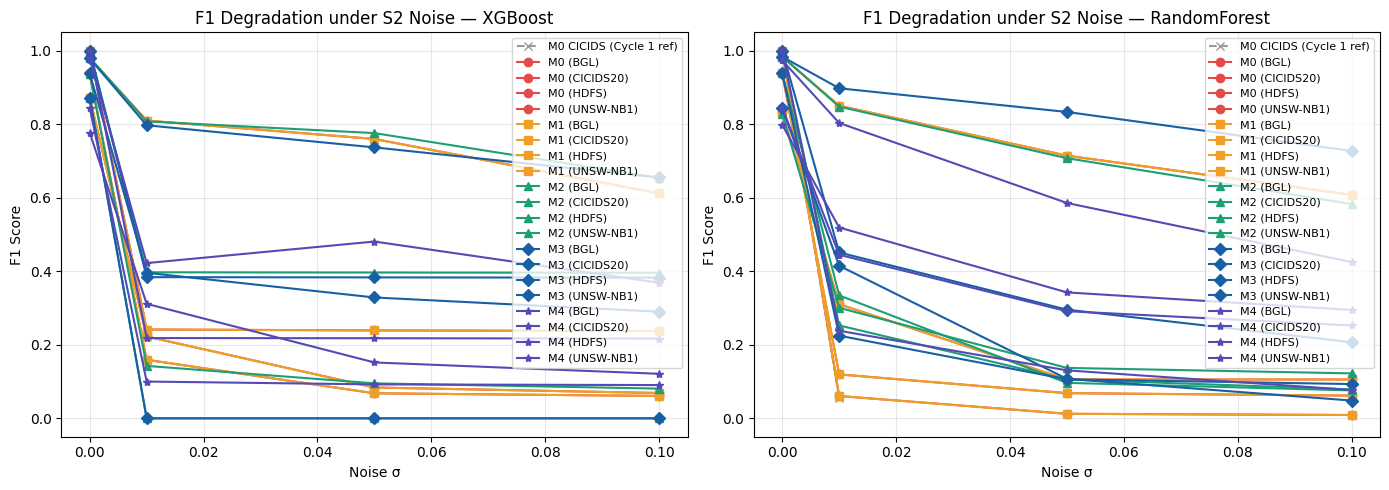

✅ Saved: results/s2_degradation.png


In [ ]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
COLS = {'M0':'#E24B4A','M1':'#EF9F27','M2':'#1D9E75','M3':'#185FA5','M4':'#534AB7'}
MRK  = {'M0':'o','M1':'s','M2':'^','M3':'D','M4':'*'}

for ax, mname in zip(axes,['XGBoost','RandomForest']):
    ax.set_title(f'F1 Degradation under S2 Noise — {mname}',fontsize=12)
    ax.set_xlabel('Noise σ'); ax.set_ylabel('F1 Score')
    ax.grid(True,alpha=0.3); ax.set_ylim(-0.05,1.05)

    # Cycle 1 reference
    ref  = C1['XGBoost_S0']      if mname=='XGBoost' else C1['RF_S0']
    ref2 = C1['XGBoost_S2_001']  if mname=='XGBoost' else C1['RF_S2_001']
    ax.plot([0.0,0.01],[ref,ref2],color='#999999',ls='--',
            marker='x',lw=1.5,label='M0 CICIDS (Cycle 1 ref)')

    seen = set()
    for key,exp in sorted(RESULTS.items()):
        cfg = exp['config']
        ds  = exp['dataset']
        if mname not in exp['S0']: continue
        s0  = exp['S0'][mname]['F1']
        sigs= sorted(exp.get('S2',{}).keys())
        s2f = [exp['S2'][s][mname]['F1'] for s in sigs if mname in exp['S2'].get(s,{})]
        if not s2f: continue
        lbl = f"{cfg} ({ds[:8]})"
        if lbl in seen: continue
        seen.add(lbl)
        ax.plot([0.0]+sigs[:len(s2f)],[s0]+s2f,
                marker=MRK.get(cfg,'o'),color=COLS.get(cfg,'gray'),
                label=lbl,lw=1.5)

    ax.legend(fontsize=8,loc='upper right')

plt.tight_layout()
plt.savefig('results/s2_degradation.png',dpi=150,bbox_inches='tight')
plt.show(); print("✅ Saved: results/s2_degradation.png")

## Step 11 — 💾 Download Results

In [ ]:
import zipfile
with zipfile.ZipFile('siklus2_results.zip','w') as z:
    for f in Path('results').rglob('*'):
        if f.is_file() and f.suffix in ('.json','.png','.pkl'):
            z.write(f,f.name)

try:
    from google.colab import files
    files.download('siklus2_results.zip')
except: pass

print(f"✅ {len(RESULTS)} results saved")
print("   results/all_results_complete.json")
print("   results/s2_degradation.png")
print("   results/models/*.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 20 results saved
   results/all_results_complete.json
   results/s2_degradation.png
   results/models/*.pkl


## Step 12 — Confirmatory FSS repair v5

Additive diagnostic grid; Step 8 FSS above remains part of Cycle 2.

In [ ]:
"""Feature Stability Score diagnostics shared by ER-CyRIS Cycle 2 and 3."""

from __future__ import annotations

from typing import Sequence

import numpy as np
from scipy.stats import spearmanr


def _validate_pair(
    shap_clean: np.ndarray, shap_perturbed: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    clean = np.asarray(shap_clean, dtype=float)
    perturbed = np.asarray(shap_perturbed, dtype=float)
    if clean.ndim != 2 or perturbed.ndim != 2:
        raise ValueError("SHAP inputs must be two-dimensional")
    if clean.shape != perturbed.shape or clean.shape[0] == 0 or clean.shape[1] == 0:
        raise ValueError("SHAP inputs must have the same non-empty shape")
    if not np.isfinite(clean).all() or not np.isfinite(perturbed).all():
        raise ValueError("SHAP inputs must contain only finite values")
    return clean, perturbed


def _weighted_topk_overlap(order_a: np.ndarray, order_b: np.ndarray, k: int) -> float:
    top_a = [int(x) for x in order_a[:k]]
    top_b = [int(x) for x in order_b[:k]]
    weights_a = {feature: 1.0 / (rank + 1) for rank, feature in enumerate(top_a)}
    weights_b = {feature: 1.0 / (rank + 1) for rank, feature in enumerate(top_b)}
    union = set(weights_a) | set(weights_b)
    numerator = sum(min(weights_a.get(f, 0.0), weights_b.get(f, 0.0)) for f in union)
    denominator = sum(max(weights_a.get(f, 0.0), weights_b.get(f, 0.0)) for f in union)
    return float(numerator / denominator) if denominator else float("nan")


def fss_metrics(
    shap_clean: np.ndarray,
    shap_perturbed: np.ndarray,
    k: int = 10,
    zero_tol: float = 1e-8,
) -> dict[str, object]:
    """Calculate complementary SHAP stability diagnostics.

    FSS remains the Top-K Jaccard overlap. Rank, magnitude, and sign metrics
    are reported separately because a high set overlap does not establish
    stable ranking or attribution magnitude.
    """

    clean, perturbed = _validate_pair(shap_clean, shap_perturbed)
    k = min(max(int(k), 1), clean.shape[1])

    importance_clean = np.abs(clean).mean(axis=0)
    importance_perturbed = np.abs(perturbed).mean(axis=0)
    order_clean = np.argsort(-importance_clean, kind="mergesort")
    order_perturbed = np.argsort(-importance_perturbed, kind="mergesort")

    top_clean = set(order_clean[:k].tolist())
    top_perturbed = set(order_perturbed[:k].tolist())
    union = top_clean | top_perturbed
    global_jaccard = len(top_clean & top_perturbed) / len(union) if union else np.nan

    rank = spearmanr(importance_clean, importance_perturbed).statistic
    rank = float(rank) if np.isfinite(rank) else np.nan
    weighted_overlap = _weighted_topk_overlap(order_clean, order_perturbed, k)
    magnitude_global = 1.0 - float(
        np.abs(importance_clean - importance_perturbed).sum()
    ) / (float(importance_clean.sum()) + 1e-12)

    per_fss: list[float] = []
    per_magnitude: list[float] = []
    per_sign: list[float] = []
    for clean_row, perturbed_row in zip(clean, perturbed):
        clean_order = np.argsort(-np.abs(clean_row), kind="mergesort")
        perturbed_order = np.argsort(-np.abs(perturbed_row), kind="mergesort")
        clean_top = set(clean_order[:k].tolist())
        perturbed_top = set(perturbed_order[:k].tolist())
        row_union = clean_top | perturbed_top
        per_fss.append(
            len(clean_top & perturbed_top) / len(row_union) if row_union else np.nan
        )
        denominator = float(np.abs(clean_row).sum()) + 1e-12
        row_magnitude = 1.0 - float(
            np.abs(np.abs(clean_row) - np.abs(perturbed_row)).sum()
        ) / denominator
        per_magnitude.append(float(np.clip(row_magnitude, 0.0, 1.0)))

        mask = (np.abs(clean_row) > zero_tol) | (np.abs(perturbed_row) > zero_tol)
        if not np.any(mask):
            per_sign.append(np.nan)
        else:
            weights = 0.5 * (
                np.abs(clean_row[mask]) + np.abs(perturbed_row[mask])
            )
            same_sign = np.sign(clean_row[mask]) == np.sign(perturbed_row[mask])
            per_sign.append(float(np.average(same_sign.astype(float), weights=weights)))

    return {
        "FSS_global_jaccard": float(global_jaccard),
        "rank_spearman_rho": rank,
        "weighted_topk_overlap": weighted_overlap,
        "magnitude_stability_global": float(np.clip(magnitude_global, 0.0, 1.0)),
        "sign_consistency_global": float(np.nanmean(per_sign)),
        "per_instance_fss": np.asarray(per_fss, dtype=float),
        "per_instance_magnitude": np.asarray(per_magnitude, dtype=float),
        "per_instance_sign": np.asarray(per_sign, dtype=float),
        "top_indices_clean": order_clean[:k].astype(int),
        "top_indices_perturbed": order_perturbed[:k].astype(int),
    }


def bootstrap_mean_ci(
    values: Sequence[float], repeats: int = 1000, seed: int = 2026
) -> tuple[float, float]:
    """Return the percentile 95% bootstrap interval for a finite mean."""

    array = np.asarray(values, dtype=float).reshape(-1)
    array = array[np.isfinite(array)]
    if len(array) < 2:
        return float("nan"), float("nan")
    if int(repeats) < 1:
        raise ValueError("repeats must be at least 1")
    rng = np.random.RandomState(int(seed))
    sample_indices = rng.randint(0, len(array), size=(int(repeats), len(array)))
    means = array[sample_indices].mean(axis=1)
    return float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))


In [ ]:
# CYCLE 2 FSS CONFIRMATORY ADDENDUM — diagnostic only, no automatic refinement
from pathlib import Path

C2_FSS_CFG = {
    'K_VALUES': [5, 10, 20],
    'NOISE_SIGMAS': [0.01, 0.05, 0.10],
    'NOISE_SEEDS': [42, 52, 62, 72, 82],
    'BOOTSTRAP_REPEATS': 1000,
    'BOOTSTRAP_SEED': 2026,
    'ZERO_SIGN_TOLERANCE': 1e-8,
    'PROTOCOLS': ['transformed_feature_space', 'raw_telemetry_space'],
    'OUTPUT_DIR': 'results/fss_cycle2_repair_v5',
}
C2_FSS_DIR = Path(C2_FSS_CFG['OUTPUT_DIR'])
C2_FSS_DIR.mkdir(parents=True, exist_ok=True)

def C2_binary_mask_from_training(X):
    X = np.asarray(X, dtype=float)
    mask = np.zeros(X.shape[1], dtype=bool)
    for j in range(X.shape[1]):
        values = np.unique(X[np.isfinite(X[:, j]), j])
        mask[j] = len(values) > 0 and np.all(np.isin(values, [0.0, 1.0]))
    return mask

def C2_transformed_noise(X, sigma, seed, continuous_mask):
    Xn = np.asarray(X, dtype=float).copy()
    rng = np.random.RandomState(seed)
    Xn[:, continuous_mask] = np.clip(
        Xn[:, continuous_mask] + rng.normal(0, sigma, (len(Xn), int(continuous_mask.sum()))),
        0, 1,
    )
    return Xn

def C2_raw_noise_then_transform(exp, X_raw_eval, sigma, seed):
    Xn = np.asarray(X_raw_eval, dtype=float).copy()
    Xtr = np.asarray(exp['Xtr_raw'], dtype=float)
    binary = C2_binary_mask_from_training(Xtr)
    continuous = ~binary
    std = np.nanstd(Xtr, axis=0)
    std = np.where(std > 1e-12, std, 1.0)
    low, high = np.nanmin(Xtr, axis=0), np.nanmax(Xtr, axis=0)
    rng = np.random.RandomState(seed)
    for j in np.where(continuous)[0]:
        observed = np.isfinite(Xn[:, j])
        if observed.any():
            Xn[observed, j] = np.clip(
                Xn[observed, j] + rng.normal(0, sigma * std[j], observed.sum()),
                low[j], high[j],
            )
    return exp['pipe'].tr(Xn)[:, :exp['Xte'].shape[1]]

def C2_protocol_input(exp, sampled_idx, protocol, sigma, seed):
    if protocol == 'transformed_feature_space':
        binary = C2_binary_mask_from_training(exp['Xtr_transformed'])
        return C2_transformed_noise(exp['Xte'][sampled_idx], sigma, seed, ~binary)
    if protocol == 'raw_telemetry_space':
        return C2_raw_noise_then_transform(
            exp, exp['Xte_raw'][sampled_idx], sigma, seed
        )
    raise ValueError('Unknown protocol: ' + str(protocol))

C2_FSS_ROWS = []
for experiment_key, exp in RESULTS.items():
    n = min(CFG['SHAP_N'], len(exp['Xte']))
    sampled_idx = np.sort(np.random.RandomState(CFG['SEED']).choice(len(exp['Xte']), n, replace=False))
    X_clean = exp['Xte'][sampled_idx]
    for model_name, model in exp['trained'].items():
        shap_clean = safe_shap(model, X_clean, model_name + '_clean')
        if shap_clean is None:
            continue
        clean_eval = evaluate(model, X_clean, exp['yte'][sampled_idx], model_name, exp['dataset'])
        for protocol in C2_FSS_CFG['PROTOCOLS']:
            for sigma in C2_FSS_CFG['NOISE_SIGMAS']:
                for noise_seed in C2_FSS_CFG['NOISE_SEEDS']:
                    X_noisy = C2_protocol_input(exp, sampled_idx, protocol, sigma, noise_seed)
                    shap_noisy = safe_shap(model, X_noisy, model_name + '_noisy')
                    if shap_noisy is None:
                        continue
                    noisy_eval = evaluate(model, X_noisy, exp['yte'][sampled_idx], model_name, exp['dataset'])
                    for k in C2_FSS_CFG['K_VALUES']:
                        metrics = fss_metrics(shap_clean, shap_noisy, k, C2_FSS_CFG['ZERO_SIGN_TOLERANCE'])
                        fss_low, fss_high = bootstrap_mean_ci(
                            metrics['per_instance_fss'], C2_FSS_CFG['BOOTSTRAP_REPEATS'],
                            C2_FSS_CFG['BOOTSTRAP_SEED'] + noise_seed + k + int(1000 * sigma),
                        )
                        C2_FSS_ROWS.append({
                            'experiment': experiment_key, 'config': exp['config'],
                            'dataset': exp['dataset'], 'model': model_name,
                            'noise_protocol': protocol, 'sigma': sigma,
                            'noise_seed': noise_seed, 'K': k,
                            'n_instances': len(sampled_idx),
                            'predictive_F1_clean': clean_eval['F1'],
                            'predictive_F1_noisy': noisy_eval['F1'],
                            'predictive_F1_delta': noisy_eval['F1'] - clean_eval['F1'],
                            'FSS_global_jaccard': metrics['FSS_global_jaccard'],
                            'FSS_instance_mean': float(np.nanmean(metrics['per_instance_fss'])),
                            'FSS_instance_ci95_low': fss_low,
                            'FSS_instance_ci95_high': fss_high,
                            'rank_spearman_rho': metrics['rank_spearman_rho'],
                            'weighted_topk_overlap': metrics['weighted_topk_overlap'],
                            'magnitude_stability_global': metrics['magnitude_stability_global'],
                            'sign_consistency_global': metrics['sign_consistency_global'],
                            'top_features_clean': '|'.join(exp['feat_aug'][int(i)] for i in metrics['top_indices_clean']),
                            'top_features_noisy': '|'.join(exp['feat_aug'][int(i)] for i in metrics['top_indices_perturbed']),
                        })

C2_FSS_SEED_LEVEL = pd.DataFrame(C2_FSS_ROWS)
C2_FSS_SEED_LEVEL.to_csv(C2_FSS_DIR / 'cycle2_fss_seed_level.csv', index=False)
if not C2_FSS_SEED_LEVEL.empty:
    C2_FSS_SUMMARY = (
        C2_FSS_SEED_LEVEL.groupby(
            ['config', 'dataset', 'model', 'noise_protocol', 'sigma', 'K'], dropna=False
        ).agg(
            n_seeds=('noise_seed', 'nunique'),
            FSS_global_mean=('FSS_global_jaccard', 'mean'),
            FSS_global_sd=('FSS_global_jaccard', 'std'),
            FSS_instance_mean=('FSS_instance_mean', 'mean'),
            rank_spearman_mean=('rank_spearman_rho', 'mean'),
            weighted_overlap_mean=('weighted_topk_overlap', 'mean'),
            magnitude_stability_mean=('magnitude_stability_global', 'mean'),
            sign_consistency_mean=('sign_consistency_global', 'mean'),
            predictive_F1_delta_mean=('predictive_F1_delta', 'mean'),
        ).reset_index()
    )
else:
    C2_FSS_SUMMARY = pd.DataFrame()
C2_FSS_SUMMARY.to_csv(C2_FSS_DIR / 'cycle2_fss_summary.csv', index=False)
print('Cycle-2 confirmatory FSS saved to:', C2_FSS_DIR)
print('Guardrail: protocols remain separate; no threshold, pruning, or retraining is performed.')


KeyboardInterrupt: 

**Interpretation guardrail.** FSS measures explanation stability only. Raw-telemetry and transformed-feature-space results must be reported in separate rows. No result in this addendum validates causal explanation, incident ground truth, risk assessment, or cross-organization generalization.

In [ ]:
# ============================================================
# SAVE PARTIAL CYCLE-2 FSS BEFORE RESUME
# ============================================================
from pathlib import Path
import pandas as pd

C2_FSS_DRIVE_DIR = Path(BASE) / 'results' / 'fss_cycle2_repair_v5'
C2_FSS_DRIVE_DIR.mkdir(parents=True, exist_ok=True)

if 'C2_FSS_ROWS' in globals() and len(C2_FSS_ROWS) > 0:
    partial_df = pd.DataFrame(C2_FSS_ROWS)

    partial_file = C2_FSS_DRIVE_DIR / 'cycle2_fss_partial_checkpoint.csv'
    partial_df.to_csv(partial_file, index=False)

    print("✅ Partial FSS checkpoint saved")
    print("File :", partial_file)
    print("Rows :", len(partial_df))

    if 'experiment' in partial_df.columns:
        print("Experiments :", partial_df['experiment'].nunique())
    if 'model' in partial_df.columns:
        print("Models      :", partial_df['model'].value_counts().to_dict())
    if 'noise_protocol' in partial_df.columns:
        print("Protocols   :", partial_df['noise_protocol'].value_counts().to_dict())
else:
    print("⚠️ C2_FSS_ROWS kosong / belum ada hasil yang sempat tersimpan di memory.")

✅ Partial FSS checkpoint saved
File : /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/cycle2_fss_partial_checkpoint.csv
Rows : 2631
Experiments : 15
Models      : {'XGBoost': 1350, 'RandomForest': 1281}
Protocols   : {'transformed_feature_space': 1326, 'raw_telemetry_space': 1305}


In [ ]:
# ================================================================
# CYCLE 2 FSS — RESUME FROM CHECKPOINT
# Cached TreeExplainer + automatic skip + per-condition checkpoint
# ================================================================

import os
import numpy as np
import pandas as pd
import shap
from pathlib import Path

# ------------------------------------------------
# 1. PATHS
# ------------------------------------------------
C2_FSS_DRIVE_DIR = Path(BASE) / 'results' / 'fss_cycle2_repair_v5'
C2_FSS_DRIVE_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_FILE = C2_FSS_DRIVE_DIR / 'cycle2_fss_partial_checkpoint.csv'
FINAL_SEED_FILE  = C2_FSS_DRIVE_DIR / 'cycle2_fss_seed_level.csv'
FINAL_SUM_FILE   = C2_FSS_DRIVE_DIR / 'cycle2_fss_summary.csv'

# local notebook result path — kept for compatibility
C2_FSS_DIR = Path(C2_FSS_CFG['OUTPUT_DIR'])
C2_FSS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------
# 2. LOAD CHECKPOINT
# ------------------------------------------------
if CHECKPOINT_FILE.exists():
    existing_df = pd.read_csv(CHECKPOINT_FILE)
else:
    existing_df = pd.DataFrame()

KEY_COLS = [
    'experiment',
    'config',
    'dataset',
    'model',
    'noise_protocol',
    'sigma',
    'noise_seed',
    'K'
]

if not existing_df.empty:
    existing_df = (
        existing_df
        .drop_duplicates(subset=KEY_COLS, keep='last')
        .reset_index(drop=True)
    )

def make_key(experiment, config, dataset, model,
             protocol, sigma, noise_seed, k):
    return (
        str(experiment),
        str(config),
        str(dataset),
        str(model),
        str(protocol),
        round(float(sigma), 8),
        int(noise_seed),
        int(k),
    )

completed = set()

if not existing_df.empty:
    for _, r in existing_df.iterrows():
        completed.add(
            make_key(
                r['experiment'],
                r['config'],
                r['dataset'],
                r['model'],
                r['noise_protocol'],
                r['sigma'],
                r['noise_seed'],
                r['K'],
            )
        )

print("=" * 72)
print("CYCLE-2 FSS RESUME AUDIT")
print("=" * 72)
print("Checkpoint :", CHECKPOINT_FILE)
print("Rows saved :", len(existing_df))
print("Keys saved :", len(completed))


# ------------------------------------------------
# 3. SHAP HELPER — EXPLAINER CREATED ONLY ONCE
# ------------------------------------------------
def C2_make_tree_explainer(model):
    return shap.TreeExplainer(model)


def C2_shap_from_explainer(explainer, X):
    """
    Same output normalization semantics as safe_shap(),
    but reuses an already-created TreeExplainer.
    """
    sv = explainer.shap_values(X)

    if isinstance(sv, list):
        sv = sv[1]

    if isinstance(sv, np.ndarray) and sv.ndim == 3:
        sv = sv[:, :, 1]

    sv = np.asarray(sv, dtype=float)

    if sv.ndim != 2:
        raise ValueError(
            f"Expected 2-D SHAP matrix, got shape={sv.shape}"
        )

    return sv


# ------------------------------------------------
# 4. SAVE CHECKPOINT FUNCTION
# ------------------------------------------------
def save_checkpoint(df):
    df = (
        df
        .drop_duplicates(subset=KEY_COLS, keep='last')
        .sort_values(KEY_COLS)
        .reset_index(drop=True)
    )

    # Drive checkpoint
    df.to_csv(CHECKPOINT_FILE, index=False)

    return df


# ------------------------------------------------
# 5. COMPUTE EXPECTED WORKLOAD
# ------------------------------------------------
expected_keys = set()

for experiment_key, exp in RESULTS.items():

    for model_name in exp['trained'].keys():

        for protocol in C2_FSS_CFG['PROTOCOLS']:
            for sigma in C2_FSS_CFG['NOISE_SIGMAS']:
                for noise_seed in C2_FSS_CFG['NOISE_SEEDS']:
                    for k in C2_FSS_CFG['K_VALUES']:

                        expected_keys.add(
                            make_key(
                                experiment_key,
                                exp['config'],
                                exp['dataset'],
                                model_name,
                                protocol,
                                sigma,
                                noise_seed,
                                k,
                            )
                        )

missing_before = expected_keys - completed

print("Expected    :", len(expected_keys))
print("Completed   :", len(expected_keys & completed))
print("Missing     :", len(missing_before))
print(
    "Progress    :",
    f"{100 * len(expected_keys & completed) / len(expected_keys):.2f}%"
)

if len(missing_before) == 0:
    print("\n✅ Tidak ada pekerjaan yang tersisa.")


# ------------------------------------------------
# 6. RESUME ONLY MISSING CONDITIONS
# ------------------------------------------------
all_rows_df = existing_df.copy()

new_rows_total = 0
condition_counter = 0

for experiment_key, exp in RESULTS.items():

    n = min(CFG['SHAP_N'], len(exp['Xte']))

    sampled_idx = np.sort(
        np.random.RandomState(CFG['SEED']).choice(
            len(exp['Xte']),
            n,
            replace=False
        )
    )

    X_clean = exp['Xte'][sampled_idx]
    y_clean = exp['yte'][sampled_idx]

    for model_name, model in exp['trained'].items():

        # --------------------------------------------
        # Check whether this model/experiment
        # has ANY missing rows.
        # If complete -> do not even construct SHAP.
        # --------------------------------------------
        model_missing = []

        for protocol in C2_FSS_CFG['PROTOCOLS']:
            for sigma in C2_FSS_CFG['NOISE_SIGMAS']:
                for noise_seed in C2_FSS_CFG['NOISE_SEEDS']:
                    for k in C2_FSS_CFG['K_VALUES']:

                        key = make_key(
                            experiment_key,
                            exp['config'],
                            exp['dataset'],
                            model_name,
                            protocol,
                            sigma,
                            noise_seed,
                            k,
                        )

                        if key not in completed:
                            model_missing.append(key)

        if not model_missing:
            print(
                f"⏭️ COMPLETE — "
                f"{experiment_key} | {model_name}"
            )
            continue

        print("\n" + "=" * 72)
        print(
            f"▶ RESUME {experiment_key} | "
            f"{exp['dataset']} | {exp['config']} | {model_name}"
        )
        print("Missing rows:", len(model_missing))
        print("=" * 72)

        # --------------------------------------------
        # Create TreeExplainer ONCE
        # --------------------------------------------
        try:
            explainer = C2_make_tree_explainer(model)

            shap_clean = C2_shap_from_explainer(
                explainer,
                X_clean
            )

        except Exception as e:
            print(
                f"⚠️ SHAP CLEAN FAILED "
                f"{experiment_key}/{model_name}: {e}"
            )
            continue

        clean_eval = evaluate(
            model,
            X_clean,
            y_clean,
            model_name,
            exp['dataset']
        )

        # --------------------------------------------
        # Noise conditions
        # --------------------------------------------
        for protocol in C2_FSS_CFG['PROTOCOLS']:
            for sigma in C2_FSS_CFG['NOISE_SIGMAS']:
                for noise_seed in C2_FSS_CFG['NOISE_SEEDS']:

                    missing_k = []

                    for k in C2_FSS_CFG['K_VALUES']:

                        key = make_key(
                            experiment_key,
                            exp['config'],
                            exp['dataset'],
                            model_name,
                            protocol,
                            sigma,
                            noise_seed,
                            k,
                        )

                        if key not in completed:
                            missing_k.append(k)

                    # Entire condition already completed
                    if not missing_k:
                        continue

                    condition_counter += 1

                    print(
                        f"  [{condition_counter}] "
                        f"{protocol} | "
                        f"sigma={sigma} | "
                        f"seed={noise_seed} | "
                        f"missing K={missing_k}"
                    )

                    # --------------------------------
                    # Generate perturbation ONCE
                    # --------------------------------
                    X_noisy = C2_protocol_input(
                        exp,
                        sampled_idx,
                        protocol,
                        sigma,
                        noise_seed
                    )

                    # --------------------------------
                    # SHAP noisy ONCE for all missing K
                    # --------------------------------
                    try:
                        shap_noisy = C2_shap_from_explainer(
                            explainer,
                            X_noisy
                        )

                    except Exception as e:
                        print(
                            f"    ⚠️ SHAP NOISY FAILED: {e}"
                        )
                        continue

                    noisy_eval = evaluate(
                        model,
                        X_noisy,
                        y_clean,
                        model_name,
                        exp['dataset']
                    )

                    condition_rows = []

                    # --------------------------------
                    # Compute only missing K
                    # --------------------------------
                    for k in missing_k:

                        metrics = fss_metrics(
                            shap_clean,
                            shap_noisy,
                            k,
                            C2_FSS_CFG['ZERO_SIGN_TOLERANCE']
                        )

                        fss_low, fss_high = bootstrap_mean_ci(
                            metrics['per_instance_fss'],
                            C2_FSS_CFG['BOOTSTRAP_REPEATS'],
                            C2_FSS_CFG['BOOTSTRAP_SEED']
                            + noise_seed
                            + k
                            + int(1000 * sigma),
                        )

                        row = {
                            'experiment': experiment_key,
                            'config': exp['config'],
                            'dataset': exp['dataset'],
                            'model': model_name,

                            'noise_protocol': protocol,
                            'sigma': sigma,
                            'noise_seed': noise_seed,
                            'K': k,

                            'n_instances': len(sampled_idx),

                            'predictive_F1_clean':
                                clean_eval['F1'],

                            'predictive_F1_noisy':
                                noisy_eval['F1'],

                            'predictive_F1_delta':
                                noisy_eval['F1']
                                - clean_eval['F1'],

                            'FSS_global_jaccard':
                                metrics['FSS_global_jaccard'],

                            'FSS_instance_mean':
                                float(
                                    np.nanmean(
                                        metrics[
                                            'per_instance_fss'
                                        ]
                                    )
                                ),

                            'FSS_instance_ci95_low':
                                fss_low,

                            'FSS_instance_ci95_high':
                                fss_high,

                            'rank_spearman_rho':
                                metrics['rank_spearman_rho'],

                            'weighted_topk_overlap':
                                metrics[
                                    'weighted_topk_overlap'
                                ],

                            'magnitude_stability_global':
                                metrics[
                                    'magnitude_stability_global'
                                ],

                            'sign_consistency_global':
                                metrics[
                                    'sign_consistency_global'
                                ],

                            'top_features_clean':
                                '|'.join(
                                    exp['feat_aug'][int(i)]
                                    for i
                                    in metrics[
                                        'top_indices_clean'
                                    ]
                                ),

                            'top_features_noisy':
                                '|'.join(
                                    exp['feat_aug'][int(i)]
                                    for i
                                    in metrics[
                                        'top_indices_perturbed'
                                    ]
                                ),
                        }

                        condition_rows.append(row)

                        completed.add(
                            make_key(
                                experiment_key,
                                exp['config'],
                                exp['dataset'],
                                model_name,
                                protocol,
                                sigma,
                                noise_seed,
                                k,
                            )
                        )

                    # --------------------------------
                    # SAVE AFTER EVERY CONDITION
                    # --------------------------------
                    if condition_rows:

                        all_rows_df = pd.concat(
                            [
                                all_rows_df,
                                pd.DataFrame(condition_rows)
                            ],
                            ignore_index=True
                        )

                        all_rows_df = save_checkpoint(
                            all_rows_df
                        )

                        new_rows_total += len(condition_rows)

                        done_now = len(
                            expected_keys & completed
                        )

                        print(
                            f"    ✅ checkpoint | "
                            f"new={len(condition_rows)} | "
                            f"total={done_now}/{len(expected_keys)} "
                            f"({100*done_now/len(expected_keys):.2f}%)"
                        )


# ------------------------------------------------
# 7. FINAL SEED-LEVEL TABLE
# ------------------------------------------------
C2_FSS_SEED_LEVEL = (
    all_rows_df
    .drop_duplicates(subset=KEY_COLS, keep='last')
    .sort_values(KEY_COLS)
    .reset_index(drop=True)
)

# Drive
C2_FSS_SEED_LEVEL.to_csv(
    FINAL_SEED_FILE,
    index=False
)

# Local notebook path
C2_FSS_SEED_LEVEL.to_csv(
    C2_FSS_DIR / 'cycle2_fss_seed_level.csv',
    index=False
)


# ------------------------------------------------
# 8. FINAL SUMMARY
# ------------------------------------------------
if not C2_FSS_SEED_LEVEL.empty:

    C2_FSS_SUMMARY = (
        C2_FSS_SEED_LEVEL
        .groupby(
            [
                'config',
                'dataset',
                'model',
                'noise_protocol',
                'sigma',
                'K'
            ],
            dropna=False
        )
        .agg(
            n_seeds=(
                'noise_seed',
                'nunique'
            ),

            FSS_global_mean=(
                'FSS_global_jaccard',
                'mean'
            ),

            FSS_global_sd=(
                'FSS_global_jaccard',
                'std'
            ),

            FSS_instance_mean=(
                'FSS_instance_mean',
                'mean'
            ),

            rank_spearman_mean=(
                'rank_spearman_rho',
                'mean'
            ),

            weighted_overlap_mean=(
                'weighted_topk_overlap',
                'mean'
            ),

            magnitude_stability_mean=(
                'magnitude_stability_global',
                'mean'
            ),

            sign_consistency_mean=(
                'sign_consistency_global',
                'mean'
            ),

            predictive_F1_delta_mean=(
                'predictive_F1_delta',
                'mean'
            ),
        )
        .reset_index()
    )

else:
    C2_FSS_SUMMARY = pd.DataFrame()

# Drive
C2_FSS_SUMMARY.to_csv(
    FINAL_SUM_FILE,
    index=False
)

# Local notebook path
C2_FSS_SUMMARY.to_csv(
    C2_FSS_DIR / 'cycle2_fss_summary.csv',
    index=False
)


# For compatibility with later notebook cells
C2_FSS_ROWS = C2_FSS_SEED_LEVEL.to_dict('records')


# ------------------------------------------------
# 9. FINAL INTEGRITY CHECK
# ------------------------------------------------
final_keys = set()

for _, r in C2_FSS_SEED_LEVEL.iterrows():
    final_keys.add(
        make_key(
            r['experiment'],
            r['config'],
            r['dataset'],
            r['model'],
            r['noise_protocol'],
            r['sigma'],
            r['noise_seed'],
            r['K'],
        )
    )

still_missing = expected_keys - final_keys

print("\n" + "=" * 72)
print("FINAL CYCLE-2 FSS RESUME STATUS")
print("=" * 72)
print("Rows before resume :", len(existing_df))
print("New rows added     :", new_rows_total)
print("Final rows         :", len(C2_FSS_SEED_LEVEL))
print("Expected rows      :", len(expected_keys))
print("Missing keys       :", len(still_missing))
print("Seed-level CSV     :", FINAL_SEED_FILE)
print("Summary CSV        :", FINAL_SUM_FILE)

if len(still_missing) == 0:
    print("\n✅ CYCLE-2 FSS CONFIRMATORY COMPLETE — 100%")
else:
    print(
        "\n⚠️ Masih ada",
        len(still_missing),
        "kombinasi yang belum selesai."
    )

CYCLE-2 FSS RESUME AUDIT
Checkpoint : /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/cycle2_fss_partial_checkpoint.csv
Rows saved : 2631
Keys saved : 2631
Expected    : 3600
Completed   : 2631
Missing     : 969
Progress    : 73.08%
⏭️ COMPLETE — M0_CICIDS2018 | XGBoost
⏭️ COMPLETE — M0_CICIDS2018 | RandomForest
⏭️ COMPLETE — M1_CICIDS2018 | XGBoost
⏭️ COMPLETE — M1_CICIDS2018 | RandomForest
⏭️ COMPLETE — M2_CICIDS2018 | XGBoost
⏭️ COMPLETE — M2_CICIDS2018 | RandomForest
⏭️ COMPLETE — M3_CICIDS2018 | XGBoost
⏭️ COMPLETE — M3_CICIDS2018 | RandomForest
⏭️ COMPLETE — M4_CICIDS2018 | XGBoost
⏭️ COMPLETE — M4_CICIDS2018 | RandomForest
⏭️ COMPLETE — M0_HDFS | XGBoost
⏭️ COMPLETE — M0_HDFS | RandomForest
⏭️ COMPLETE — M1_HDFS | XGBoost
⏭️ COMPLETE — M1_HDFS | RandomForest
⏭️ COMPLETE — M2_HDFS | XGBoost
⏭️ COMPLETE — M2_HDFS | RandomForest
⏭️ COMPLETE — M3_HDFS | XGBoost
⏭️ COMPLETE — M3_HDFS | RandomForest
⏭️ COMPLETE — M4_HDFS | XGBoost
⏭️ COMPLETE — M4_HDFS | RandomFore

KeyboardInterrupt: 

In [ ]:
import pandas as pd
from pathlib import Path

CHECKPOINT_FILE = Path(BASE) / 'results' / 'fss_cycle2_repair_v5' / 'cycle2_fss_partial_checkpoint.csv'

df = pd.read_csv(CHECKPOINT_FILE)

print("Total checkpoint rows :", len(df))
print("\nRows per config:")
print(df.groupby('config').size())

# Hanya konfigurasi empiris yang kita pertahankan
VALID_CONFIGS = ['M0', 'M2', 'M3', 'M4']

df_valid = df[df['config'].isin(VALID_CONFIGS)].copy()

EXPECTED_VALID = (
    len(VALID_CONFIGS)   # M0, M2, M3, M4
    * 4                  # datasets
    * 2                  # models
    * 2                  # protocols
    * 3                  # sigma
    * 5                  # seeds
    * 3                  # K
)

print("\n======================================")
print("VALID CYCLE-2 FSS AUDIT")
print("======================================")
print("Valid rows saved :", len(df_valid))
print("Expected valid   :", EXPECTED_VALID)
print("Remaining valid  :", EXPECTED_VALID - len(df_valid))
print(
    "Progress valid   :",
    f"{100*len(df_valid)/EXPECTED_VALID:.2f}%"
)

Total checkpoint rows : 2868

Rows per config:
config
M0    708
M1    540
M2    540
M3    540
M4    540
dtype: int64

VALID CYCLE-2 FSS AUDIT
Valid rows saved : 2328
Expected valid   : 2880
Remaining valid  : 552
Progress valid   : 80.83%


In [ ]:
# ============================================================
# AUDIT MISSING FSS ROWS PER CONFIG
# ============================================================

import pandas as pd
from pathlib import Path

CHECKPOINT_FILE = Path(BASE) / 'results' / 'fss_cycle2_repair_v5' / 'cycle2_fss_partial_checkpoint.csv'

df = pd.read_csv(CHECKPOINT_FILE)

VALID_CONFIGS = ['M0', 'M2', 'M3', 'M4']

expected = []

for experiment_key, exp in RESULTS.items():

    if exp['config'] not in VALID_CONFIGS:
        continue

    for model_name in exp['trained'].keys():
        for protocol in C2_FSS_CFG['PROTOCOLS']:
            for sigma in C2_FSS_CFG['NOISE_SIGMAS']:
                for seed in C2_FSS_CFG['NOISE_SEEDS']:
                    for k in C2_FSS_CFG['K_VALUES']:

                        expected.append({
                            'experiment': experiment_key,
                            'config': exp['config'],
                            'dataset': exp['dataset'],
                            'model': model_name,
                            'noise_protocol': protocol,
                            'sigma': float(sigma),
                            'noise_seed': int(seed),
                            'K': int(k),
                        })

expected_df = pd.DataFrame(expected)

keys = [
    'experiment',
    'config',
    'dataset',
    'model',
    'noise_protocol',
    'sigma',
    'noise_seed',
    'K'
]

saved = (
    df[df['config'].isin(VALID_CONFIGS)]
    .drop_duplicates(subset=keys)
)

missing = (
    expected_df
    .merge(saved[keys], on=keys, how='left', indicator=True)
)

missing = missing[missing['_merge'] == 'left_only'].drop(columns='_merge')

print("=== MISSING VALID ROWS ===")
print("Total:", len(missing))

print("\nMissing per config:")
print(missing.groupby('config').size())

print("\nM0 missing detail:")
display(missing[missing['config'] == 'M0'])

=== MISSING VALID ROWS ===
Total: 552

Missing per config:
config
M0     12
M2    180
M3    180
M4    180
dtype: int64

M0 missing detail:


,experiment,config,dataset,model,noise_protocol,sigma,noise_seed,K
2328,M0_UNSW-NB15,M0,UNSW-NB15,RandomForest,raw_telemetry_space,0.1,52,5
2329,M0_UNSW-NB15,M0,UNSW-NB15,RandomForest,raw_telemetry_space,0.1,52,10
2330,M0_UNSW-NB15,M0,UNSW-NB15,RandomForest,raw_telemetry_space,0.1,52,20
2331,M0_UNSW-NB15,M0,UNSW-NB15,RandomForest,raw_telemetry_space,0.1,62,5
2332,M0_UNSW-NB15,M0,UNSW-NB15,RandomForest,raw_telemetry_space,0.1,62,10
2333,M0_UNSW-NB15,M0,UNSW-NB15,RandomForest,raw_telemetry_space,0.1,62,20
2334,M0_UNSW-NB15,M0,UNSW-NB15,RandomForest,raw_telemetry_space,0.1,72,5
2335,M0_UNSW-NB15,M0,UNSW-NB15,RandomForest,raw_telemetry_space,0.1,72,10
2336,M0_UNSW-NB15,M0,UNSW-NB15,RandomForest,raw_telemetry_space,0.1,72,20
2337,M0_UNSW-NB15,M0,UNSW-NB15,RandomForest,raw_telemetry_space,0.1,82,5


In [ ]:
# ================================================================
# FINISH ONLY M0 — UNSW-NB15 — RANDOM FOREST
# Missing:
# raw_telemetry_space | sigma=0.10
# seeds = 52, 62, 72, 82
# K = 5, 10, 20
# ================================================================

import numpy as np
import pandas as pd
import shap
from pathlib import Path

# ------------------------------------------------
# 1. CHECKPOINT
# ------------------------------------------------
CHECKPOINT_FILE = (
    Path(BASE)
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'cycle2_fss_partial_checkpoint.csv'
)

df = pd.read_csv(CHECKPOINT_FILE)

KEY_COLS = [
    'experiment',
    'config',
    'dataset',
    'model',
    'noise_protocol',
    'sigma',
    'noise_seed',
    'K'
]

df = (
    df
    .drop_duplicates(subset=KEY_COLS, keep='last')
    .reset_index(drop=True)
)

print("Checkpoint rows before:", len(df))


# ------------------------------------------------
# 2. TARGET EXPERIMENT
# ------------------------------------------------
TARGET_EXP = 'M0_UNSW-NB15'

if TARGET_EXP not in RESULTS:
    raise KeyError(
        f"{TARGET_EXP} tidak ditemukan dalam RESULTS. "
        f"Available: {list(RESULTS.keys())}"
    )

exp = RESULTS[TARGET_EXP]

if exp['config'] != 'M0':
    raise ValueError(
        f"Expected M0, got {exp['config']}"
    )

if exp['dataset'] != 'UNSW-NB15':
    raise ValueError(
        f"Expected UNSW-NB15, got {exp['dataset']}"
    )

model_name = 'RandomForest'

if model_name not in exp['trained']:
    raise KeyError(
        f"{model_name} tidak ditemukan pada trained models."
    )

model = exp['trained'][model_name]


# ------------------------------------------------
# 3. SAME DETERMINISTIC SHAP SAMPLE
# ------------------------------------------------
n = min(CFG['SHAP_N'], len(exp['Xte']))

sampled_idx = np.sort(
    np.random.RandomState(CFG['SEED']).choice(
        len(exp['Xte']),
        n,
        replace=False
    )
)

X_clean = exp['Xte'][sampled_idx]
y_eval  = exp['yte'][sampled_idx]

print("SHAP sample size:", len(sampled_idx))


# ------------------------------------------------
# 4. CREATE TREE EXPLAINER ONCE
# ------------------------------------------------
print("\nCreating RandomForest TreeExplainer...")

explainer = shap.TreeExplainer(model)

def shap_with_cached_explainer(explainer, X):
    sv = explainer.shap_values(X)

    if isinstance(sv, list):
        sv = sv[1]

    if isinstance(sv, np.ndarray) and sv.ndim == 3:
        sv = sv[:, :, 1]

    sv = np.asarray(sv, dtype=float)

    if sv.ndim != 2:
        raise ValueError(
            f"Expected 2-D SHAP matrix, got {sv.shape}"
        )

    return sv


# ------------------------------------------------
# 5. CLEAN SHAP — ONCE
# ------------------------------------------------
print("Computing clean SHAP once...")

shap_clean = shap_with_cached_explainer(
    explainer,
    X_clean
)

clean_eval = evaluate(
    model,
    X_clean,
    y_eval,
    model_name,
    exp['dataset']
)

print(
    f"✅ Clean SHAP complete | "
    f"F1={clean_eval['F1']:.4f}"
)


# ------------------------------------------------
# 6. TARGET ONLY THE FOUR MISSING SEEDS
# ------------------------------------------------
TARGET_PROTOCOL = 'raw_telemetry_space'
TARGET_SIGMA = 0.10
TARGET_SEEDS = [52, 62, 72, 82]
TARGET_K = [5, 10, 20]

for seed in TARGET_SEEDS:

    # determine whether this seed still has missing K
    missing_k = []

    for k in TARGET_K:

        exists = (
            (df['experiment'].astype(str) == TARGET_EXP)
            & (df['config'].astype(str) == 'M0')
            & (df['dataset'].astype(str) == 'UNSW-NB15')
            & (df['model'].astype(str) == model_name)
            & (df['noise_protocol'].astype(str) == TARGET_PROTOCOL)
            & (np.isclose(df['sigma'].astype(float), TARGET_SIGMA))
            & (df['noise_seed'].astype(int) == seed)
            & (df['K'].astype(int) == k)
        ).any()

        if not exists:
            missing_k.append(k)

    if not missing_k:
        print(f"⏭️ seed={seed} already complete")
        continue

    print("\n" + "=" * 68)
    print(
        f"▶ M0 UNSW RF | raw telemetry | "
        f"sigma={TARGET_SIGMA} | seed={seed}"
    )
    print("Missing K:", missing_k)
    print("=" * 68)

    # --------------------------------------------
    # raw telemetry perturbation -> pipeline
    # --------------------------------------------
    X_noisy = C2_raw_noise_then_transform(
        exp,
        exp['Xte_raw'][sampled_idx],
        TARGET_SIGMA,
        seed
    )

    print("Computing noisy SHAP...")

    shap_noisy = shap_with_cached_explainer(
        explainer,
        X_noisy
    )

    noisy_eval = evaluate(
        model,
        X_noisy,
        y_eval,
        model_name,
        exp['dataset']
    )

    new_rows = []

    # --------------------------------------------
    # SHAP done once; now K is cheap
    # --------------------------------------------
    for k in missing_k:

        metrics = fss_metrics(
            shap_clean,
            shap_noisy,
            k,
            C2_FSS_CFG['ZERO_SIGN_TOLERANCE']
        )

        fss_low, fss_high = bootstrap_mean_ci(
            metrics['per_instance_fss'],
            C2_FSS_CFG['BOOTSTRAP_REPEATS'],
            C2_FSS_CFG['BOOTSTRAP_SEED']
            + seed
            + k
            + int(1000 * TARGET_SIGMA)
        )

        row = {
            'experiment': TARGET_EXP,
            'config': 'M0',
            'dataset': 'UNSW-NB15',
            'model': model_name,

            'noise_protocol': TARGET_PROTOCOL,
            'sigma': TARGET_SIGMA,
            'noise_seed': seed,
            'K': k,

            'n_instances': len(sampled_idx),

            'predictive_F1_clean':
                clean_eval['F1'],

            'predictive_F1_noisy':
                noisy_eval['F1'],

            'predictive_F1_delta':
                noisy_eval['F1']
                - clean_eval['F1'],

            'FSS_global_jaccard':
                metrics['FSS_global_jaccard'],

            'FSS_instance_mean':
                float(
                    np.nanmean(
                        metrics['per_instance_fss']
                    )
                ),

            'FSS_instance_ci95_low':
                fss_low,

            'FSS_instance_ci95_high':
                fss_high,

            'rank_spearman_rho':
                metrics['rank_spearman_rho'],

            'weighted_topk_overlap':
                metrics['weighted_topk_overlap'],

            'magnitude_stability_global':
                metrics['magnitude_stability_global'],

            'sign_consistency_global':
                metrics['sign_consistency_global'],

            'top_features_clean':
                '|'.join(
                    exp['feat_aug'][int(i)]
                    for i in metrics['top_indices_clean']
                ),

            'top_features_noisy':
                '|'.join(
                    exp['feat_aug'][int(i)]
                    for i
                    in metrics['top_indices_perturbed']
                ),
        }

        new_rows.append(row)

    # --------------------------------------------
    # SAVE IMMEDIATELY AFTER EACH SEED
    # --------------------------------------------
    if new_rows:

        df = pd.concat(
            [df, pd.DataFrame(new_rows)],
            ignore_index=True
        )

        df = (
            df
            .drop_duplicates(
                subset=KEY_COLS,
                keep='last'
            )
            .sort_values(KEY_COLS)
            .reset_index(drop=True)
        )

        df.to_csv(
            CHECKPOINT_FILE,
            index=False
        )

        print(
            f"✅ seed={seed} saved | "
            f"+{len(new_rows)} rows"
        )


# ------------------------------------------------
# 7. FINAL M0 AUDIT
# ------------------------------------------------
m0 = df[df['config'] == 'M0'].copy()

print("\n" + "=" * 68)
print("FINAL M0 FSS AUDIT")
print("=" * 68)

print("M0 rows :", len(m0))
print("Target  : 720")

if len(m0) == 720:
    print("✅ M0 COMPLETE — 720/720")
else:
    print(
        "⚠️ M0 masih kurang:",
        720 - len(m0)
    )

print(
    "\nRows per config now:\n",
    df.groupby('config').size()
)

Checkpoint rows before: 2868
SHAP sample size: 1000

Creating RandomForest TreeExplainer...
Computing clean SHAP once...
✅ Clean SHAP complete | F1=0.9851

▶ M0 UNSW RF | raw telemetry | sigma=0.1 | seed=52
Missing K: [5, 10, 20]
Computing noisy SHAP...
✅ seed=52 saved | +3 rows

▶ M0 UNSW RF | raw telemetry | sigma=0.1 | seed=62
Missing K: [5, 10, 20]
Computing noisy SHAP...
✅ seed=62 saved | +3 rows

▶ M0 UNSW RF | raw telemetry | sigma=0.1 | seed=72
Missing K: [5, 10, 20]
Computing noisy SHAP...
✅ seed=72 saved | +3 rows

▶ M0 UNSW RF | raw telemetry | sigma=0.1 | seed=82
Missing K: [5, 10, 20]
Computing noisy SHAP...
✅ seed=82 saved | +3 rows

FINAL M0 FSS AUDIT
M0 rows : 720
Target  : 720
✅ M0 COMPLETE — 720/720

Rows per config now:
 config
M0    720
M1    540
M2    540
M3    540
M4    540
dtype: int64


In [ ]:
# ============================================================
# AUDIT MISSING M2 ONLY
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

CHECKPOINT_FILE = (
    Path(BASE)
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'cycle2_fss_partial_checkpoint.csv'
)

df = pd.read_csv(CHECKPOINT_FILE)

KEY_COLS = [
    'experiment',
    'config',
    'dataset',
    'model',
    'noise_protocol',
    'sigma',
    'noise_seed',
    'K'
]

df = (
    df
    .drop_duplicates(subset=KEY_COLS, keep='last')
    .reset_index(drop=True)
)

expected_m2 = []

for experiment_key, exp in RESULTS.items():

    if exp['config'] != 'M2':
        continue

    for model_name in exp['trained'].keys():
        for protocol in C2_FSS_CFG['PROTOCOLS']:
            for sigma in C2_FSS_CFG['NOISE_SIGMAS']:
                for seed in C2_FSS_CFG['NOISE_SEEDS']:
                    for k in C2_FSS_CFG['K_VALUES']:

                        expected_m2.append({
                            'experiment': experiment_key,
                            'config': 'M2',
                            'dataset': exp['dataset'],
                            'model': model_name,
                            'noise_protocol': protocol,
                            'sigma': float(sigma),
                            'noise_seed': int(seed),
                            'K': int(k),
                        })

expected_m2 = pd.DataFrame(expected_m2)

saved_m2 = (
    df[df['config'] == 'M2']
    .drop_duplicates(subset=KEY_COLS)
)

missing_m2 = expected_m2.merge(
    saved_m2[KEY_COLS],
    on=KEY_COLS,
    how='left',
    indicator=True
)

missing_m2 = (
    missing_m2[
        missing_m2['_merge'] == 'left_only'
    ]
    .drop(columns='_merge')
)

print("=" * 70)
print("M2 COMPLETENESS AUDIT")
print("=" * 70)
print("Saved    :", len(saved_m2))
print("Expected :", len(expected_m2))
print("Missing  :", len(missing_m2))
print(
    "Progress :",
    f"{100*len(saved_m2)/len(expected_m2):.2f}%"
)

print("\nMissing by dataset:")
print(missing_m2.groupby('dataset').size())

print("\nMissing by model:")
print(missing_m2.groupby('model').size())

print("\nMissing by dataset/model:")
print(
    missing_m2
    .groupby(['dataset', 'model'])
    .size()
)

print("\nMissing by protocol:")
print(missing_m2.groupby('noise_protocol').size())

M2 COMPLETENESS AUDIT
Saved    : 540
Expected : 720
Missing  : 180
Progress : 75.00%

Missing by dataset:
dataset
UNSW-NB15    180
dtype: int64

Missing by model:
model
RandomForest    90
XGBoost         90
dtype: int64

Missing by dataset/model:
dataset    model       
UNSW-NB15  RandomForest    90
           XGBoost         90
dtype: int64

Missing by protocol:
noise_protocol
raw_telemetry_space          90
transformed_feature_space    90
dtype: int64


In [ ]:
# ================================================================
# SAVE CYCLE-2 SESSION BEFORE CLOSING COLAB
# ================================================================

from pathlib import Path
import pandas as pd
import json
import cloudpickle
import shutil
from datetime import datetime

SAVE_DIR = Path(BASE) / 'resume_cycle2_fss'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_FILE = (
    Path(BASE)
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'cycle2_fss_partial_checkpoint.csv'
)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

print("=" * 72)
print("SAVING CYCLE-2 FSS SESSION")
print("=" * 72)

# ------------------------------------------------
# 1. SNAPSHOT CHECKPOINT
# ------------------------------------------------
if not CHECKPOINT_FILE.exists():
    raise FileNotFoundError(
        f"Checkpoint tidak ditemukan: {CHECKPOINT_FILE}"
    )

df = pd.read_csv(CHECKPOINT_FILE)

snapshot_file = (
    SAVE_DIR
    / f'cycle2_fss_checkpoint_{timestamp}.csv'
)

shutil.copy2(
    CHECKPOINT_FILE,
    snapshot_file
)

print("✅ Checkpoint snapshot saved")
print("   ", snapshot_file)
print("   rows:", len(df))


# ------------------------------------------------
# 2. SAVE PROGRESS METADATA
# ------------------------------------------------
progress = (
    df.groupby('config')
      .size()
      .to_dict()
)

metadata = {
    'saved_at': timestamp,
    'checkpoint_rows': int(len(df)),
    'progress_rows': {
        str(k): int(v)
        for k, v in progress.items()
    },
    'target_per_config': 720,
    'status': {
        'M0': 'COMPLETE 720/720',
        'M1': f"{progress.get('M1', 0)}/720",
        'M2': f"{progress.get('M2', 0)}/720",
        'M3': f"{progress.get('M3', 0)}/720",
        'M4': f"{progress.get('M4', 0)}/720",
    },
    'next_order': [
        'Complete M1',
        'Audit M0 vs M1',
        'Complete M2',
        'Complete M3',
        'Complete M4',
        'Audit corrected Cycle-2',
        'Design EQC experiment'
    ]
}

metadata_file = SAVE_DIR / 'resume_metadata.json'

with open(
    metadata_file,
    'w',
    encoding='utf-8'
) as f:
    json.dump(
        metadata,
        f,
        indent=2,
        ensure_ascii=False
    )

print("✅ Metadata saved")
print("   ", metadata_file)


# ------------------------------------------------
# 3. SAVE ONLY EXPERIMENTS STILL NEEDED
# ------------------------------------------------
TARGET_CONFIGS = ['M1', 'M2', 'M3', 'M4']

resume_experiments = {}

for experiment_key, exp in RESULTS.items():

    if (
        exp.get('config') in TARGET_CONFIGS
        and exp.get('dataset') == 'UNSW-NB15'
    ):
        resume_experiments[experiment_key] = exp


print("\nExperiments to save:")
for k in resume_experiments:
    print("  -", k)

if len(resume_experiments) != 4:
    print(
        "\n⚠️ Expected 4 UNSW experiments "
        "(M1, M2, M3, M4), found:",
        len(resume_experiments)
    )


# ------------------------------------------------
# 4. BUILD RESUME BUNDLE
# ------------------------------------------------
resume_bundle = {
    'CFG': CFG,
    'C2_FSS_CFG': C2_FSS_CFG,
    'experiments': resume_experiments,
    'checkpoint_path': str(CHECKPOINT_FILE),
    'saved_at': timestamp,
}

bundle_file = (
    SAVE_DIR
    / 'cycle2_unsw_M1_M4_resume_bundle.pkl'
)

print("\nSaving experiment bundle...")
print("This may take several minutes.")

with open(bundle_file, 'wb') as f:
    cloudpickle.dump(
        resume_bundle,
        f,
        protocol=5
    )

print("✅ Resume bundle saved")
print("   ", bundle_file)


# ------------------------------------------------
# 5. VERIFY FILES
# ------------------------------------------------
print("\n" + "=" * 72)
print("FINAL SAVE VERIFICATION")
print("=" * 72)

for file in [
    snapshot_file,
    metadata_file,
    bundle_file,
    CHECKPOINT_FILE,
]:
    size_mb = file.stat().st_size / (1024**2)

    print(
        f"✅ {file.name:<45} "
        f"{size_mb:>9.2f} MB"
    )


print("\nProgress saved:")
for cfg in ['M0', 'M1', 'M2', 'M3', 'M4']:
    print(
        f"{cfg}: "
        f"{progress.get(cfg, 0)}/720"
    )

print("\n✅ SAFE TO CLOSE COLAB / MACBOOK")

SAVING CYCLE-2 FSS SESSION
✅ Checkpoint snapshot saved
    /content/drive/MyDrive/ercyris_siklus2/resume_cycle2_fss/cycle2_fss_checkpoint_20260920_051400.csv
   rows: 2880
✅ Metadata saved
    /content/drive/MyDrive/ercyris_siklus2/resume_cycle2_fss/resume_metadata.json

Experiments to save:
  - M1_UNSW-NB15
  - M2_UNSW-NB15
  - M3_UNSW-NB15
  - M4_UNSW-NB15

Saving experiment bundle...
This may take several minutes.
✅ Resume bundle saved
    /content/drive/MyDrive/ercyris_siklus2/resume_cycle2_fss/cycle2_unsw_M1_M4_resume_bundle.pkl

FINAL SAVE VERIFICATION
✅ cycle2_fss_checkpoint_20260920_051400.csv          1.11 MB
✅ resume_metadata.json                               0.00 MB
✅ cycle2_unsw_M1_M4_resume_bundle.pkl             2941.04 MB
✅ cycle2_fss_partial_checkpoint.csv                  1.11 MB

Progress saved:
M0: 720/720
M1: 540/720
M2: 540/720
M3: 540/720
M4: 540/720

✅ SAFE TO CLOSE COLAB / MACBOOK


In [1]:
# CELL A — mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# CELL B — restore saved Cycle-2 session
from pathlib import Path
import cloudpickle
import pandas as pd

BASE = '/content/drive/MyDrive/ercyris_siklus2/'

SAVE_DIR = Path(BASE) / 'resume_cycle2_fss'

bundle_file = (
    SAVE_DIR
    / 'cycle2_unsw_M1_M4_resume_bundle.pkl'
)

checkpoint_file = (
    Path(BASE)
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'cycle2_fss_partial_checkpoint.csv'
)

# Load saved experiment objects
with open(bundle_file, 'rb') as f:
    resume_bundle = cloudpickle.load(f)

CFG = resume_bundle['CFG']
C2_FSS_CFG = resume_bundle['C2_FSS_CFG']

# Restore only UNSW M1–M4 experiments
RESULTS = resume_bundle['experiments']

# Restore checkpoint
df = pd.read_csv(checkpoint_file)

print("✅ Cycle-2 session restored")
print("Experiments restored:")
for k in RESULTS:
    print(" -", k)

print("\nCheckpoint rows:", len(df))
print("\nRows per config:")
print(df.groupby('config').size())

✅ Cycle-2 session restored
Experiments restored:
 - M1_UNSW-NB15
 - M2_UNSW-NB15
 - M3_UNSW-NB15
 - M4_UNSW-NB15

Checkpoint rows: 2880

Rows per config:
config
M0    720
M1    540
M2    540
M3    540
M4    540
dtype: int64


In [3]:
# ================================================================
# CELL C — RESTORE REQUIRED FSS HELPERS
# Run ONCE after loading the resume bundle
# ================================================================

from typing import Sequence
from pathlib import Path

import numpy as np
import pandas as pd
import shap

from scipy.stats import spearmanr

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix,
)


# ------------------------------------------------
# Evaluation — same semantics as Cycle-2 notebook
# ------------------------------------------------
def evaluate(model, X, y, name='', ds=''):
    yp = model.predict(X)
    yb = model.predict_proba(X)[:, 1]

    p = precision_score(y, yp, zero_division=0)
    r = recall_score(y, yp, zero_division=0)
    f = f1_score(y, yp, zero_division=0)
    a = average_precision_score(y, yb)

    tn, fp, fn, tp = confusion_matrix(
        y, yp, labels=[0, 1]
    ).ravel()

    N = tn + fp + fn + tp

    return dict(
        model=name,
        dataset=ds,
        Precision=round(p, 6),
        Recall=round(r, 6),
        F1=round(f, 6),
        PR_AUC=round(a, 6),
        FAR=round(
            fp / (fp + tn) if fp + tn > 0 else 0,
            6
        ),
        Alert_Rate=round(
            (tp + fp) / N if N > 0 else 0,
            5
        ),
        TN=int(tn),
        FP=int(fp),
        FN=int(fn),
        TP=int(tp),
    )


# ------------------------------------------------
# FSS diagnostics
# ------------------------------------------------
def _validate_pair(shap_clean, shap_perturbed):

    clean = np.asarray(shap_clean, dtype=float)
    perturbed = np.asarray(
        shap_perturbed,
        dtype=float
    )

    if clean.ndim != 2 or perturbed.ndim != 2:
        raise ValueError(
            "SHAP inputs must be two-dimensional"
        )

    if (
        clean.shape != perturbed.shape
        or clean.shape[0] == 0
        or clean.shape[1] == 0
    ):
        raise ValueError(
            "SHAP inputs must have the same non-empty shape"
        )

    if (
        not np.isfinite(clean).all()
        or not np.isfinite(perturbed).all()
    ):
        raise ValueError(
            "SHAP inputs must contain only finite values"
        )

    return clean, perturbed


def _weighted_topk_overlap(
    order_a,
    order_b,
    k
):

    top_a = [int(x) for x in order_a[:k]]
    top_b = [int(x) for x in order_b[:k]]

    weights_a = {
        feature: 1.0 / (rank + 1)
        for rank, feature in enumerate(top_a)
    }

    weights_b = {
        feature: 1.0 / (rank + 1)
        for rank, feature in enumerate(top_b)
    }

    union = set(weights_a) | set(weights_b)

    numerator = sum(
        min(
            weights_a.get(f, 0.0),
            weights_b.get(f, 0.0)
        )
        for f in union
    )

    denominator = sum(
        max(
            weights_a.get(f, 0.0),
            weights_b.get(f, 0.0)
        )
        for f in union
    )

    return (
        float(numerator / denominator)
        if denominator
        else float("nan")
    )


def fss_metrics(
    shap_clean,
    shap_perturbed,
    k=10,
    zero_tol=1e-8,
):

    clean, perturbed = _validate_pair(
        shap_clean,
        shap_perturbed
    )

    k = min(
        max(int(k), 1),
        clean.shape[1]
    )

    importance_clean = np.abs(
        clean
    ).mean(axis=0)

    importance_perturbed = np.abs(
        perturbed
    ).mean(axis=0)

    order_clean = np.argsort(
        -importance_clean,
        kind="mergesort"
    )

    order_perturbed = np.argsort(
        -importance_perturbed,
        kind="mergesort"
    )

    top_clean = set(
        order_clean[:k].tolist()
    )

    top_perturbed = set(
        order_perturbed[:k].tolist()
    )

    union = top_clean | top_perturbed

    global_jaccard = (
        len(top_clean & top_perturbed)
        / len(union)
        if union
        else np.nan
    )

    rank = spearmanr(
        importance_clean,
        importance_perturbed
    ).statistic

    rank = (
        float(rank)
        if np.isfinite(rank)
        else np.nan
    )

    weighted_overlap = _weighted_topk_overlap(
        order_clean,
        order_perturbed,
        k
    )

    magnitude_global = (
        1.0
        - float(
            np.abs(
                importance_clean
                - importance_perturbed
            ).sum()
        )
        / (
            float(importance_clean.sum())
            + 1e-12
        )
    )

    per_fss = []
    per_magnitude = []
    per_sign = []

    for clean_row, perturbed_row in zip(
        clean,
        perturbed
    ):

        clean_order = np.argsort(
            -np.abs(clean_row),
            kind="mergesort"
        )

        perturbed_order = np.argsort(
            -np.abs(perturbed_row),
            kind="mergesort"
        )

        clean_top = set(
            clean_order[:k].tolist()
        )

        perturbed_top = set(
            perturbed_order[:k].tolist()
        )

        row_union = (
            clean_top | perturbed_top
        )

        per_fss.append(
            len(clean_top & perturbed_top)
            / len(row_union)
            if row_union
            else np.nan
        )

        denominator = (
            float(
                np.abs(clean_row).sum()
            )
            + 1e-12
        )

        row_magnitude = (
            1.0
            - float(
                np.abs(
                    np.abs(clean_row)
                    - np.abs(perturbed_row)
                ).sum()
            )
            / denominator
        )

        per_magnitude.append(
            float(
                np.clip(
                    row_magnitude,
                    0.0,
                    1.0
                )
            )
        )

        mask = (
            (np.abs(clean_row) > zero_tol)
            |
            (
                np.abs(perturbed_row)
                > zero_tol
            )
        )

        if not np.any(mask):
            per_sign.append(np.nan)

        else:
            weights = 0.5 * (
                np.abs(clean_row[mask])
                +
                np.abs(
                    perturbed_row[mask]
                )
            )

            same_sign = (
                np.sign(clean_row[mask])
                ==
                np.sign(
                    perturbed_row[mask]
                )
            )

            per_sign.append(
                float(
                    np.average(
                        same_sign.astype(float),
                        weights=weights
                    )
                )
            )

    return {
        "FSS_global_jaccard":
            float(global_jaccard),

        "rank_spearman_rho":
            rank,

        "weighted_topk_overlap":
            weighted_overlap,

        "magnitude_stability_global":
            float(
                np.clip(
                    magnitude_global,
                    0.0,
                    1.0
                )
            ),

        "sign_consistency_global":
            float(
                np.nanmean(per_sign)
            ),

        "per_instance_fss":
            np.asarray(
                per_fss,
                dtype=float
            ),

        "per_instance_magnitude":
            np.asarray(
                per_magnitude,
                dtype=float
            ),

        "per_instance_sign":
            np.asarray(
                per_sign,
                dtype=float
            ),

        "top_indices_clean":
            order_clean[:k].astype(int),

        "top_indices_perturbed":
            order_perturbed[:k].astype(int),
    }


def bootstrap_mean_ci(
    values,
    repeats=1000,
    seed=2026
):

    array = np.asarray(
        values,
        dtype=float
    ).reshape(-1)

    array = array[
        np.isfinite(array)
    ]

    if len(array) < 2:
        return (
            float("nan"),
            float("nan")
        )

    rng = np.random.RandomState(
        int(seed)
    )

    sample_indices = rng.randint(
        0,
        len(array),
        size=(
            int(repeats),
            len(array)
        )
    )

    means = array[
        sample_indices
    ].mean(axis=1)

    return (
        float(
            np.percentile(
                means,
                2.5
            )
        ),
        float(
            np.percentile(
                means,
                97.5
            )
        )
    )


# ------------------------------------------------
# Perturbation protocols
# ------------------------------------------------
def C2_binary_mask_from_training(X):

    X = np.asarray(
        X,
        dtype=float
    )

    mask = np.zeros(
        X.shape[1],
        dtype=bool
    )

    for j in range(X.shape[1]):

        values = np.unique(
            X[
                np.isfinite(X[:, j]),
                j
            ]
        )

        mask[j] = (
            len(values) > 0
            and np.all(
                np.isin(
                    values,
                    [0.0, 1.0]
                )
            )
        )

    return mask


def C2_transformed_noise(
    X,
    sigma,
    seed,
    continuous_mask
):

    Xn = np.asarray(
        X,
        dtype=float
    ).copy()

    rng = np.random.RandomState(seed)

    Xn[:, continuous_mask] = np.clip(
        Xn[:, continuous_mask]
        + rng.normal(
            0,
            sigma,
            (
                len(Xn),
                int(
                    continuous_mask.sum()
                )
            )
        ),
        0,
        1
    )

    return Xn


def C2_raw_noise_then_transform(
    exp,
    X_raw_eval,
    sigma,
    seed
):

    Xn = np.asarray(
        X_raw_eval,
        dtype=float
    ).copy()

    Xtr = np.asarray(
        exp['Xtr_raw'],
        dtype=float
    )

    binary = C2_binary_mask_from_training(
        Xtr
    )

    continuous = ~binary

    std = np.nanstd(
        Xtr,
        axis=0
    )

    std = np.where(
        std > 1e-12,
        std,
        1.0
    )

    low = np.nanmin(
        Xtr,
        axis=0
    )

    high = np.nanmax(
        Xtr,
        axis=0
    )

    rng = np.random.RandomState(seed)

    for j in np.where(
        continuous
    )[0]:

        observed = np.isfinite(
            Xn[:, j]
        )

        if observed.any():

            Xn[
                observed,
                j
            ] = np.clip(

                Xn[
                    observed,
                    j
                ]
                + rng.normal(
                    0,
                    sigma * std[j],
                    observed.sum()
                ),

                low[j],
                high[j]
            )

    return exp['pipe'].tr(
        Xn
    )[:, :exp['Xte'].shape[1]]


def C2_protocol_input(
    exp,
    sampled_idx,
    protocol,
    sigma,
    seed
):

    if (
        protocol
        == 'transformed_feature_space'
    ):

        binary = C2_binary_mask_from_training(
            exp['Xtr_transformed']
        )

        return C2_transformed_noise(
            exp['Xte'][sampled_idx],
            sigma,
            seed,
            ~binary
        )

    if (
        protocol
        == 'raw_telemetry_space'
    ):

        return C2_raw_noise_then_transform(
            exp,
            exp['Xte_raw'][sampled_idx],
            sigma,
            seed
        )

    raise ValueError(
        'Unknown protocol: '
        + str(protocol)
    )


print("✅ FSS helper functions restored.")

✅ FSS helper functions restored.


In [4]:
# ================================================================
# CELL D — RESUME M1 ONLY
# UNSW-NB15 | XGBoost + RandomForest
# Continue checkpoint 540 -> 720
# ================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import shap


CHECKPOINT_FILE = (
    Path(BASE)
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'cycle2_fss_partial_checkpoint.csv'
)

KEY_COLS = [
    'experiment',
    'config',
    'dataset',
    'model',
    'noise_protocol',
    'sigma',
    'noise_seed',
    'K'
]

df = pd.read_csv(
    CHECKPOINT_FILE
)

df = (
    df
    .drop_duplicates(
        subset=KEY_COLS,
        keep='last'
    )
    .reset_index(drop=True)
)


# ------------------------------------------------
# SHAP normalization
# ------------------------------------------------
def cached_shap(
    explainer,
    X
):

    sv = explainer.shap_values(X)

    if isinstance(sv, list):
        sv = sv[1]

    if (
        isinstance(sv, np.ndarray)
        and sv.ndim == 3
    ):
        sv = sv[:, :, 1]

    sv = np.asarray(
        sv,
        dtype=float
    )

    if sv.ndim != 2:
        raise ValueError(
            f"Expected 2D SHAP, got {sv.shape}"
        )

    return sv


# ------------------------------------------------
# M1 only
# ------------------------------------------------
TARGET_EXP = 'M1_UNSW-NB15'

if TARGET_EXP not in RESULTS:
    raise KeyError(
        f"{TARGET_EXP} not restored."
    )

exp = RESULTS[TARGET_EXP]

print("=" * 72)
print("RESUME CYCLE-2 M1 ONLY")
print("=" * 72)
print("Experiment :", TARGET_EXP)
print("Dataset    :", exp['dataset'])
print("Config     :", exp['config'])


# Same deterministic SHAP sample
n = min(
    CFG['SHAP_N'],
    len(exp['Xte'])
)

sampled_idx = np.sort(
    np.random.RandomState(
        CFG['SEED']
    ).choice(
        len(exp['Xte']),
        n,
        replace=False
    )
)

X_clean = exp['Xte'][
    sampled_idx
]

y_eval = exp['yte'][
    sampled_idx
]


# ------------------------------------------------
# Models
# ------------------------------------------------
for model_name, model in exp[
    'trained'
].items():

    # Count missing before expensive SHAP
    missing_for_model = 0

    for protocol in C2_FSS_CFG[
        'PROTOCOLS'
    ]:

        for sigma in C2_FSS_CFG[
            'NOISE_SIGMAS'
        ]:

            for seed in C2_FSS_CFG[
                'NOISE_SEEDS'
            ]:

                for k in C2_FSS_CFG[
                    'K_VALUES'
                ]:

                    exists = (
                        (
                            df['experiment']
                            .astype(str)
                            == TARGET_EXP
                        )
                        &
                        (
                            df['model']
                            .astype(str)
                            == model_name
                        )
                        &
                        (
                            df['noise_protocol']
                            .astype(str)
                            == protocol
                        )
                        &
                        np.isclose(
                            df['sigma']
                            .astype(float),
                            float(sigma)
                        )
                        &
                        (
                            df['noise_seed']
                            .astype(int)
                            == int(seed)
                        )
                        &
                        (
                            df['K']
                            .astype(int)
                            == int(k)
                        )
                    ).any()

                    if not exists:
                        missing_for_model += 1

    if missing_for_model == 0:
        print(
            f"\n⏭️ {model_name} already complete"
        )
        continue

    print("\n" + "=" * 72)
    print(
        f"▶ {model_name} | "
        f"missing rows={missing_for_model}"
    )
    print("=" * 72)

    print(
        "Creating TreeExplainer once..."
    )

    explainer = shap.TreeExplainer(
        model
    )

    print(
        "Computing clean SHAP once..."
    )

    shap_clean = cached_shap(
        explainer,
        X_clean
    )

    clean_eval = evaluate(
        model,
        X_clean,
        y_eval,
        model_name,
        exp['dataset']
    )

    print(
        f"✅ clean SHAP | "
        f"F1={clean_eval['F1']:.4f}"
    )


    # --------------------------------------------
    # Perturbation grid
    # --------------------------------------------
    for protocol in C2_FSS_CFG[
        'PROTOCOLS'
    ]:

        for sigma in C2_FSS_CFG[
            'NOISE_SIGMAS'
        ]:

            for seed in C2_FSS_CFG[
                'NOISE_SEEDS'
            ]:

                missing_k = []

                for k in C2_FSS_CFG[
                    'K_VALUES'
                ]:

                    exists = (
                        (
                            df['experiment']
                            .astype(str)
                            == TARGET_EXP
                        )
                        &
                        (
                            df['model']
                            .astype(str)
                            == model_name
                        )
                        &
                        (
                            df['noise_protocol']
                            .astype(str)
                            == protocol
                        )
                        &
                        np.isclose(
                            df['sigma']
                            .astype(float),
                            float(sigma)
                        )
                        &
                        (
                            df['noise_seed']
                            .astype(int)
                            == int(seed)
                        )
                        &
                        (
                            df['K']
                            .astype(int)
                            == int(k)
                        )
                    ).any()

                    if not exists:
                        missing_k.append(k)

                if not missing_k:
                    continue

                print(
                    f"  ▶ {model_name} | "
                    f"{protocol} | "
                    f"sigma={sigma} | "
                    f"seed={seed} | "
                    f"K={missing_k}"
                )

                # one perturbation per condition
                X_noisy = C2_protocol_input(
                    exp,
                    sampled_idx,
                    protocol,
                    sigma,
                    seed
                )

                # one noisy SHAP per condition
                shap_noisy = cached_shap(
                    explainer,
                    X_noisy
                )

                noisy_eval = evaluate(
                    model,
                    X_noisy,
                    y_eval,
                    model_name,
                    exp['dataset']
                )

                rows_new = []

                for k in missing_k:

                    metrics = fss_metrics(
                        shap_clean,
                        shap_noisy,
                        k,
                        C2_FSS_CFG[
                            'ZERO_SIGN_TOLERANCE'
                        ]
                    )

                    ci_low, ci_high = (
                        bootstrap_mean_ci(
                            metrics[
                                'per_instance_fss'
                            ],
                            C2_FSS_CFG[
                                'BOOTSTRAP_REPEATS'
                            ],
                            C2_FSS_CFG[
                                'BOOTSTRAP_SEED'
                            ]
                            + int(seed)
                            + int(k)
                            + int(
                                1000 * sigma
                            )
                        )
                    )

                    rows_new.append({
                        'experiment':
                            TARGET_EXP,

                        'config':
                            'M1',

                        'dataset':
                            'UNSW-NB15',

                        'model':
                            model_name,

                        'noise_protocol':
                            protocol,

                        'sigma':
                            float(sigma),

                        'noise_seed':
                            int(seed),

                        'K':
                            int(k),

                        'n_instances':
                            len(sampled_idx),

                        'predictive_F1_clean':
                            clean_eval['F1'],

                        'predictive_F1_noisy':
                            noisy_eval['F1'],

                        'predictive_F1_delta':
                            noisy_eval['F1']
                            - clean_eval['F1'],

                        'FSS_global_jaccard':
                            metrics[
                                'FSS_global_jaccard'
                            ],

                        'FSS_instance_mean':
                            float(
                                np.nanmean(
                                    metrics[
                                        'per_instance_fss'
                                    ]
                                )
                            ),

                        'FSS_instance_ci95_low':
                            ci_low,

                        'FSS_instance_ci95_high':
                            ci_high,

                        'rank_spearman_rho':
                            metrics[
                                'rank_spearman_rho'
                            ],

                        'weighted_topk_overlap':
                            metrics[
                                'weighted_topk_overlap'
                            ],

                        'magnitude_stability_global':
                            metrics[
                                'magnitude_stability_global'
                            ],

                        'sign_consistency_global':
                            metrics[
                                'sign_consistency_global'
                            ],

                        'top_features_clean':
                            '|'.join(
                                exp[
                                    'feat_aug'
                                ][int(i)]
                                for i in metrics[
                                    'top_indices_clean'
                                ]
                            ),

                        'top_features_noisy':
                            '|'.join(
                                exp[
                                    'feat_aug'
                                ][int(i)]
                                for i in metrics[
                                    'top_indices_perturbed'
                                ]
                            ),
                    })

                # --------------------------------
                # checkpoint EVERY condition
                # --------------------------------
                df = pd.concat(
                    [
                        df,
                        pd.DataFrame(
                            rows_new
                        )
                    ],
                    ignore_index=True
                )

                df = (
                    df
                    .drop_duplicates(
                        subset=KEY_COLS,
                        keep='last'
                    )
                    .sort_values(
                        KEY_COLS
                    )
                    .reset_index(
                        drop=True
                    )
                )

                df.to_csv(
                    CHECKPOINT_FILE,
                    index=False
                )

                current_m1 = len(
                    df[
                        df['config']
                        == 'M1'
                    ]
                )

                print(
                    f"     ✅ checkpoint | "
                    f"M1={current_m1}/720"
                )


# ------------------------------------------------
# FINAL M1 AUDIT
# ------------------------------------------------
m1 = (
    df[
        df['config'] == 'M1'
    ]
    .drop_duplicates(
        subset=KEY_COLS
    )
)

print("\n" + "=" * 72)
print("FINAL M1 AUDIT")
print("=" * 72)

print(
    "M1 rows :",
    len(m1)
)

print(
    "Target  : 720"
)

if len(m1) == 720:

    print(
        "✅ M1 COMPLETE — 720/720"
    )

else:

    print(
        "⚠️ M1 remaining:",
        720 - len(m1)
    )

print(
    "\nCheckpoint status:"
)

print(
    df.groupby(
        'config'
    ).size()
)

RESUME CYCLE-2 M1 ONLY
Experiment : M1_UNSW-NB15
Dataset    : UNSW-NB15
Config     : M1

▶ XGBoost | missing rows=90
Creating TreeExplainer once...
Computing clean SHAP once...
✅ clean SHAP | F1=0.9851
  ▶ XGBoost | transformed_feature_space | sigma=0.01 | seed=42 | K=[5, 10, 20]
     ✅ checkpoint | M1=543/720
  ▶ XGBoost | transformed_feature_space | sigma=0.01 | seed=52 | K=[5, 10, 20]
     ✅ checkpoint | M1=546/720
  ▶ XGBoost | transformed_feature_space | sigma=0.01 | seed=62 | K=[5, 10, 20]
     ✅ checkpoint | M1=549/720
  ▶ XGBoost | transformed_feature_space | sigma=0.01 | seed=72 | K=[5, 10, 20]
     ✅ checkpoint | M1=552/720
  ▶ XGBoost | transformed_feature_space | sigma=0.01 | seed=82 | K=[5, 10, 20]
     ✅ checkpoint | M1=555/720
  ▶ XGBoost | transformed_feature_space | sigma=0.05 | seed=42 | K=[5, 10, 20]
     ✅ checkpoint | M1=558/720
  ▶ XGBoost | transformed_feature_space | sigma=0.05 | seed=52 | K=[5, 10, 20]
     ✅ checkpoint | M1=561/720
  ▶ XGBoost | transformed_fe

In [5]:
# ================================================================
# CYCLE-2 AUDIT — M0 vs M1
# Purpose:
# 1. Backup checkpoint
# 2. Verify completeness
# 3. Row-by-row empirical equivalence M0 vs M1
# ================================================================

from pathlib import Path
from datetime import datetime
import shutil
import numpy as np
import pandas as pd

CHECKPOINT_FILE = (
    Path(BASE)
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'cycle2_fss_partial_checkpoint.csv'
)

AUDIT_DIR = (
    Path(BASE)
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'audit'
)

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

timestamp = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)

# ------------------------------------------------
# 1. BACKUP CHECKPOINT
# ------------------------------------------------
backup_file = (
    AUDIT_DIR
    / f'checkpoint_after_M1_{timestamp}.csv'
)

shutil.copy2(
    CHECKPOINT_FILE,
    backup_file
)

print("✅ Backup saved:")
print(backup_file)


# ------------------------------------------------
# 2. LOAD
# ------------------------------------------------
df = pd.read_csv(
    CHECKPOINT_FILE
)

KEY_COLS = [
    'dataset',
    'model',
    'noise_protocol',
    'sigma',
    'noise_seed',
    'K'
]

m0 = (
    df[df['config'] == 'M0']
    .copy()
    .drop_duplicates(
        subset=KEY_COLS,
        keep='last'
    )
)

m1 = (
    df[df['config'] == 'M1']
    .copy()
    .drop_duplicates(
        subset=KEY_COLS,
        keep='last'
    )
)

print("\n" + "=" * 72)
print("M0 vs M1 COMPLETENESS")
print("=" * 72)

print("M0 rows:", len(m0))
print("M1 rows:", len(m1))


# ------------------------------------------------
# 3. MERGE EXACTLY MATCHED EXPERIMENT CONDITIONS
# ------------------------------------------------
cmp = m0.merge(
    m1,
    on=KEY_COLS,
    how='outer',
    suffixes=('_M0', '_M1'),
    indicator=True
)

print("\nMatched experimental conditions:")
print(cmp['_merge'].value_counts())

if not (cmp['_merge'] == 'both').all():
    print(
        "\n⚠️ WARNING: M0/M1 condition grid is not identical."
    )


# only matched rows for numerical audit
matched = (
    cmp[cmp['_merge'] == 'both']
    .copy()
)


# ------------------------------------------------
# 4. NUMERIC METRICS TO COMPARE
# ------------------------------------------------
METRICS = [
    'predictive_F1_clean',
    'predictive_F1_noisy',
    'predictive_F1_delta',

    'FSS_global_jaccard',
    'FSS_instance_mean',
    'FSS_instance_ci95_low',
    'FSS_instance_ci95_high',

    'rank_spearman_rho',
    'weighted_topk_overlap',
    'magnitude_stability_global',
    'sign_consistency_global',
]

TOL = 1e-12

audit_rows = []

for metric in METRICS:

    col0 = f'{metric}_M0'
    col1 = f'{metric}_M1'

    if (
        col0 not in matched.columns
        or col1 not in matched.columns
    ):
        continue

    a = pd.to_numeric(
        matched[col0],
        errors='coerce'
    ).to_numpy(dtype=float)

    b = pd.to_numeric(
        matched[col1],
        errors='coerce'
    ).to_numpy(dtype=float)

    diff = np.abs(a - b)

    finite = (
        np.isfinite(a)
        & np.isfinite(b)
    )

    nan_same = (
        np.isnan(a)
        & np.isnan(b)
    )

    mismatch = (
        ~(nan_same | (
            finite
            & np.isclose(
                a,
                b,
                atol=TOL,
                rtol=0
            )
        ))
    )

    finite_diff = diff[
        np.isfinite(diff)
    ]

    audit_rows.append({
        'metric': metric,

        'max_abs_diff':
            float(
                np.max(finite_diff)
            )
            if len(finite_diff)
            else np.nan,

        'mean_abs_diff':
            float(
                np.mean(finite_diff)
            )
            if len(finite_diff)
            else np.nan,

        'n_mismatch':
            int(
                mismatch.sum()
            ),

        'n_compared':
            int(len(matched)),
    })


audit = pd.DataFrame(
    audit_rows
)

print("\n" + "=" * 72)
print("NUMERIC EQUIVALENCE AUDIT")
print("=" * 72)

display(audit)


# ------------------------------------------------
# 5. TOP-FEATURE IDENTITY
# ------------------------------------------------
for feature_col in [
    'top_features_clean',
    'top_features_noisy'
]:

    c0 = f'{feature_col}_M0'
    c1 = f'{feature_col}_M1'

    if (
        c0 in matched.columns
        and c1 in matched.columns
    ):

        same = (
            matched[c0]
            .fillna('')
            .astype(str)
            ==
            matched[c1]
            .fillna('')
            .astype(str)
        )

        print(
            f"\n{feature_col}: "
            f"{same.sum()}/{len(same)} identical"
        )


# ------------------------------------------------
# 6. BREAKDOWN OF ANY DIFFERENCES
# ------------------------------------------------
mismatch_metrics = (
    audit[
        audit['n_mismatch'] > 0
    ]['metric']
    .tolist()
)

if mismatch_metrics:

    print("\n" + "=" * 72)
    print("⚠️ DIFFERENCES DETECTED")
    print("=" * 72)

    print(
        "Metrics with mismatch:",
        mismatch_metrics
    )

    # show first affected experimental conditions
    affected = np.zeros(
        len(matched),
        dtype=bool
    )

    for metric in mismatch_metrics:

        a = pd.to_numeric(
            matched[
                f'{metric}_M0'
            ],
            errors='coerce'
        ).to_numpy(dtype=float)

        b = pd.to_numeric(
            matched[
                f'{metric}_M1'
            ],
            errors='coerce'
        ).to_numpy(dtype=float)

        equal = (
            (np.isnan(a) & np.isnan(b))
            |
            (
                np.isfinite(a)
                & np.isfinite(b)
                & np.isclose(
                    a,
                    b,
                    atol=TOL,
                    rtol=0
                )
            )
        )

        affected |= ~equal

    cols_show = (
        KEY_COLS
        + [
            'predictive_F1_noisy_M0',
            'predictive_F1_noisy_M1',
            'FSS_global_jaccard_M0',
            'FSS_global_jaccard_M1',
            'rank_spearman_rho_M0',
            'rank_spearman_rho_M1',
        ]
    )

    cols_show = [
        c for c in cols_show
        if c in matched.columns
    ]

    display(
        matched.loc[
            affected,
            cols_show
        ].head(30)
    )

else:

    print("\n" + "=" * 72)
    print("✅ M0 AND M1 NUMERICALLY EQUIVALENT")
    print("=" * 72)


# ------------------------------------------------
# 7. SAVE AUDIT RESULT
# ------------------------------------------------
audit_file = (
    AUDIT_DIR
    / 'M0_vs_M1_equivalence_audit.csv'
)

audit.to_csv(
    audit_file,
    index=False
)

print("\nAudit saved:")
print(audit_file)

✅ Backup saved:
/content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/audit/checkpoint_after_M1_20260920_091704.csv

M0 vs M1 COMPLETENESS
M0 rows: 720
M1 rows: 720

Matched experimental conditions:
_merge
both          720
left_only       0
right_only      0
Name: count, dtype: int64

NUMERIC EQUIVALENCE AUDIT


,metric,max_abs_diff,mean_abs_diff,n_mismatch,n_compared
0,predictive_F1_clean,0.0,0.0,0,720
1,predictive_F1_noisy,0.0,0.0,0,720
2,predictive_F1_delta,0.0,0.0,0,720
3,FSS_global_jaccard,0.0,0.0,0,720
4,FSS_instance_mean,0.0,0.0,0,720
5,FSS_instance_ci95_low,0.0,0.0,0,720
6,FSS_instance_ci95_high,0.0,0.0,0,720
7,rank_spearman_rho,0.0,0.0,0,720
8,weighted_topk_overlap,0.0,0.0,0,720
9,magnitude_stability_global,0.0,0.0,0,720



top_features_clean: 720/720 identical

top_features_noisy: 720/720 identical

✅ M0 AND M1 NUMERICALLY EQUIVALENT

Audit saved:
/content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/audit/M0_vs_M1_equivalence_audit.csv


In [6]:
# ================================================================
# CYCLE-2 — RESUME M2 ONLY
# UNSW-NB15 | XGBoost + RandomForest
# Expected: M2 540 -> 720
# ================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import shap

TARGET_CONFIG = 'M2'
TARGET_EXP = 'M2_UNSW-NB15'

CHECKPOINT_FILE = (
    Path(BASE)
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'cycle2_fss_partial_checkpoint.csv'
)

KEY_COLS = [
    'experiment',
    'config',
    'dataset',
    'model',
    'noise_protocol',
    'sigma',
    'noise_seed',
    'K'
]

# ------------------------------------------------
# 1. SAFETY CHECK
# ------------------------------------------------
required_helpers = [
    'evaluate',
    'C2_protocol_input',
    'fss_metrics',
    'bootstrap_mean_ci'
]

missing_helpers = [
    x for x in required_helpers
    if x not in globals()
]

if missing_helpers:
    raise RuntimeError(
        "Helper functions belum tersedia: "
        + ", ".join(missing_helpers)
        + ". Jalankan CELL C terlebih dahulu."
    )

if TARGET_EXP not in RESULTS:
    raise KeyError(
        f"{TARGET_EXP} tidak tersedia di RESULTS."
    )

exp = RESULTS[TARGET_EXP]

if exp['config'] != TARGET_CONFIG:
    raise ValueError(
        f"Expected {TARGET_CONFIG}, got {exp['config']}"
    )


# ------------------------------------------------
# 2. LOAD CHECKPOINT
# ------------------------------------------------
df = pd.read_csv(CHECKPOINT_FILE)

df = (
    df
    .drop_duplicates(
        subset=KEY_COLS,
        keep='last'
    )
    .reset_index(drop=True)
)

before = len(
    df[df['config'] == TARGET_CONFIG]
)

print("=" * 72)
print("RESUME CYCLE-2 M2 ONLY")
print("=" * 72)
print("Experiment :", TARGET_EXP)
print("Dataset    :", exp['dataset'])
print("Config     :", exp['config'])
print("M2 before :", f"{before}/720")


# ------------------------------------------------
# 3. SHAP HELPER
# ------------------------------------------------
def cached_shap(explainer, X):

    sv = explainer.shap_values(X)

    if isinstance(sv, list):
        sv = sv[1]

    if (
        isinstance(sv, np.ndarray)
        and sv.ndim == 3
    ):
        sv = sv[:, :, 1]

    sv = np.asarray(
        sv,
        dtype=float
    )

    if sv.ndim != 2:
        raise ValueError(
            f"Expected 2-D SHAP, got {sv.shape}"
        )

    return sv


# ------------------------------------------------
# 4. SAME DETERMINISTIC SHAP SAMPLE
# ------------------------------------------------
n = min(
    CFG['SHAP_N'],
    len(exp['Xte'])
)

sampled_idx = np.sort(
    np.random.RandomState(
        CFG['SEED']
    ).choice(
        len(exp['Xte']),
        n,
        replace=False
    )
)

X_clean = exp['Xte'][sampled_idx]
y_eval = exp['yte'][sampled_idx]


# ------------------------------------------------
# 5. PROCESS MODELS
# ------------------------------------------------
for model_name, model in exp['trained'].items():

    # --------------------------------------------
    # Count missing rows for this model
    # --------------------------------------------
    missing_for_model = 0

    for protocol in C2_FSS_CFG['PROTOCOLS']:
        for sigma in C2_FSS_CFG['NOISE_SIGMAS']:
            for seed in C2_FSS_CFG['NOISE_SEEDS']:
                for k in C2_FSS_CFG['K_VALUES']:

                    exists = (
                        (df['experiment'].astype(str) == TARGET_EXP)
                        &
                        (df['config'].astype(str) == TARGET_CONFIG)
                        &
                        (df['model'].astype(str) == model_name)
                        &
                        (
                            df['noise_protocol'].astype(str)
                            == protocol
                        )
                        &
                        np.isclose(
                            df['sigma'].astype(float),
                            float(sigma)
                        )
                        &
                        (
                            df['noise_seed'].astype(int)
                            == int(seed)
                        )
                        &
                        (
                            df['K'].astype(int)
                            == int(k)
                        )
                    ).any()

                    if not exists:
                        missing_for_model += 1

    if missing_for_model == 0:
        print(
            f"\n⏭️ {model_name} already complete"
        )
        continue


    print("\n" + "=" * 72)
    print(
        f"▶ {model_name} | "
        f"missing rows={missing_for_model}"
    )
    print("=" * 72)

    # --------------------------------------------
    # TreeExplainer only once per model
    # --------------------------------------------
    print("Creating TreeExplainer once...")

    explainer = shap.TreeExplainer(model)

    print("Computing clean SHAP once...")

    shap_clean = cached_shap(
        explainer,
        X_clean
    )

    clean_eval = evaluate(
        model,
        X_clean,
        y_eval,
        model_name,
        exp['dataset']
    )

    print(
        f"✅ clean SHAP | "
        f"F1={clean_eval['F1']:.4f}"
    )


    # --------------------------------------------
    # Missing perturbation conditions only
    # --------------------------------------------
    for protocol in C2_FSS_CFG['PROTOCOLS']:

        for sigma in C2_FSS_CFG['NOISE_SIGMAS']:

            for seed in C2_FSS_CFG['NOISE_SEEDS']:

                missing_k = []

                for k in C2_FSS_CFG['K_VALUES']:

                    exists = (
                        (df['experiment'].astype(str) == TARGET_EXP)
                        &
                        (df['config'].astype(str) == TARGET_CONFIG)
                        &
                        (df['model'].astype(str) == model_name)
                        &
                        (
                            df['noise_protocol'].astype(str)
                            == protocol
                        )
                        &
                        np.isclose(
                            df['sigma'].astype(float),
                            float(sigma)
                        )
                        &
                        (
                            df['noise_seed'].astype(int)
                            == int(seed)
                        )
                        &
                        (
                            df['K'].astype(int)
                            == int(k)
                        )
                    ).any()

                    if not exists:
                        missing_k.append(k)

                if not missing_k:
                    continue


                print(
                    f"  ▶ {model_name} | "
                    f"{protocol} | "
                    f"sigma={sigma} | "
                    f"seed={seed} | "
                    f"K={missing_k}"
                )

                # one perturbation
                X_noisy = C2_protocol_input(
                    exp,
                    sampled_idx,
                    protocol,
                    sigma,
                    seed
                )

                # one SHAP noisy for K=5,10,20
                shap_noisy = cached_shap(
                    explainer,
                    X_noisy
                )

                noisy_eval = evaluate(
                    model,
                    X_noisy,
                    y_eval,
                    model_name,
                    exp['dataset']
                )

                rows_new = []

                for k in missing_k:

                    metrics = fss_metrics(
                        shap_clean,
                        shap_noisy,
                        k,
                        C2_FSS_CFG[
                            'ZERO_SIGN_TOLERANCE'
                        ]
                    )

                    ci_low, ci_high = (
                        bootstrap_mean_ci(
                            metrics[
                                'per_instance_fss'
                            ],
                            C2_FSS_CFG[
                                'BOOTSTRAP_REPEATS'
                            ],
                            C2_FSS_CFG[
                                'BOOTSTRAP_SEED'
                            ]
                            + int(seed)
                            + int(k)
                            + int(1000 * sigma)
                        )
                    )

                    rows_new.append({

                        'experiment':
                            TARGET_EXP,

                        'config':
                            TARGET_CONFIG,

                        'dataset':
                            exp['dataset'],

                        'model':
                            model_name,

                        'noise_protocol':
                            protocol,

                        'sigma':
                            float(sigma),

                        'noise_seed':
                            int(seed),

                        'K':
                            int(k),

                        'n_instances':
                            len(sampled_idx),

                        'predictive_F1_clean':
                            clean_eval['F1'],

                        'predictive_F1_noisy':
                            noisy_eval['F1'],

                        'predictive_F1_delta':
                            noisy_eval['F1']
                            - clean_eval['F1'],

                        'FSS_global_jaccard':
                            metrics[
                                'FSS_global_jaccard'
                            ],

                        'FSS_instance_mean':
                            float(
                                np.nanmean(
                                    metrics[
                                        'per_instance_fss'
                                    ]
                                )
                            ),

                        'FSS_instance_ci95_low':
                            ci_low,

                        'FSS_instance_ci95_high':
                            ci_high,

                        'rank_spearman_rho':
                            metrics[
                                'rank_spearman_rho'
                            ],

                        'weighted_topk_overlap':
                            metrics[
                                'weighted_topk_overlap'
                            ],

                        'magnitude_stability_global':
                            metrics[
                                'magnitude_stability_global'
                            ],

                        'sign_consistency_global':
                            metrics[
                                'sign_consistency_global'
                            ],

                        'top_features_clean':
                            '|'.join(
                                exp['feat_aug'][int(i)]
                                for i in metrics[
                                    'top_indices_clean'
                                ]
                            ),

                        'top_features_noisy':
                            '|'.join(
                                exp['feat_aug'][int(i)]
                                for i in metrics[
                                    'top_indices_perturbed'
                                ]
                            ),
                    })


                # --------------------------------
                # CHECKPOINT EVERY CONDITION
                # --------------------------------
                df = pd.concat(
                    [
                        df,
                        pd.DataFrame(rows_new)
                    ],
                    ignore_index=True
                )

                df = (
                    df
                    .drop_duplicates(
                        subset=KEY_COLS,
                        keep='last'
                    )
                    .sort_values(KEY_COLS)
                    .reset_index(drop=True)
                )

                df.to_csv(
                    CHECKPOINT_FILE,
                    index=False
                )

                current = len(
                    df[
                        df['config']
                        == TARGET_CONFIG
                    ]
                )

                print(
                    f"     ✅ checkpoint | "
                    f"M2={current}/720"
                )


# ------------------------------------------------
# 6. FINAL M2 AUDIT
# ------------------------------------------------
m2 = (
    df[
        df['config'] == TARGET_CONFIG
    ]
    .drop_duplicates(
        subset=KEY_COLS
    )
)

print("\n" + "=" * 72)
print("FINAL M2 AUDIT")
print("=" * 72)

print(
    "M2 rows :",
    len(m2)
)

print(
    "Target  : 720"
)

if len(m2) == 720:

    print(
        "✅ M2 COMPLETE — 720/720"
    )

else:

    print(
        "⚠️ M2 remaining:",
        720 - len(m2)
    )

print("\nCheckpoint status:")

print(
    df.groupby('config').size()
)

RESUME CYCLE-2 M2 ONLY
Experiment : M2_UNSW-NB15
Dataset    : UNSW-NB15
Config     : M2
M2 before : 540/720

▶ XGBoost | missing rows=90
Creating TreeExplainer once...
Computing clean SHAP once...
✅ clean SHAP | F1=0.9851
  ▶ XGBoost | transformed_feature_space | sigma=0.01 | seed=42 | K=[5, 10, 20]
     ✅ checkpoint | M2=543/720
  ▶ XGBoost | transformed_feature_space | sigma=0.01 | seed=52 | K=[5, 10, 20]
     ✅ checkpoint | M2=546/720
  ▶ XGBoost | transformed_feature_space | sigma=0.01 | seed=62 | K=[5, 10, 20]
     ✅ checkpoint | M2=549/720
  ▶ XGBoost | transformed_feature_space | sigma=0.01 | seed=72 | K=[5, 10, 20]
     ✅ checkpoint | M2=552/720
  ▶ XGBoost | transformed_feature_space | sigma=0.01 | seed=82 | K=[5, 10, 20]
     ✅ checkpoint | M2=555/720
  ▶ XGBoost | transformed_feature_space | sigma=0.05 | seed=42 | K=[5, 10, 20]
     ✅ checkpoint | M2=558/720
  ▶ XGBoost | transformed_feature_space | sigma=0.05 | seed=52 | K=[5, 10, 20]
     ✅ checkpoint | M2=561/720
  ▶ XGBo

In [7]:
# ================================================================
# CYCLE-2 AUDIT — M0/M1 vs M2
#
# Purpose:
# - verify complete paired grids
# - preserve M1 equivalence result
# - compare M2 against baseline M0
# - avoid pseudo-replication of predictive F1 across K
# - analyze explanation stability condition-by-condition
# ================================================================

from pathlib import Path
from datetime import datetime
import shutil
import numpy as np
import pandas as pd

CHECKPOINT_FILE = (
    Path(BASE)
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'cycle2_fss_partial_checkpoint.csv'
)

AUDIT_DIR = (
    Path(BASE)
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'audit'
)

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

timestamp = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)

# ------------------------------------------------
# 1. BACKUP AFTER M2
# ------------------------------------------------
backup_file = (
    AUDIT_DIR
    / f'checkpoint_after_M2_{timestamp}.csv'
)

shutil.copy2(
    CHECKPOINT_FILE,
    backup_file
)

print("✅ Backup after M2 saved:")
print(backup_file)


# ------------------------------------------------
# 2. LOAD
# ------------------------------------------------
df = pd.read_csv(
    CHECKPOINT_FILE
)

FULL_KEYS = [
    'dataset',
    'model',
    'noise_protocol',
    'sigma',
    'noise_seed',
    'K'
]

for cfg in ['M0', 'M1', 'M2']:
    print(
        f"{cfg}:",
        len(
            df[
                df['config'] == cfg
            ].drop_duplicates(
                subset=FULL_KEYS
            )
        ),
        "/720"
    )


# ------------------------------------------------
# 3. SELECT CONFIGS
# ------------------------------------------------
m0 = (
    df[df['config'] == 'M0']
    .drop_duplicates(
        subset=FULL_KEYS,
        keep='last'
    )
    .copy()
)

m2 = (
    df[df['config'] == 'M2']
    .drop_duplicates(
        subset=FULL_KEYS,
        keep='last'
    )
    .copy()
)


# ------------------------------------------------
# 4. GRID MATCH AUDIT
# ------------------------------------------------
grid = m0[FULL_KEYS].merge(
    m2[FULL_KEYS],
    on=FULL_KEYS,
    how='outer',
    indicator=True
)

print("\n" + "=" * 76)
print("M0 vs M2 GRID AUDIT")
print("=" * 76)

print(
    grid['_merge']
    .value_counts()
)

if (
    len(m0) != 720
    or len(m2) != 720
    or not (
        grid['_merge']
        == 'both'
    ).all()
):
    raise RuntimeError(
        "M0/M2 experimental grids are not fully aligned."
    )

print(
    "✅ M0 and M2 have the same 720 condition labels."
)


# ================================================================
# PART A — PREDICTIVE F1
#
# IMPORTANT:
# F1 does NOT depend on K.
# The same F1 is repeated three times for K=5,10,20.
# Therefore remove K before predictive analysis.
# ================================================================

PRED_KEYS = [
    'dataset',
    'model',
    'noise_protocol',
    'sigma',
    'noise_seed'
]

PRED_METRICS = [
    'predictive_F1_clean',
    'predictive_F1_noisy',
    'predictive_F1_delta'
]


# ------------------------------------------------
# 5. SANITY CHECK:
# predictive values must be identical across K
# ------------------------------------------------
print("\n" + "=" * 76)
print("PREDICTIVE REPLICATION CHECK ACROSS K")
print("=" * 76)

for cfg_name, dcfg in [
    ('M0', m0),
    ('M2', m2)
]:

    max_unique = 0

    for metric in PRED_METRICS:

        check = (
            dcfg.groupby(
                PRED_KEYS
            )[metric]
            .nunique(
                dropna=False
            )
        )

        max_unique = max(
            max_unique,
            int(check.max())
        )

    print(
        f"{cfg_name}: "
        f"maximum unique predictive values "
        f"within K-replicates = {max_unique}"
    )

    if max_unique > 1:
        raise RuntimeError(
            f"{cfg_name}: predictive values differ across K."
        )

print(
    "✅ Predictive F1 can safely be deduplicated over K."
)


# ------------------------------------------------
# 6. ONE PREDICTIVE ROW PER TRUE STRESS CONDITION
# ------------------------------------------------
p0 = (
    m0[
        PRED_KEYS
        + PRED_METRICS
    ]
    .drop_duplicates(
        subset=PRED_KEYS
    )
)

p2 = (
    m2[
        PRED_KEYS
        + PRED_METRICS
    ]
    .drop_duplicates(
        subset=PRED_KEYS
    )
)

pred = p0.merge(
    p2,
    on=PRED_KEYS,
    suffixes=('_M0', '_M2'),
    how='inner'
)

# Direct noisy-performance gain
pred['F1_noisy_gain_M2_vs_M0'] = (
    pred['predictive_F1_noisy_M2']
    - pred['predictive_F1_noisy_M0']
)

# Robustness gain:
# predictive_F1_delta = noisy - clean
# Larger / less negative = better robustness
pred['robustness_gain_M2_vs_M0'] = (
    pred['predictive_F1_delta_M2']
    - pred['predictive_F1_delta_M0']
)

TOL = 1e-12

pred['robustness_result'] = np.where(
    pred['robustness_gain_M2_vs_M0']
    > TOL,
    'M2_better',
    np.where(
        pred['robustness_gain_M2_vs_M0']
        < -TOL,
        'M2_worse',
        'tie'
    )
)


# ------------------------------------------------
# 7. CLEAN F1:
# one value per dataset/model only
# ------------------------------------------------
clean0 = (
    m0[
        [
            'dataset',
            'model',
            'predictive_F1_clean'
        ]
    ]
    .drop_duplicates(
        subset=[
            'dataset',
            'model'
        ]
    )
    .rename(
        columns={
            'predictive_F1_clean':
                'F1_clean_M0'
        }
    )
)

clean2 = (
    m2[
        [
            'dataset',
            'model',
            'predictive_F1_clean'
        ]
    ]
    .drop_duplicates(
        subset=[
            'dataset',
            'model'
        ]
    )
    .rename(
        columns={
            'predictive_F1_clean':
                'F1_clean_M2'
        }
    )
)

clean_compare = clean0.merge(
    clean2,
    on=['dataset', 'model']
)

clean_compare[
    'F1_clean_delta_M2_vs_M0'
] = (
    clean_compare['F1_clean_M2']
    - clean_compare['F1_clean_M0']
)


# ------------------------------------------------
# 8. PREDICTIVE SUMMARY
# ------------------------------------------------
def summarize_predictive(g):

    delta = g[
        'robustness_gain_M2_vs_M0'
    ]

    return pd.Series({

        'n_seeds':
            len(g),

        'F1_noisy_M0_mean':
            g[
                'predictive_F1_noisy_M0'
            ].mean(),

        'F1_noisy_M2_mean':
            g[
                'predictive_F1_noisy_M2'
            ].mean(),

        'F1_noisy_gain_mean':
            g[
                'F1_noisy_gain_M2_vs_M0'
            ].mean(),

        'robustness_gain_mean':
            delta.mean(),

        'robustness_gain_median':
            delta.median(),

        'M2_better':
            int(
                (
                    delta > TOL
                ).sum()
            ),

        'tie':
            int(
                (
                    np.abs(delta)
                    <= TOL
                ).sum()
            ),

        'M2_worse':
            int(
                (
                    delta < -TOL
                ).sum()
            ),
    })


pred_summary = (
    pred.groupby(
        [
            'dataset',
            'model',
            'noise_protocol',
            'sigma'
        ],
        observed=True
    )
    .apply(
        summarize_predictive,
        include_groups=False
    )
    .reset_index()
)


# ================================================================
# PART B — EXPLANATION STABILITY
#
# K IS a real experimental factor here,
# so keep K=5,10,20.
# ================================================================

EXPL_METRICS = [
    'FSS_global_jaccard',
    'FSS_instance_mean',
    'rank_spearman_rho',
    'weighted_topk_overlap',
    'magnitude_stability_global',
    'sign_consistency_global'
]

e0 = m0[
    FULL_KEYS
    + EXPL_METRICS
].copy()

e2 = m2[
    FULL_KEYS
    + EXPL_METRICS
].copy()

expl = e0.merge(
    e2,
    on=FULL_KEYS,
    suffixes=('_M0', '_M2'),
    how='inner'
)

for metric in EXPL_METRICS:

    expl[
        f'{metric}_gain_M2_vs_M0'
    ] = (
        expl[f'{metric}_M2']
        - expl[f'{metric}_M0']
    )


# ------------------------------------------------
# 9. LONG FORMAT EXPLANATION SUMMARY
# ------------------------------------------------
summary_rows = []

GROUP_KEYS = [
    'dataset',
    'model',
    'noise_protocol',
    'sigma',
    'K'
]

for metric in EXPL_METRICS:

    delta_col = (
        f'{metric}_gain_M2_vs_M0'
    )

    for keys, g in expl.groupby(
        GROUP_KEYS,
        observed=True
    ):

        delta = g[
            delta_col
        ].to_numpy(
            dtype=float
        )

        base = g[
            f'{metric}_M0'
        ].to_numpy(
            dtype=float
        )

        treat = g[
            f'{metric}_M2'
        ].to_numpy(
            dtype=float
        )

        summary_rows.append({

            'dataset':
                keys[0],

            'model':
                keys[1],

            'noise_protocol':
                keys[2],

            'sigma':
                keys[3],

            'K':
                keys[4],

            'metric':
                metric,

            'n_seeds':
                len(g),

            'M0_mean':
                np.nanmean(base),

            'M2_mean':
                np.nanmean(treat),

            'gain_mean':
                np.nanmean(delta),

            'gain_median':
                np.nanmedian(delta),

            'gain_min':
                np.nanmin(delta),

            'gain_max':
                np.nanmax(delta),

            'M2_better':
                int(
                    np.sum(
                        delta > TOL
                    )
                ),

            'tie':
                int(
                    np.sum(
                        np.abs(delta)
                        <= TOL
                    )
                ),

            'M2_worse':
                int(
                    np.sum(
                        delta < -TOL
                    )
                ),
        })

expl_summary = pd.DataFrame(
    summary_rows
)


# ------------------------------------------------
# 10. HIGH-LEVEL DATASET SUMMARY
# Descriptive only — not inferential statistics.
# ------------------------------------------------
pred_dataset_summary = (
    pred.groupby(
        [
            'dataset',
            'model',
            'noise_protocol'
        ],
        observed=True
    )
    .agg(
        n_conditions=(
            'robustness_gain_M2_vs_M0',
            'size'
        ),

        mean_robustness_gain=(
            'robustness_gain_M2_vs_M0',
            'mean'
        ),

        median_robustness_gain=(
            'robustness_gain_M2_vs_M0',
            'median'
        ),

        mean_noisy_F1_gain=(
            'F1_noisy_gain_M2_vs_M0',
            'mean'
        )
    )
    .reset_index()
)


fss_dataset_summary = (
    expl.groupby(
        [
            'dataset',
            'model',
            'noise_protocol',
            'K'
        ],
        observed=True
    )
    .agg(
        n_conditions=(
            'FSS_global_jaccard_gain_M2_vs_M0',
            'size'
        ),

        FSS_gain_mean=(
            'FSS_global_jaccard_gain_M2_vs_M0',
            'mean'
        ),

        rank_gain_mean=(
            'rank_spearman_rho_gain_M2_vs_M0',
            'mean'
        ),

        weighted_overlap_gain_mean=(
            'weighted_topk_overlap_gain_M2_vs_M0',
            'mean'
        ),

        magnitude_gain_mean=(
            'magnitude_stability_global_gain_M2_vs_M0',
            'mean'
        ),

        sign_gain_mean=(
            'sign_consistency_global_gain_M2_vs_M0',
            'mean'
        )
    )
    .reset_index()
)


# ------------------------------------------------
# 11. SAVE AUDIT FILES
# ------------------------------------------------
files_to_save = {

    'M0_vs_M2_clean_F1.csv':
        clean_compare,

    'M0_vs_M2_predictive_paired.csv':
        pred,

    'M0_vs_M2_predictive_summary.csv':
        pred_summary,

    'M0_vs_M2_predictive_dataset_summary.csv':
        pred_dataset_summary,

    'M0_vs_M2_explanation_paired.csv':
        expl,

    'M0_vs_M2_explanation_summary.csv':
        expl_summary,

    'M0_vs_M2_explanation_dataset_summary.csv':
        fss_dataset_summary,
}

for filename, table in files_to_save.items():

    path = AUDIT_DIR / filename

    table.to_csv(
        path,
        index=False
    )

print("\n✅ Audit tables saved to:")
print(AUDIT_DIR)


# ------------------------------------------------
# 12. DISPLAY THE IMPORTANT RESULTS
# ------------------------------------------------
print("\n" + "=" * 76)
print("A. CLEAN F1 — M0 vs M2")
print("=" * 76)

display(
    clean_compare.sort_values(
        ['dataset', 'model']
    )
)


print("\n" + "=" * 76)
print("B. ROBUSTNESS — M2 vs M0")
print("Positive gain = M2 degrades LESS under noise")
print("=" * 76)

display(
    pred_dataset_summary.sort_values(
        [
            'dataset',
            'model',
            'noise_protocol'
        ]
    )
)


print("\n" + "=" * 76)
print("C. CONDITION-LEVEL ROBUSTNESS COUNTS")
print("=" * 76)

print(
    pred[
        'robustness_result'
    ].value_counts()
)


print("\n" + "=" * 76)
print("D. EXPLANATION STABILITY — M2 vs M0")
print("Positive gain = M2 more stable")
print("=" * 76)

display(
    fss_dataset_summary.sort_values(
        [
            'dataset',
            'model',
            'noise_protocol',
            'K'
        ]
    )
)


print("\n✅ M0/M1/M2 audit complete.")
print("DO NOT RUN M3 YET.")

✅ Backup after M2 saved:
/content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/audit/checkpoint_after_M2_20260920_102649.csv
M0: 720 /720
M1: 720 /720
M2: 720 /720

M0 vs M2 GRID AUDIT
_merge
both          720
left_only       0
right_only      0
Name: count, dtype: int64
✅ M0 and M2 have the same 720 condition labels.

PREDICTIVE REPLICATION CHECK ACROSS K
M0: maximum unique predictive values within K-replicates = 1
M2: maximum unique predictive values within K-replicates = 1
✅ Predictive F1 can safely be deduplicated over K.

✅ Audit tables saved to:
/content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/audit

A. CLEAN F1 — M0 vs M2


,dataset,model,F1_clean_M0,F1_clean_M2,F1_clean_delta_M2_vs_M0
0,BGL,RandomForest,0.813008,0.819672,0.006664
1,BGL,XGBoost,0.847458,0.847458,0.000000
2,CICIDS2018,RandomForest,1.000000,1.000000,0.000000
3,CICIDS2018,XGBoost,1.000000,1.000000,0.000000
4,HDFS,RandomForest,0.977778,0.977778,0.000000
5,HDFS,XGBoost,0.976744,0.954545,-0.022199
6,UNSW-NB15,RandomForest,0.985075,0.985075,0.000000
7,UNSW-NB15,XGBoost,0.985075,0.985075,0.000000



B. ROBUSTNESS — M2 vs M0
Positive gain = M2 degrades LESS under noise


,dataset,model,noise_protocol,n_conditions,mean_robustness_gain,median_robustness_gain,mean_noisy_F1_gain
0,BGL,RandomForest,raw_telemetry_space,15,-0.023806,-0.015755,-0.017142
1,BGL,RandomForest,transformed_feature_space,15,-0.027148,-0.015253,-0.020484
2,BGL,XGBoost,raw_telemetry_space,15,0.000000,0.000000,0.000000
3,BGL,XGBoost,transformed_feature_space,15,-0.190022,-0.157303,-0.190022
4,CICIDS2018,RandomForest,raw_telemetry_space,15,0.070709,0.048921,0.070709
5,CICIDS2018,RandomForest,transformed_feature_space,15,0.143418,0.125000,0.143418
6,CICIDS2018,XGBoost,raw_telemetry_space,15,-0.017393,-0.012081,-0.017393
7,CICIDS2018,XGBoost,transformed_feature_space,15,0.182269,0.222030,0.182269
8,HDFS,RandomForest,raw_telemetry_space,15,0.010039,0.003276,0.010039
9,HDFS,RandomForest,transformed_feature_space,15,0.071311,0.021070,0.071311



C. CONDITION-LEVEL ROBUSTNESS COUNTS
robustness_result
M2_better    118
M2_worse      94
tie           28
Name: count, dtype: int64

D. EXPLANATION STABILITY — M2 vs M0
Positive gain = M2 more stable


,dataset,model,noise_protocol,K,n_conditions,FSS_gain_mean,rank_gain_mean,weighted_overlap_gain_mean,magnitude_gain_mean,sign_gain_mean
0,BGL,RandomForest,raw_telemetry_space,5,15,0.000000,0.000000,0.000000,-0.035983,-0.002391
1,BGL,RandomForest,raw_telemetry_space,10,15,0.000000,0.000000,0.000000,-0.035983,-0.002391
2,BGL,RandomForest,raw_telemetry_space,20,15,0.000000,0.000000,0.000000,-0.035983,-0.002391
3,BGL,RandomForest,transformed_feature_space,5,15,0.000000,0.000000,0.000000,-0.006030,-0.002679
4,BGL,RandomForest,transformed_feature_space,10,15,0.000000,0.000000,0.000000,-0.006030,-0.002679
5,BGL,RandomForest,transformed_feature_space,20,15,0.000000,0.000000,0.000000,-0.006030,-0.002679
6,BGL,XGBoost,raw_telemetry_space,5,15,0.000000,0.000000,0.000000,0.000000,0.000000
7,BGL,XGBoost,raw_telemetry_space,10,15,0.000000,0.000000,0.000000,0.000000,0.000000
8,BGL,XGBoost,raw_telemetry_space,20,15,0.000000,0.000000,0.000000,0.000000,0.000000
9,BGL,XGBoost,transformed_feature_space,5,15,0.000000,0.000000,0.000000,-0.220327,-0.175356



✅ M0/M1/M2 audit complete.
DO NOT RUN M3 YET.


In [8]:
# ============================================================
# M3 COMPLETENESS AUDIT
# ============================================================

expected_m3 = []

for experiment_key, exp in RESULTS.items():

    if exp['config'] != 'M3':
        continue

    for model_name in exp['trained'].keys():
        for protocol in C2_FSS_CFG['PROTOCOLS']:
            for sigma in C2_FSS_CFG['NOISE_SIGMAS']:
                for seed in C2_FSS_CFG['NOISE_SEEDS']:
                    for k in C2_FSS_CFG['K_VALUES']:

                        expected_m3.append({
                            'experiment': experiment_key,
                            'config': 'M3',
                            'dataset': exp['dataset'],
                            'model': model_name,
                            'noise_protocol': protocol,
                            'sigma': float(sigma),
                            'noise_seed': int(seed),
                            'K': int(k),
                        })

expected_m3 = pd.DataFrame(expected_m3)

m3_saved = (
    df[df['config'] == 'M3']
    .drop_duplicates(subset=[
        'experiment',
        'config',
        'dataset',
        'model',
        'noise_protocol',
        'sigma',
        'noise_seed',
        'K'
    ])
)

M3_KEYS = [
    'experiment',
    'config',
    'dataset',
    'model',
    'noise_protocol',
    'sigma',
    'noise_seed',
    'K'
]

missing_m3 = expected_m3.merge(
    m3_saved[M3_KEYS],
    on=M3_KEYS,
    how='left',
    indicator=True
)

missing_m3 = (
    missing_m3[
        missing_m3['_merge'] == 'left_only'
    ]
    .drop(columns='_merge')
)

print("=" * 72)
print("M3 COMPLETENESS AUDIT")
print("=" * 72)

print("Saved    :", len(m3_saved))
print("Expected :", len(expected_m3))
print("Missing  :", len(missing_m3))
print(
    "Progress :",
    f"{100*len(m3_saved)/len(expected_m3):.2f}%"
)

print("\nMissing by dataset:")
print(missing_m3.groupby('dataset').size())

print("\nMissing by model:")
print(missing_m3.groupby('model').size())

print("\nMissing by protocol:")
print(missing_m3.groupby('noise_protocol').size())

print("\nMissing by dataset/model:")
print(
    missing_m3
    .groupby(['dataset', 'model'])
    .size()
)

M3 COMPLETENESS AUDIT
Saved    : 540
Expected : 180
Missing  : 180
Progress : 300.00%

Missing by dataset:
dataset
UNSW-NB15    180
dtype: int64

Missing by model:
model
RandomForest    90
XGBoost         90
dtype: int64

Missing by protocol:
noise_protocol
raw_telemetry_space          90
transformed_feature_space    90
dtype: int64

Missing by dataset/model:
dataset    model       
UNSW-NB15  RandomForest    90
           XGBoost         90
dtype: int64


In [9]:
# ================================================================
# RESUME CYCLE-2 M3 ONLY
# Target: M3_UNSW-NB15 | 540 -> 720
# ================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import shap

TARGET_CONFIG = 'M3'
TARGET_EXP = 'M3_UNSW-NB15'

CHECKPOINT_FILE = (
    Path(BASE)
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'cycle2_fss_partial_checkpoint.csv'
)

KEY_COLS = [
    'experiment',
    'config',
    'dataset',
    'model',
    'noise_protocol',
    'sigma',
    'noise_seed',
    'K'
]

# ================================================================
# 1. CHECK REQUIRED OBJECTS
# ================================================================
required_objects = [
    'CFG',
    'C2_FSS_CFG',
    'RESULTS',
    'evaluate',
    'C2_protocol_input',
    'fss_metrics',
    'bootstrap_mean_ci'
]

missing_objects = [
    x for x in required_objects
    if x not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Objek/helper belum tersedia: "
        + ", ".join(missing_objects)
    )

if TARGET_EXP not in RESULTS:
    raise KeyError(
        f"{TARGET_EXP} tidak ditemukan di RESULTS.\n"
        f"Available: {list(RESULTS.keys())}"
    )

exp = RESULTS[TARGET_EXP]

if exp['config'] != TARGET_CONFIG:
    raise ValueError(
        f"Expected {TARGET_CONFIG}, got {exp['config']}"
    )


# ================================================================
# 2. LOAD CHECKPOINT
# ================================================================
df = pd.read_csv(CHECKPOINT_FILE)

df = (
    df
    .drop_duplicates(
        subset=KEY_COLS,
        keep='last'
    )
    .reset_index(drop=True)
)

m3_before = len(
    df[df['config'] == TARGET_CONFIG]
)

print("=" * 72)
print("RESUME CYCLE-2 M3 ONLY")
print("=" * 72)
print("Experiment :", TARGET_EXP)
print("Dataset    :", exp['dataset'])
print("Config     :", exp['config'])
print("M3 before :", f"{m3_before}/720")


# ================================================================
# 3. CACHED SHAP HELPER
# ================================================================
def cached_shap(explainer, X):

    sv = explainer.shap_values(X)

    if isinstance(sv, list):
        sv = sv[1]

    if (
        isinstance(sv, np.ndarray)
        and sv.ndim == 3
    ):
        sv = sv[:, :, 1]

    sv = np.asarray(
        sv,
        dtype=float
    )

    if sv.ndim != 2:
        raise ValueError(
            f"Expected 2-D SHAP, got {sv.shape}"
        )

    return sv


# ================================================================
# 4. SAME DETERMINISTIC SAMPLE AS PREVIOUS FSS RUN
# ================================================================
n = min(
    CFG['SHAP_N'],
    len(exp['Xte'])
)

sampled_idx = np.sort(
    np.random.RandomState(
        CFG['SEED']
    ).choice(
        len(exp['Xte']),
        n,
        replace=False
    )
)

X_clean = exp['Xte'][sampled_idx]
y_eval = exp['yte'][sampled_idx]

print("SHAP sample size:", len(sampled_idx))


# ================================================================
# 5. PROCESS ONLY MISSING M3 CONDITIONS
# ================================================================
for model_name, model in exp['trained'].items():

    # ------------------------------------------------------------
    # Count missing rows for this model
    # ------------------------------------------------------------
    missing_for_model = 0

    for protocol in C2_FSS_CFG['PROTOCOLS']:
        for sigma in C2_FSS_CFG['NOISE_SIGMAS']:
            for seed in C2_FSS_CFG['NOISE_SEEDS']:
                for k in C2_FSS_CFG['K_VALUES']:

                    exists = (
                        (df['experiment'].astype(str) == TARGET_EXP)
                        &
                        (df['config'].astype(str) == TARGET_CONFIG)
                        &
                        (df['model'].astype(str) == model_name)
                        &
                        (
                            df['noise_protocol'].astype(str)
                            == protocol
                        )
                        &
                        np.isclose(
                            df['sigma'].astype(float),
                            float(sigma)
                        )
                        &
                        (
                            df['noise_seed'].astype(int)
                            == int(seed)
                        )
                        &
                        (
                            df['K'].astype(int)
                            == int(k)
                        )
                    ).any()

                    if not exists:
                        missing_for_model += 1

    if missing_for_model == 0:
        print(
            f"\n⏭️ {model_name} already complete"
        )
        continue


    # ------------------------------------------------------------
    # Build SHAP explainer ONCE
    # ------------------------------------------------------------
    print("\n" + "=" * 72)
    print(
        f"▶ {model_name} | "
        f"missing rows={missing_for_model}"
    )
    print("=" * 72)

    print("Creating TreeExplainer once...")

    explainer = shap.TreeExplainer(
        model
    )

    print("Computing clean SHAP once...")

    shap_clean = cached_shap(
        explainer,
        X_clean
    )

    clean_eval = evaluate(
        model,
        X_clean,
        y_eval,
        model_name,
        exp['dataset']
    )

    print(
        f"✅ clean SHAP | "
        f"F1={clean_eval['F1']:.4f}"
    )


    # ------------------------------------------------------------
    # Missing perturbation conditions only
    # ------------------------------------------------------------
    for protocol in C2_FSS_CFG['PROTOCOLS']:

        for sigma in C2_FSS_CFG['NOISE_SIGMAS']:

            for seed in C2_FSS_CFG['NOISE_SEEDS']:

                missing_k = []

                for k in C2_FSS_CFG['K_VALUES']:

                    exists = (
                        (df['experiment'].astype(str) == TARGET_EXP)
                        &
                        (df['config'].astype(str) == TARGET_CONFIG)
                        &
                        (df['model'].astype(str) == model_name)
                        &
                        (
                            df['noise_protocol'].astype(str)
                            == protocol
                        )
                        &
                        np.isclose(
                            df['sigma'].astype(float),
                            float(sigma)
                        )
                        &
                        (
                            df['noise_seed'].astype(int)
                            == int(seed)
                        )
                        &
                        (
                            df['K'].astype(int)
                            == int(k)
                        )
                    ).any()

                    if not exists:
                        missing_k.append(k)

                # Already done
                if not missing_k:
                    continue


                print(
                    f"  ▶ {model_name} | "
                    f"{protocol} | "
                    f"sigma={sigma} | "
                    f"seed={seed} | "
                    f"K={missing_k}"
                )


                # ------------------------------------------------
                # Generate perturbation ONCE
                # ------------------------------------------------
                X_noisy = C2_protocol_input(
                    exp,
                    sampled_idx,
                    protocol,
                    sigma,
                    seed
                )


                # ------------------------------------------------
                # SHAP noisy ONCE
                # ------------------------------------------------
                shap_noisy = cached_shap(
                    explainer,
                    X_noisy
                )


                # ------------------------------------------------
                # Predictive evaluation
                # ------------------------------------------------
                noisy_eval = evaluate(
                    model,
                    X_noisy,
                    y_eval,
                    model_name,
                    exp['dataset']
                )


                rows_new = []


                # ------------------------------------------------
                # FSS K = 5,10,20
                # ------------------------------------------------
                for k in missing_k:

                    metrics = fss_metrics(
                        shap_clean,
                        shap_noisy,
                        k,
                        C2_FSS_CFG[
                            'ZERO_SIGN_TOLERANCE'
                        ]
                    )

                    ci_low, ci_high = bootstrap_mean_ci(
                        metrics[
                            'per_instance_fss'
                        ],
                        C2_FSS_CFG[
                            'BOOTSTRAP_REPEATS'
                        ],
                        C2_FSS_CFG[
                            'BOOTSTRAP_SEED'
                        ]
                        + int(seed)
                        + int(k)
                        + int(
                            1000 * sigma
                        )
                    )


                    rows_new.append({

                        'experiment':
                            TARGET_EXP,

                        'config':
                            TARGET_CONFIG,

                        'dataset':
                            exp['dataset'],

                        'model':
                            model_name,

                        'noise_protocol':
                            protocol,

                        'sigma':
                            float(sigma),

                        'noise_seed':
                            int(seed),

                        'K':
                            int(k),

                        'n_instances':
                            len(sampled_idx),

                        'predictive_F1_clean':
                            clean_eval['F1'],

                        'predictive_F1_noisy':
                            noisy_eval['F1'],

                        'predictive_F1_delta':
                            noisy_eval['F1']
                            - clean_eval['F1'],

                        'FSS_global_jaccard':
                            metrics[
                                'FSS_global_jaccard'
                            ],

                        'FSS_instance_mean':
                            float(
                                np.nanmean(
                                    metrics[
                                        'per_instance_fss'
                                    ]
                                )
                            ),

                        'FSS_instance_ci95_low':
                            ci_low,

                        'FSS_instance_ci95_high':
                            ci_high,

                        'rank_spearman_rho':
                            metrics[
                                'rank_spearman_rho'
                            ],

                        'weighted_topk_overlap':
                            metrics[
                                'weighted_topk_overlap'
                            ],

                        'magnitude_stability_global':
                            metrics[
                                'magnitude_stability_global'
                            ],

                        'sign_consistency_global':
                            metrics[
                                'sign_consistency_global'
                            ],

                        'top_features_clean':
                            '|'.join(
                                exp['feat_aug'][int(i)]
                                for i in metrics[
                                    'top_indices_clean'
                                ]
                            ),

                        'top_features_noisy':
                            '|'.join(
                                exp['feat_aug'][int(i)]
                                for i in metrics[
                                    'top_indices_perturbed'
                                ]
                            ),
                    })


                # =================================================
                # SAVE AFTER EVERY CONDITION
                # =================================================
                df = pd.concat(
                    [
                        df,
                        pd.DataFrame(rows_new)
                    ],
                    ignore_index=True
                )

                df = (
                    df
                    .drop_duplicates(
                        subset=KEY_COLS,
                        keep='last'
                    )
                    .sort_values(KEY_COLS)
                    .reset_index(drop=True)
                )

                df.to_csv(
                    CHECKPOINT_FILE,
                    index=False
                )

                current_m3 = len(
                    df[
                        df['config']
                        == TARGET_CONFIG
                    ]
                )

                print(
                    f"     ✅ checkpoint | "
                    f"M3={current_m3}/720"
                )


# ================================================================
# 6. FINAL M3 AUDIT
# ================================================================
m3 = (
    df[
        df['config']
        == TARGET_CONFIG
    ]
    .drop_duplicates(
        subset=KEY_COLS
    )
)

print("\n" + "=" * 72)
print("FINAL M3 AUDIT")
print("=" * 72)

print(
    "M3 rows :",
    len(m3)
)

print(
    "Target  : 720"
)

if len(m3) == 720:

    print(
        "✅ M3 COMPLETE — 720/720"
    )

else:

    print(
        "⚠️ M3 remaining:",
        720 - len(m3)
    )


print("\nCheckpoint status:")

print(
    df.groupby(
        'config'
    ).size()
)

RESUME CYCLE-2 M3 ONLY
Experiment : M3_UNSW-NB15
Dataset    : UNSW-NB15
Config     : M3
M3 before : 540/720
SHAP sample size: 1000

▶ XGBoost | missing rows=90
Creating TreeExplainer once...
Computing clean SHAP once...
✅ clean SHAP | F1=0.9851
  ▶ XGBoost | transformed_feature_space | sigma=0.01 | seed=42 | K=[5, 10, 20]
     ✅ checkpoint | M3=543/720
  ▶ XGBoost | transformed_feature_space | sigma=0.01 | seed=52 | K=[5, 10, 20]
     ✅ checkpoint | M3=546/720
  ▶ XGBoost | transformed_feature_space | sigma=0.01 | seed=62 | K=[5, 10, 20]
     ✅ checkpoint | M3=549/720
  ▶ XGBoost | transformed_feature_space | sigma=0.01 | seed=72 | K=[5, 10, 20]
     ✅ checkpoint | M3=552/720
  ▶ XGBoost | transformed_feature_space | sigma=0.01 | seed=82 | K=[5, 10, 20]
     ✅ checkpoint | M3=555/720
  ▶ XGBoost | transformed_feature_space | sigma=0.05 | seed=42 | K=[5, 10, 20]
     ✅ checkpoint | M3=558/720
  ▶ XGBoost | transformed_feature_space | sigma=0.05 | seed=52 | K=[5, 10, 20]
     ✅ checkpoin

In [10]:
# ================================================================
# FINAL AUDIT AFTER M3
# Compare:
#   M0 -> baseline
#   M2 -> first substantive treatment
#   M3 -> M2 + contextual anomaly evidence
#
# NO TRAINING
# NO SHAP RECOMPUTATION
# FAST ANALYSIS ONLY
# ================================================================

from pathlib import Path
from datetime import datetime
import shutil
import numpy as np
import pandas as pd

# ------------------------------------------------
# PATHS
# ------------------------------------------------
CHECKPOINT_FILE = (
    Path(BASE)
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'cycle2_fss_partial_checkpoint.csv'
)

AUDIT_DIR = (
    Path(BASE)
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'audit'
)

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

timestamp = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)

# ------------------------------------------------
# 1. BACKUP AFTER M3
# ------------------------------------------------
backup_file = (
    AUDIT_DIR
    / f'checkpoint_after_M3_{timestamp}.csv'
)

shutil.copy2(
    CHECKPOINT_FILE,
    backup_file
)

print("✅ Backup after M3 saved:")
print(backup_file)


# ------------------------------------------------
# 2. LOAD + DEDUP
# ------------------------------------------------
df = pd.read_csv(
    CHECKPOINT_FILE
)

FULL_KEYS = [
    'dataset',
    'model',
    'noise_protocol',
    'sigma',
    'noise_seed',
    'K'
]

ALL_KEYS = [
    'config'
] + FULL_KEYS

df = (
    df
    .drop_duplicates(
        subset=ALL_KEYS,
        keep='last'
    )
    .reset_index(drop=True)
)


def get_cfg(name):

    return (
        df[
            df['config'] == name
        ]
        .drop_duplicates(
            subset=FULL_KEYS,
            keep='last'
        )
        .copy()
    )


m0 = get_cfg('M0')
m1 = get_cfg('M1')
m2 = get_cfg('M2')
m3 = get_cfg('M3')


print("\n" + "=" * 78)
print("COMPLETENESS CHECK")
print("=" * 78)

for name, table in [
    ('M0', m0),
    ('M1', m1),
    ('M2', m2),
    ('M3', m3)
]:
    print(
        f"{name}: {len(table)}/720"
    )

if not all(
    len(x) == 720
    for x in [m0, m1, m2, m3]
):
    raise RuntimeError(
        "M0-M3 belum seluruhnya 720/720."
    )

print(
    "✅ M0-M3 complete."
)


# ------------------------------------------------
# 3. CHECK GRID ALIGNMENT
# ------------------------------------------------
def grid_check(a, b, name_a, name_b):

    chk = (
        a[FULL_KEYS]
        .merge(
            b[FULL_KEYS],
            on=FULL_KEYS,
            how='outer',
            indicator=True
        )
    )

    n_both = (
        chk['_merge'] == 'both'
    ).sum()

    print(
        f"{name_a} vs {name_b}: "
        f"{n_both}/720 matched"
    )

    if not (
        chk['_merge'] == 'both'
    ).all():

        raise RuntimeError(
            f"Grid mismatch: "
            f"{name_a} vs {name_b}"
        )


print("\n" + "=" * 78)
print("GRID ALIGNMENT")
print("=" * 78)

grid_check(
    m0, m2,
    'M0', 'M2'
)

grid_check(
    m2, m3,
    'M2', 'M3'
)

grid_check(
    m0, m3,
    'M0', 'M3'
)

print(
    "✅ Experimental grids aligned."
)


# ================================================================
# PART A — CLEAN F1
# ================================================================

clean_tables = []

for config_name, table in [
    ('M0', m0),
    ('M2', m2),
    ('M3', m3)
]:

    tmp = (
        table[
            [
                'dataset',
                'model',
                'predictive_F1_clean'
            ]
        ]
        .drop_duplicates(
            subset=[
                'dataset',
                'model'
            ]
        )
        .copy()
    )

    tmp['config'] = config_name

    clean_tables.append(tmp)


clean_long = pd.concat(
    clean_tables,
    ignore_index=True
)

clean_pivot = (
    clean_long
    .pivot(
        index=[
            'dataset',
            'model'
        ],
        columns='config',
        values='predictive_F1_clean'
    )
    .reset_index()
)

clean_pivot[
    'M2_minus_M0'
] = (
    clean_pivot['M2']
    - clean_pivot['M0']
)

clean_pivot[
    'M3_minus_M2'
] = (
    clean_pivot['M3']
    - clean_pivot['M2']
)

clean_pivot[
    'M3_minus_M0'
] = (
    clean_pivot['M3']
    - clean_pivot['M0']
)


# ================================================================
# PART B — PREDICTIVE ROBUSTNESS
#
# IMPORTANT:
# K is irrelevant for F1.
# Deduplicate K=5/10/20.
# ================================================================

PRED_KEYS = [
    'dataset',
    'model',
    'noise_protocol',
    'sigma',
    'noise_seed'
]

PRED_METRICS = [
    'predictive_F1_clean',
    'predictive_F1_noisy',
    'predictive_F1_delta'
]


def predictive_table(table):

    return (
        table[
            PRED_KEYS
            + PRED_METRICS
        ]
        .drop_duplicates(
            subset=PRED_KEYS
        )
        .copy()
    )


p0 = predictive_table(m0)
p2 = predictive_table(m2)
p3 = predictive_table(m3)


def predictive_compare(
    a,
    b,
    name_a,
    name_b
):

    paired = a.merge(
        b,
        on=PRED_KEYS,
        how='inner',
        suffixes=(
            f'_{name_a}',
            f'_{name_b}'
        )
    )

    paired[
        'noisy_F1_gain'
    ] = (
        paired[
            f'predictive_F1_noisy_{name_b}'
        ]
        -
        paired[
            f'predictive_F1_noisy_{name_a}'
        ]
    )

    # delta = F1_noisy - F1_clean
    # positive gain => B degrades LESS
    paired[
        'robustness_gain'
    ] = (
        paired[
            f'predictive_F1_delta_{name_b}'
        ]
        -
        paired[
            f'predictive_F1_delta_{name_a}'
        ]
    )

    TOL = 1e-12

    paired['result'] = np.where(
        paired[
            'robustness_gain'
        ] > TOL,
        f'{name_b}_better',
        np.where(
            paired[
                'robustness_gain'
            ] < -TOL,
            f'{name_b}_worse',
            'tie'
        )
    )

    paired['better'] = (
        paired['robustness_gain']
        > TOL
    ).astype(int)

    paired['worse'] = (
        paired['robustness_gain']
        < -TOL
    ).astype(int)

    paired['tie'] = (
        np.abs(
            paired['robustness_gain']
        )
        <= TOL
    ).astype(int)

    return paired


pred_23 = predictive_compare(
    p2, p3,
    'M2', 'M3'
)

pred_03 = predictive_compare(
    p0, p3,
    'M0', 'M3'
)


def predictive_summary(
    paired
):

    return (
        paired
        .groupby(
            [
                'dataset',
                'model',
                'noise_protocol'
            ],
            observed=True
        )
        .agg(
            n_conditions=(
                'robustness_gain',
                'size'
            ),

            noisy_F1_gain_mean=(
                'noisy_F1_gain',
                'mean'
            ),

            robustness_gain_mean=(
                'robustness_gain',
                'mean'
            ),

            robustness_gain_median=(
                'robustness_gain',
                'median'
            ),

            better=(
                'better',
                'sum'
            ),

            tie=(
                'tie',
                'sum'
            ),

            worse=(
                'worse',
                'sum'
            )
        )
        .reset_index()
    )


pred_23_summary = (
    predictive_summary(
        pred_23
    )
)

pred_03_summary = (
    predictive_summary(
        pred_03
    )
)


# More detailed severity table
pred_23_sigma = (
    pred_23
    .groupby(
        [
            'dataset',
            'model',
            'noise_protocol',
            'sigma'
        ],
        observed=True
    )
    .agg(
        n_seeds=(
            'robustness_gain',
            'size'
        ),

        robustness_gain_mean=(
            'robustness_gain',
            'mean'
        ),

        noisy_F1_gain_mean=(
            'noisy_F1_gain',
            'mean'
        ),

        better=(
            'better',
            'sum'
        ),

        tie=(
            'tie',
            'sum'
        ),

        worse=(
            'worse',
            'sum'
        )
    )
    .reset_index()
)


# ================================================================
# PART C — EXPLANATION STABILITY
#
# K remains a genuine factor.
# ================================================================

EXPL_METRICS = [
    'FSS_global_jaccard',
    'FSS_instance_mean',
    'rank_spearman_rho',
    'weighted_topk_overlap',
    'magnitude_stability_global',
    'sign_consistency_global'
]


def explanation_compare(
    a,
    b,
    name_a,
    name_b
):

    ea = a[
        FULL_KEYS
        + EXPL_METRICS
    ].copy()

    eb = b[
        FULL_KEYS
        + EXPL_METRICS
    ].copy()

    paired = ea.merge(
        eb,
        on=FULL_KEYS,
        how='inner',
        suffixes=(
            f'_{name_a}',
            f'_{name_b}'
        )
    )

    for metric in EXPL_METRICS:

        paired[
            f'{metric}_gain'
        ] = (
            paired[
                f'{metric}_{name_b}'
            ]
            -
            paired[
                f'{metric}_{name_a}'
            ]
        )

    return paired


expl_23 = explanation_compare(
    m2, m3,
    'M2', 'M3'
)

expl_03 = explanation_compare(
    m0, m3,
    'M0', 'M3'
)


def explanation_summary(
    paired
):

    return (
        paired
        .groupby(
            [
                'dataset',
                'model',
                'noise_protocol',
                'K'
            ],
            observed=True
        )
        .agg(
            n_conditions=(
                'FSS_global_jaccard_gain',
                'size'
            ),

            FSS_gain_mean=(
                'FSS_global_jaccard_gain',
                'mean'
            ),

            instance_FSS_gain_mean=(
                'FSS_instance_mean_gain',
                'mean'
            ),

            rank_gain_mean=(
                'rank_spearman_rho_gain',
                'mean'
            ),

            weighted_overlap_gain_mean=(
                'weighted_topk_overlap_gain',
                'mean'
            ),

            magnitude_gain_mean=(
                'magnitude_stability_global_gain',
                'mean'
            ),

            sign_gain_mean=(
                'sign_consistency_global_gain',
                'mean'
            )
        )
        .reset_index()
    )


expl_23_summary = (
    explanation_summary(
        expl_23
    )
)

expl_03_summary = (
    explanation_summary(
        expl_03
    )
)


# ================================================================
# PART D — GLOBAL CONDITION COUNTS
# ================================================================

print("\n" + "=" * 78)
print("A. CLEAN F1 — M0 → M2 → M3")
print("=" * 78)

display(
    clean_pivot.sort_values(
        [
            'dataset',
            'model'
        ]
    )
)


print("\n" + "=" * 78)
print("B. PREDICTIVE ROBUSTNESS — M3 vs M2")
print("Positive gain = M3 degrades LESS than M2")
print("=" * 78)

display(
    pred_23_summary.sort_values(
        [
            'dataset',
            'model',
            'noise_protocol'
        ]
    )
)

print(
    "\nCondition counts M3 vs M2:"
)

print(
    pred_23[
        'result'
    ].value_counts()
)


print("\n" + "=" * 78)
print("C. PREDICTIVE ROBUSTNESS — M3 vs M0")
print("Positive gain = M3 degrades LESS than baseline")
print("=" * 78)

display(
    pred_03_summary.sort_values(
        [
            'dataset',
            'model',
            'noise_protocol'
        ]
    )
)

print(
    "\nCondition counts M3 vs M0:"
)

print(
    pred_03[
        'result'
    ].value_counts()
)


print("\n" + "=" * 78)
print("D. EXPLANATION STABILITY — M3 vs M2")
print("Positive gain = M3 more stable than M2")
print("=" * 78)

display(
    expl_23_summary.sort_values(
        [
            'dataset',
            'model',
            'noise_protocol',
            'K'
        ]
    )
)


print("\n" + "=" * 78)
print("E. EXPLANATION STABILITY — M3 vs M0")
print("Positive gain = M3 more stable than baseline")
print("=" * 78)

display(
    expl_03_summary.sort_values(
        [
            'dataset',
            'model',
            'noise_protocol',
            'K'
        ]
    )
)


# ================================================================
# 5. SAVE EVERYTHING
# ================================================================

outputs = {

    'M0_M2_M3_clean_F1.csv':
        clean_pivot,

    'M2_vs_M3_predictive_paired.csv':
        pred_23,

    'M2_vs_M3_predictive_summary.csv':
        pred_23_summary,

    'M2_vs_M3_predictive_by_sigma.csv':
        pred_23_sigma,

    'M0_vs_M3_predictive_paired.csv':
        pred_03,

    'M0_vs_M3_predictive_summary.csv':
        pred_03_summary,

    'M2_vs_M3_explanation_paired.csv':
        expl_23,

    'M2_vs_M3_explanation_summary.csv':
        expl_23_summary,

    'M0_vs_M3_explanation_paired.csv':
        expl_03,

    'M0_vs_M3_explanation_summary.csv':
        expl_03_summary,
}


for filename, table in outputs.items():

    table.to_csv(
        AUDIT_DIR / filename,
        index=False
    )


print("\n" + "=" * 78)
print("AUDIT SAVED")
print("=" * 78)

print(
    "Folder:",
    AUDIT_DIR
)

print(
    "\n✅ M0/M2/M3 audit complete."
)

print(
    "⛔ DO NOT RUN M4 YET."
)

✅ Backup after M3 saved:
/content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/audit/checkpoint_after_M3_20260920_115506.csv

COMPLETENESS CHECK
M0: 720/720
M1: 720/720
M2: 720/720
M3: 720/720
✅ M0-M3 complete.

GRID ALIGNMENT
M0 vs M2: 720/720 matched
M2 vs M3: 720/720 matched
M0 vs M3: 720/720 matched
✅ Experimental grids aligned.

A. CLEAN F1 — M0 → M2 → M3


config,dataset,model,M0,M2,M3,M2_minus_M0,M3_minus_M2,M3_minus_M0
0,BGL,RandomForest,0.813008,0.819672,0.852174,0.006664,0.032502,0.039166
1,BGL,XGBoost,0.847458,0.847458,0.837607,0.000000,-0.009851,-0.009851
2,CICIDS2018,RandomForest,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
3,CICIDS2018,XGBoost,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
4,HDFS,RandomForest,0.977778,0.977778,0.977778,0.000000,0.000000,0.000000
5,HDFS,XGBoost,0.976744,0.954545,0.954545,-0.022199,0.000000,-0.022199
6,UNSW-NB15,RandomForest,0.985075,0.985075,0.985075,0.000000,0.000000,0.000000
7,UNSW-NB15,XGBoost,0.985075,0.985075,0.985075,0.000000,0.000000,0.000000



B. PREDICTIVE ROBUSTNESS — M3 vs M2
Positive gain = M3 degrades LESS than M2


,dataset,model,noise_protocol,n_conditions,noisy_F1_gain_mean,robustness_gain_mean,robustness_gain_median,better,tie,worse
0,BGL,RandomForest,raw_telemetry_space,15,0.028736,-0.003766,0.011404,8,0,7
1,BGL,RandomForest,transformed_feature_space,15,0.029777,-0.002725,-0.042527,5,0,10
2,BGL,XGBoost,raw_telemetry_space,15,-0.011603,-0.001752,0.000536,8,0,7
3,BGL,XGBoost,transformed_feature_space,15,0.000000,0.009851,0.009851,15,0,0
4,CICIDS2018,RandomForest,raw_telemetry_space,15,-0.134688,-0.134688,-0.136481,0,0,15
5,CICIDS2018,RandomForest,transformed_feature_space,15,0.159333,0.159333,0.162988,15,0,0
6,CICIDS2018,XGBoost,raw_telemetry_space,15,-0.002537,-0.002537,0.000000,2,8,5
7,CICIDS2018,XGBoost,transformed_feature_space,15,0.016471,0.016471,0.036357,9,0,6
8,HDFS,RandomForest,raw_telemetry_space,15,-0.358140,-0.358140,-0.346226,0,0,15
9,HDFS,RandomForest,transformed_feature_space,15,-0.022463,-0.022463,0.004194,9,0,6



Condition counts M3 vs M2:
result
M3_better    133
M3_worse      90
tie           17
Name: count, dtype: int64

C. PREDICTIVE ROBUSTNESS — M3 vs M0
Positive gain = M3 degrades LESS than baseline


...


Condition counts M3 vs M0:
result
M3_better    124
M3_worse     107
tie            9
Name: count, dtype: int64

D. EXPLANATION STABILITY — M3 vs M2
Positive gain = M3 more stable than M2


,dataset,model,noise_protocol,K,n_conditions,FSS_gain_mean,instance_FSS_gain_mean,rank_gain_mean,weighted_overlap_gain_mean,magnitude_gain_mean,sign_gain_mean
0,BGL,RandomForest,raw_telemetry_space,5,15,0.000000,-0.174041,-0.000781,-0.023474,0.008849,0.011371
1,BGL,RandomForest,raw_telemetry_space,10,15,0.000000,0.000000,-0.000781,-0.018443,0.008849,0.011371
2,BGL,RandomForest,raw_telemetry_space,20,15,0.000000,0.000000,-0.000781,-0.015300,0.008849,0.011371
3,BGL,RandomForest,transformed_feature_space,5,15,-0.044444,-0.220340,-0.002810,-0.062301,-0.078872,0.014976
4,BGL,RandomForest,transformed_feature_space,10,15,0.000000,0.000000,-0.002810,-0.041133,-0.078872,0.014976
5,BGL,RandomForest,transformed_feature_space,20,15,0.000000,0.000000,-0.002810,-0.034163,-0.078872,0.014976
6,BGL,XGBoost,raw_telemetry_space,5,15,0.000000,0.000000,-0.000973,-0.023474,-0.046443,-0.017324
7,BGL,XGBoost,raw_telemetry_space,10,15,0.000000,0.000000,-0.000973,-0.018443,-0.046443,-0.017324
8,BGL,XGBoost,raw_telemetry_space,20,15,0.000000,0.000000,-0.000973,-0.015300,-0.046443,-0.017324
9,BGL,XGBoost,transformed_feature_space,5,15,0.000000,0.000000,0.000000,0.000000,-0.043246,-0.005419



E. EXPLANATION STABILITY — M3 vs M0
Positive gain = M3 more stable than baseline


,dataset,model,noise_protocol,K,n_conditions,FSS_gain_mean,instance_FSS_gain_mean,rank_gain_mean,weighted_overlap_gain_mean,magnitude_gain_mean,sign_gain_mean
0,BGL,RandomForest,raw_telemetry_space,5,15,0.000000,-0.174041,-0.000781,-0.023474,-0.027135,0.008980
1,BGL,RandomForest,raw_telemetry_space,10,15,0.000000,0.000000,-0.000781,-0.018443,-0.027135,0.008980
2,BGL,RandomForest,raw_telemetry_space,20,15,0.000000,0.000000,-0.000781,-0.015300,-0.027135,0.008980
3,BGL,RandomForest,transformed_feature_space,5,15,-0.044444,-0.220340,-0.002810,-0.062301,-0.084902,0.012297
4,BGL,RandomForest,transformed_feature_space,10,15,0.000000,0.000000,-0.002810,-0.041133,-0.084902,0.012297
5,BGL,RandomForest,transformed_feature_space,20,15,0.000000,0.000000,-0.002810,-0.034163,-0.084902,0.012297
6,BGL,XGBoost,raw_telemetry_space,5,15,0.000000,0.000000,-0.000973,-0.023474,-0.046443,-0.017324
7,BGL,XGBoost,raw_telemetry_space,10,15,0.000000,0.000000,-0.000973,-0.018443,-0.046443,-0.017324
8,BGL,XGBoost,raw_telemetry_space,20,15,0.000000,0.000000,-0.000973,-0.015300,-0.046443,-0.017324
9,BGL,XGBoost,transformed_feature_space,5,15,0.000000,0.000000,0.000000,0.000000,-0.263573,-0.180775



AUDIT SAVED
Folder: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/audit

✅ M0/M2/M3 audit complete.
⛔ DO NOT RUN M4 YET.


In [11]:
# ================================================================
# RESUME CYCLE-2 M4 ONLY
# Target: M4_UNSW-NB15 | 540 -> 720
# ================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import shap

TARGET_CONFIG = 'M4'
TARGET_EXP = 'M4_UNSW-NB15'

CHECKPOINT_FILE = (
    Path(BASE)
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'cycle2_fss_partial_checkpoint.csv'
)

KEY_COLS = [
    'experiment',
    'config',
    'dataset',
    'model',
    'noise_protocol',
    'sigma',
    'noise_seed',
    'K'
]


# ================================================================
# 1. CHECK REQUIRED OBJECTS
# ================================================================
required_objects = [
    'CFG',
    'C2_FSS_CFG',
    'RESULTS',
    'evaluate',
    'C2_protocol_input',
    'fss_metrics',
    'bootstrap_mean_ci'
]

missing_objects = [
    x for x in required_objects
    if x not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Objek/helper belum tersedia: "
        + ", ".join(missing_objects)
    )

if TARGET_EXP not in RESULTS:
    raise KeyError(
        f"{TARGET_EXP} tidak ditemukan di RESULTS.\n"
        f"Available: {list(RESULTS.keys())}"
    )

exp = RESULTS[TARGET_EXP]

if exp['config'] != TARGET_CONFIG:
    raise ValueError(
        f"Expected {TARGET_CONFIG}, got {exp['config']}"
    )


# ================================================================
# 2. LOAD CHECKPOINT
# ================================================================
df = pd.read_csv(CHECKPOINT_FILE)

df = (
    df
    .drop_duplicates(
        subset=KEY_COLS,
        keep='last'
    )
    .reset_index(drop=True)
)

m4_before = len(
    df[df['config'] == TARGET_CONFIG]
)

print("=" * 72)
print("RESUME CYCLE-2 M4 ONLY")
print("=" * 72)
print("Experiment :", TARGET_EXP)
print("Dataset    :", exp['dataset'])
print("Config     :", exp['config'])
print("M4 before :", f"{m4_before}/720")


# ================================================================
# 3. CACHED SHAP HELPER
# ================================================================
def cached_shap(explainer, X):

    sv = explainer.shap_values(X)

    if isinstance(sv, list):
        sv = sv[1]

    if (
        isinstance(sv, np.ndarray)
        and sv.ndim == 3
    ):
        sv = sv[:, :, 1]

    sv = np.asarray(
        sv,
        dtype=float
    )

    if sv.ndim != 2:
        raise ValueError(
            f"Expected 2-D SHAP, got {sv.shape}"
        )

    return sv


# ================================================================
# 4. SAME DETERMINISTIC SHAP SAMPLE
# ================================================================
n = min(
    CFG['SHAP_N'],
    len(exp['Xte'])
)

sampled_idx = np.sort(
    np.random.RandomState(
        CFG['SEED']
    ).choice(
        len(exp['Xte']),
        n,
        replace=False
    )
)

X_clean = exp['Xte'][sampled_idx]
y_eval = exp['yte'][sampled_idx]

print("SHAP sample size:", len(sampled_idx))


# ================================================================
# 5. PROCESS MISSING M4 CONDITIONS ONLY
# ================================================================
for model_name, model in exp['trained'].items():

    # ------------------------------------------------------------
    # Count missing rows
    # ------------------------------------------------------------
    missing_for_model = 0

    for protocol in C2_FSS_CFG['PROTOCOLS']:

        for sigma in C2_FSS_CFG['NOISE_SIGMAS']:

            for seed in C2_FSS_CFG['NOISE_SEEDS']:

                for k in C2_FSS_CFG['K_VALUES']:

                    exists = (
                        (df['experiment'].astype(str) == TARGET_EXP)
                        &
                        (df['config'].astype(str) == TARGET_CONFIG)
                        &
                        (df['model'].astype(str) == model_name)
                        &
                        (
                            df['noise_protocol'].astype(str)
                            == protocol
                        )
                        &
                        np.isclose(
                            df['sigma'].astype(float),
                            float(sigma)
                        )
                        &
                        (
                            df['noise_seed'].astype(int)
                            == int(seed)
                        )
                        &
                        (
                            df['K'].astype(int)
                            == int(k)
                        )
                    ).any()

                    if not exists:
                        missing_for_model += 1


    if missing_for_model == 0:
        print(
            f"\n⏭️ {model_name} already complete"
        )
        continue


    # ------------------------------------------------------------
    # TreeExplainer only ONCE per model
    # ------------------------------------------------------------
    print("\n" + "=" * 72)
    print(
        f"▶ {model_name} | "
        f"missing rows={missing_for_model}"
    )
    print("=" * 72)

    print("Creating TreeExplainer once...")

    explainer = shap.TreeExplainer(
        model
    )

    print("Computing clean SHAP once...")

    shap_clean = cached_shap(
        explainer,
        X_clean
    )

    clean_eval = evaluate(
        model,
        X_clean,
        y_eval,
        model_name,
        exp['dataset']
    )

    print(
        f"✅ clean SHAP | "
        f"F1={clean_eval['F1']:.4f}"
    )


    # ------------------------------------------------------------
    # Perturbation conditions
    # ------------------------------------------------------------
    for protocol in C2_FSS_CFG['PROTOCOLS']:

        for sigma in C2_FSS_CFG['NOISE_SIGMAS']:

            for seed in C2_FSS_CFG['NOISE_SEEDS']:

                missing_k = []

                for k in C2_FSS_CFG['K_VALUES']:

                    exists = (
                        (df['experiment'].astype(str) == TARGET_EXP)
                        &
                        (df['config'].astype(str) == TARGET_CONFIG)
                        &
                        (df['model'].astype(str) == model_name)
                        &
                        (
                            df['noise_protocol'].astype(str)
                            == protocol
                        )
                        &
                        np.isclose(
                            df['sigma'].astype(float),
                            float(sigma)
                        )
                        &
                        (
                            df['noise_seed'].astype(int)
                            == int(seed)
                        )
                        &
                        (
                            df['K'].astype(int)
                            == int(k)
                        )
                    ).any()

                    if not exists:
                        missing_k.append(k)


                if not missing_k:
                    continue


                print(
                    f"  ▶ {model_name} | "
                    f"{protocol} | "
                    f"sigma={sigma} | "
                    f"seed={seed} | "
                    f"K={missing_k}"
                )


                # --------------------------------------------
                # Generate perturbation once
                # --------------------------------------------
                X_noisy = C2_protocol_input(
                    exp,
                    sampled_idx,
                    protocol,
                    sigma,
                    seed
                )


                # --------------------------------------------
                # SHAP once for all K
                # --------------------------------------------
                shap_noisy = cached_shap(
                    explainer,
                    X_noisy
                )


                # --------------------------------------------
                # Predictive metrics
                # --------------------------------------------
                noisy_eval = evaluate(
                    model,
                    X_noisy,
                    y_eval,
                    model_name,
                    exp['dataset']
                )


                rows_new = []


                # --------------------------------------------
                # K = 5, 10, 20
                # --------------------------------------------
                for k in missing_k:

                    metrics = fss_metrics(
                        shap_clean,
                        shap_noisy,
                        k,
                        C2_FSS_CFG[
                            'ZERO_SIGN_TOLERANCE'
                        ]
                    )

                    ci_low, ci_high = bootstrap_mean_ci(
                        metrics[
                            'per_instance_fss'
                        ],
                        C2_FSS_CFG[
                            'BOOTSTRAP_REPEATS'
                        ],
                        C2_FSS_CFG[
                            'BOOTSTRAP_SEED'
                        ]
                        + int(seed)
                        + int(k)
                        + int(
                            1000 * sigma
                        )
                    )


                    rows_new.append({

                        'experiment':
                            TARGET_EXP,

                        'config':
                            TARGET_CONFIG,

                        'dataset':
                            exp['dataset'],

                        'model':
                            model_name,

                        'noise_protocol':
                            protocol,

                        'sigma':
                            float(sigma),

                        'noise_seed':
                            int(seed),

                        'K':
                            int(k),

                        'n_instances':
                            len(sampled_idx),

                        'predictive_F1_clean':
                            clean_eval['F1'],

                        'predictive_F1_noisy':
                            noisy_eval['F1'],

                        'predictive_F1_delta':
                            noisy_eval['F1']
                            - clean_eval['F1'],

                        'FSS_global_jaccard':
                            metrics[
                                'FSS_global_jaccard'
                            ],

                        'FSS_instance_mean':
                            float(
                                np.nanmean(
                                    metrics[
                                        'per_instance_fss'
                                    ]
                                )
                            ),

                        'FSS_instance_ci95_low':
                            ci_low,

                        'FSS_instance_ci95_high':
                            ci_high,

                        'rank_spearman_rho':
                            metrics[
                                'rank_spearman_rho'
                            ],

                        'weighted_topk_overlap':
                            metrics[
                                'weighted_topk_overlap'
                            ],

                        'magnitude_stability_global':
                            metrics[
                                'magnitude_stability_global'
                            ],

                        'sign_consistency_global':
                            metrics[
                                'sign_consistency_global'
                            ],

                        'top_features_clean':
                            '|'.join(
                                exp['feat_aug'][int(i)]
                                for i in metrics[
                                    'top_indices_clean'
                                ]
                            ),

                        'top_features_noisy':
                            '|'.join(
                                exp['feat_aug'][int(i)]
                                for i in metrics[
                                    'top_indices_perturbed'
                                ]
                            ),
                    })


                # =================================================
                # SAVE AFTER EVERY CONDITION
                # =================================================
                df = pd.concat(
                    [
                        df,
                        pd.DataFrame(rows_new)
                    ],
                    ignore_index=True
                )

                df = (
                    df
                    .drop_duplicates(
                        subset=KEY_COLS,
                        keep='last'
                    )
                    .sort_values(KEY_COLS)
                    .reset_index(drop=True)
                )

                df.to_csv(
                    CHECKPOINT_FILE,
                    index=False
                )

                current_m4 = len(
                    df[
                        df['config']
                        == TARGET_CONFIG
                    ]
                )

                print(
                    f"     ✅ checkpoint | "
                    f"M4={current_m4}/720"
                )


# ================================================================
# 6. FINAL M4 AUDIT
# ================================================================
m4 = (
    df[
        df['config']
        == TARGET_CONFIG
    ]
    .drop_duplicates(
        subset=KEY_COLS
    )
)

print("\n" + "=" * 72)
print("FINAL M4 AUDIT")
print("=" * 72)

print(
    "M4 rows :",
    len(m4)
)

print(
    "Target  : 720"
)

if len(m4) == 720:

    print(
        "✅ M4 COMPLETE — 720/720"
    )

else:

    print(
        "⚠️ M4 remaining:",
        720 - len(m4)
    )


print("\nFINAL CHECKPOINT STATUS:")

print(
    df.groupby(
        'config'
    ).size()
)

RESUME CYCLE-2 M4 ONLY
Experiment : M4_UNSW-NB15
Dataset    : UNSW-NB15
Config     : M4
M4 before : 540/720
SHAP sample size: 1000

▶ XGBoost | missing rows=90
Creating TreeExplainer once...
Computing clean SHAP once...
✅ clean SHAP | F1=0.9697
  ▶ XGBoost | transformed_feature_space | sigma=0.01 | seed=42 | K=[5, 10, 20]
     ✅ checkpoint | M4=543/720
  ▶ XGBoost | transformed_feature_space | sigma=0.01 | seed=52 | K=[5, 10, 20]
     ✅ checkpoint | M4=546/720
  ▶ XGBoost | transformed_feature_space | sigma=0.01 | seed=62 | K=[5, 10, 20]
     ✅ checkpoint | M4=549/720
  ▶ XGBoost | transformed_feature_space | sigma=0.01 | seed=72 | K=[5, 10, 20]
     ✅ checkpoint | M4=552/720
  ▶ XGBoost | transformed_feature_space | sigma=0.01 | seed=82 | K=[5, 10, 20]
     ✅ checkpoint | M4=555/720
  ▶ XGBoost | transformed_feature_space | sigma=0.05 | seed=42 | K=[5, 10, 20]
     ✅ checkpoint | M4=558/720
  ▶ XGBoost | transformed_feature_space | sigma=0.05 | seed=52 | K=[5, 10, 20]
     ✅ checkpoin

In [12]:
# ================================================================
# ER-CyRIS CYCLE-2 — FINAL M0-M4 AUDIT
#
# M0 = baseline
# M1 = implementation/no-op control
# M2 = first substantive representation treatment
# M3 = M2 + contextual anomaly evidence
# M4 = M3 + BorderlineSMOTE + second-stage scaling
#
# NO RETRAINING
# NO SHAP RECOMPUTATION
# Reads final 3,600-row checkpoint only.
# ================================================================

from pathlib import Path
from datetime import datetime
import shutil
import numpy as np
import pandas as pd

# ------------------------------------------------
# PATHS
# ------------------------------------------------
CHECKPOINT_FILE = (
    Path(BASE)
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'cycle2_fss_partial_checkpoint.csv'
)

FINAL_DIR = (
    Path(BASE)
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'final_audit'
)

FINAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

timestamp = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)


# ================================================================
# 1. FREEZE FINAL CHECKPOINT
# ================================================================
FINAL_CHECKPOINT = (
    FINAL_DIR
    / f'cycle2_fss_FINAL_3600_{timestamp}.csv'
)

shutil.copy2(
    CHECKPOINT_FILE,
    FINAL_CHECKPOINT
)

print("=" * 80)
print("FINAL CYCLE-2 CHECKPOINT")
print("=" * 80)
print("Saved:", FINAL_CHECKPOINT)


# ================================================================
# 2. LOAD + DEDUPLICATE
# ================================================================
df = pd.read_csv(
    CHECKPOINT_FILE
)

FULL_KEYS = [
    'dataset',
    'model',
    'noise_protocol',
    'sigma',
    'noise_seed',
    'K'
]

ALL_KEYS = [
    'config'
] + FULL_KEYS

df = (
    df
    .drop_duplicates(
        subset=ALL_KEYS,
        keep='last'
    )
    .reset_index(drop=True)
)


# ================================================================
# 3. COMPLETENESS
# ================================================================
print("\n" + "=" * 80)
print("A. FINAL COMPLETENESS")
print("=" * 80)

counts = (
    df.groupby('config')
      .size()
      .reindex(
          ['M0','M1','M2','M3','M4']
      )
)

print(counts)

print(
    "\nTotal unique rows:",
    len(df)
)

if (
    len(df) != 3600
    or not (counts == 720).all()
):
    raise RuntimeError(
        "FINAL GRID INCOMPLETE — expected "
        "M0-M4 = 720 each / 3600 total."
    )

print(
    "\n✅ COMPLETE AND BALANCED: "
    "3600/3600"
)


# ================================================================
# 4. GET CONFIG
# ================================================================
def get_cfg(name):

    return (
        df[
            df['config'] == name
        ]
        .drop_duplicates(
            subset=FULL_KEYS,
            keep='last'
        )
        .copy()
    )

CFG_TABLES = {
    c: get_cfg(c)
    for c in [
        'M0','M1','M2','M3','M4'
    ]
}


# ================================================================
# 5. GRID ALIGNMENT AGAINST M0
# ================================================================
print("\n" + "=" * 80)
print("B. GRID ALIGNMENT")
print("=" * 80)

for cfg in [
    'M1','M2','M3','M4'
]:

    chk = (
        CFG_TABLES['M0'][FULL_KEYS]
        .merge(
            CFG_TABLES[cfg][FULL_KEYS],
            on=FULL_KEYS,
            how='outer',
            indicator=True
        )
    )

    matched = int(
        (
            chk['_merge'] == 'both'
        ).sum()
    )

    print(
        f"M0 vs {cfg}: "
        f"{matched}/720 matched"
    )

    if not (
        chk['_merge'] == 'both'
    ).all():

        raise RuntimeError(
            f"Grid mismatch M0 vs {cfg}"
        )

print(
    "✅ All configurations use "
    "the same experimental grid."
)


# ================================================================
# 6. CLEAN F1
# one value per dataset/model/config
# ================================================================
clean_parts = []

for cfg, table in CFG_TABLES.items():

    tmp = (
        table[
            [
                'dataset',
                'model',
                'predictive_F1_clean'
            ]
        ]
        .drop_duplicates(
            subset=[
                'dataset',
                'model'
            ]
        )
        .copy()
    )

    tmp['config'] = cfg

    clean_parts.append(tmp)

clean_long = pd.concat(
    clean_parts,
    ignore_index=True
)

clean_pivot = (
    clean_long
    .pivot(
        index=[
            'dataset',
            'model'
        ],
        columns='config',
        values='predictive_F1_clean'
    )
    .reset_index()
)

# incremental effects
clean_pivot['M1-M0'] = (
    clean_pivot['M1']
    - clean_pivot['M0']
)

clean_pivot['M2-M0'] = (
    clean_pivot['M2']
    - clean_pivot['M0']
)

clean_pivot['M3-M2'] = (
    clean_pivot['M3']
    - clean_pivot['M2']
)

clean_pivot['M4-M3'] = (
    clean_pivot['M4']
    - clean_pivot['M3']
)

clean_pivot['M4-M0'] = (
    clean_pivot['M4']
    - clean_pivot['M0']
)


# ================================================================
# 7. PREDICTIVE TABLE
#
# F1 is duplicated for K=5,10,20.
# Remove K before predictive comparison.
# ================================================================
PRED_KEYS = [
    'dataset',
    'model',
    'noise_protocol',
    'sigma',
    'noise_seed'
]

PRED_METRICS = [
    'predictive_F1_clean',
    'predictive_F1_noisy',
    'predictive_F1_delta'
]


def pred_table(cfg):

    return (
        CFG_TABLES[cfg][
            PRED_KEYS
            + PRED_METRICS
        ]
        .drop_duplicates(
            subset=PRED_KEYS
        )
        .copy()
    )


PRED = {
    cfg: pred_table(cfg)
    for cfg in [
        'M0','M1','M2','M3','M4'
    ]
}


# ================================================================
# 8. PAIRWISE PREDICTIVE COMPARISON
#
# robustness gain:
# (noisy-clean)_new - (noisy-clean)_reference
#
# positive = new config loses LESS F1 under stress
# ================================================================
def compare_predictive(
    ref_cfg,
    new_cfg
):

    a = PRED[ref_cfg]
    b = PRED[new_cfg]

    paired = a.merge(
        b,
        on=PRED_KEYS,
        suffixes=(
            f'_{ref_cfg}',
            f'_{new_cfg}'
        ),
        how='inner'
    )

    paired[
        'noisy_F1_gain'
    ] = (
        paired[
            f'predictive_F1_noisy_{new_cfg}'
        ]
        -
        paired[
            f'predictive_F1_noisy_{ref_cfg}'
        ]
    )

    paired[
        'robustness_gain'
    ] = (
        paired[
            f'predictive_F1_delta_{new_cfg}'
        ]
        -
        paired[
            f'predictive_F1_delta_{ref_cfg}'
        ]
    )

    TOL = 1e-12

    paired['result'] = np.where(
        paired[
            'robustness_gain'
        ] > TOL,
        'better',
        np.where(
            paired[
                'robustness_gain'
            ] < -TOL,
            'worse',
            'tie'
        )
    )

    return paired


PRED_PAIRS = {
    'M1_vs_M0':
        compare_predictive(
            'M0','M1'
        ),

    'M2_vs_M0':
        compare_predictive(
            'M0','M2'
        ),

    'M3_vs_M2':
        compare_predictive(
            'M2','M3'
        ),

    'M4_vs_M3':
        compare_predictive(
            'M3','M4'
        ),

    'M4_vs_M0':
        compare_predictive(
            'M0','M4'
        ),
}


# ================================================================
# 9. GLOBAL PREDICTIVE SUMMARY
# ================================================================
pred_global_rows = []

for comparison, table in (
    PRED_PAIRS.items()
):

    pred_global_rows.append({

        'comparison':
            comparison,

        'n_conditions':
            len(table),

        'mean_noisy_F1_gain':
            table[
                'noisy_F1_gain'
            ].mean(),

        'median_noisy_F1_gain':
            table[
                'noisy_F1_gain'
            ].median(),

        'mean_robustness_gain':
            table[
                'robustness_gain'
            ].mean(),

        'median_robustness_gain':
            table[
                'robustness_gain'
            ].median(),

        'better':
            int(
                (
                    table['result']
                    == 'better'
                ).sum()
            ),

        'tie':
            int(
                (
                    table['result']
                    == 'tie'
                ).sum()
            ),

        'worse':
            int(
                (
                    table['result']
                    == 'worse'
                ).sum()
            ),
    })

pred_global = pd.DataFrame(
    pred_global_rows
)


# ================================================================
# 10. DETAILED PREDICTIVE SUMMARY
# dataset × model × protocol
# ================================================================
pred_detail_parts = []

for comparison, table in (
    PRED_PAIRS.items()
):

    tmp = (
        table
        .assign(
            better_flag=(
                table['result']
                == 'better'
            ).astype(int),

            tie_flag=(
                table['result']
                == 'tie'
            ).astype(int),

            worse_flag=(
                table['result']
                == 'worse'
            ).astype(int)
        )
        .groupby(
            [
                'dataset',
                'model',
                'noise_protocol'
            ],
            observed=True
        )
        .agg(
            n_conditions=(
                'robustness_gain',
                'size'
            ),

            noisy_F1_gain_mean=(
                'noisy_F1_gain',
                'mean'
            ),

            robustness_gain_mean=(
                'robustness_gain',
                'mean'
            ),

            robustness_gain_median=(
                'robustness_gain',
                'median'
            ),

            better=(
                'better_flag',
                'sum'
            ),

            tie=(
                'tie_flag',
                'sum'
            ),

            worse=(
                'worse_flag',
                'sum'
            )
        )
        .reset_index()
    )

    tmp.insert(
        0,
        'comparison',
        comparison
    )

    pred_detail_parts.append(
        tmp
    )

pred_detail = pd.concat(
    pred_detail_parts,
    ignore_index=True
)


# ================================================================
# 11. EXPLANATION STABILITY
#
# K remains a true experimental factor here.
# ================================================================
EXPL_METRICS = [
    'FSS_global_jaccard',
    'FSS_instance_mean',
    'rank_spearman_rho',
    'weighted_topk_overlap',
    'magnitude_stability_global',
    'sign_consistency_global'
]


def compare_explanation(
    ref_cfg,
    new_cfg
):

    a = CFG_TABLES[ref_cfg][
        FULL_KEYS
        + EXPL_METRICS
    ]

    b = CFG_TABLES[new_cfg][
        FULL_KEYS
        + EXPL_METRICS
    ]

    paired = a.merge(
        b,
        on=FULL_KEYS,
        suffixes=(
            f'_{ref_cfg}',
            f'_{new_cfg}'
        ),
        how='inner'
    )

    for metric in EXPL_METRICS:

        paired[
            f'{metric}_gain'
        ] = (
            paired[
                f'{metric}_{new_cfg}'
            ]
            -
            paired[
                f'{metric}_{ref_cfg}'
            ]
        )

    return paired


EXPL_PAIRS = {
    'M1_vs_M0':
        compare_explanation(
            'M0','M1'
        ),

    'M2_vs_M0':
        compare_explanation(
            'M0','M2'
        ),

    'M3_vs_M2':
        compare_explanation(
            'M2','M3'
        ),

    'M4_vs_M3':
        compare_explanation(
            'M3','M4'
        ),

    'M4_vs_M0':
        compare_explanation(
            'M0','M4'
        ),
}


# ================================================================
# 12. GLOBAL EXPLANATION SUMMARY
#
# Do not collapse six stability metrics into
# one arbitrary weighted score.
# ================================================================
expl_global_rows = []

TOL = 1e-12

for comparison, table in (
    EXPL_PAIRS.items()
):

    for metric in EXPL_METRICS:

        col = f'{metric}_gain'

        vals = pd.to_numeric(
            table[col],
            errors='coerce'
        )

        vals = vals[
            np.isfinite(vals)
        ]

        expl_global_rows.append({

            'comparison':
                comparison,

            'metric':
                metric,

            'n':
                len(vals),

            'mean_gain':
                vals.mean(),

            'median_gain':
                vals.median(),

            'better':
                int(
                    (
                        vals > TOL
                    ).sum()
                ),

            'tie':
                int(
                    (
                        np.abs(vals)
                        <= TOL
                    ).sum()
                ),

            'worse':
                int(
                    (
                        vals < -TOL
                    ).sum()
                ),
        })

expl_global = pd.DataFrame(
    expl_global_rows
)


# ================================================================
# 13. M4 SPECIFIC EXPLANATION DETAIL
# M4 vs M3 and M4 vs M0
# ================================================================
expl_detail_parts = []

for comparison in [
    'M4_vs_M3',
    'M4_vs_M0'
]:

    table = EXPL_PAIRS[
        comparison
    ]

    for metric in EXPL_METRICS:

        col = f'{metric}_gain'

        tmp = (
            table
            .groupby(
                [
                    'dataset',
                    'model',
                    'noise_protocol',
                    'K'
                ],
                observed=True
            )[col]
            .agg(
                [
                    'mean',
                    'median',
                    'min',
                    'max'
                ]
            )
            .reset_index()
        )

        tmp.insert(
            0,
            'metric',
            metric
        )

        tmp.insert(
            0,
            'comparison',
            comparison
        )

        expl_detail_parts.append(
            tmp
        )

expl_detail = pd.concat(
    expl_detail_parts,
    ignore_index=True
)


# ================================================================
# 14. VERIFY M1 CONTROL ONE LAST TIME
# ================================================================
m1_pred = PRED_PAIRS[
    'M1_vs_M0'
]

m1_pred_max = max(
    abs(
        m1_pred[
            'noisy_F1_gain'
        ]
    ).max(),
    abs(
        m1_pred[
            'robustness_gain'
        ]
    ).max()
)

m1_expl_max = 0.0

for metric in EXPL_METRICS:

    vals = abs(
        EXPL_PAIRS[
            'M1_vs_M0'
        ][
            f'{metric}_gain'
        ]
    )

    m1_expl_max = max(
        m1_expl_max,
        float(
            vals.max()
        )
    )


# ================================================================
# 15. SAVE FINAL TABLES
# ================================================================
outputs = {

    'FINAL_clean_F1_M0_M4.csv':
        clean_pivot,

    'FINAL_predictive_global.csv':
        pred_global,

    'FINAL_predictive_detail.csv':
        pred_detail,

    'FINAL_explanation_global.csv':
        expl_global,

    'FINAL_explanation_M4_detail.csv':
        expl_detail,
}


for comparison, table in (
    PRED_PAIRS.items()
):

    outputs[
        f'FINAL_predictive_{comparison}.csv'
    ] = table


for comparison, table in (
    EXPL_PAIRS.items()
):

    outputs[
        f'FINAL_explanation_{comparison}.csv'
    ] = table


for filename, table in (
    outputs.items()
):

    table.to_csv(
        FINAL_DIR / filename,
        index=False
    )


# ================================================================
# 16. DISPLAY FINAL RESULTS
# ================================================================
print("\n" + "=" * 80)
print("C. CLEAN F1 — M0 TO M4")
print("=" * 80)

display(
    clean_pivot.sort_values(
        [
            'dataset',
            'model'
        ]
    )
)


print("\n" + "=" * 80)
print("D. GLOBAL PREDICTIVE ROBUSTNESS")
print("Positive gain = new configuration degrades LESS")
print("=" * 80)

display(
    pred_global
)


print("\n" + "=" * 80)
print("E. M4 vs M3 — PREDICTIVE DETAIL")
print("=" * 80)

display(
    pred_detail[
        pred_detail[
            'comparison'
        ] == 'M4_vs_M3'
    ].sort_values(
        [
            'dataset',
            'model',
            'noise_protocol'
        ]
    )
)


print("\n" + "=" * 80)
print("F. M4 vs M0 — PREDICTIVE DETAIL")
print("=" * 80)

display(
    pred_detail[
        pred_detail[
            'comparison'
        ] == 'M4_vs_M0'
    ].sort_values(
        [
            'dataset',
            'model',
            'noise_protocol'
        ]
    )
)


print("\n" + "=" * 80)
print("G. GLOBAL EXPLANATION-STABILITY GAINS")
print("Positive = new configuration more stable")
print("=" * 80)

display(
    expl_global
)


print("\n" + "=" * 80)
print("H. M1 CONTROL VERIFICATION")
print("=" * 80)

print(
    "Max predictive difference M1 vs M0:",
    m1_pred_max
)

print(
    "Max explanation difference M1 vs M0:",
    m1_expl_max
)

if (
    m1_pred_max <= 1e-12
    and m1_expl_max <= 1e-12
):
    print(
        "✅ M1 remains a confirmed no-op "
        "implementation control."
    )
else:
    print(
        "⚠️ Unexpected M1/M0 difference detected."
    )


print("\n" + "=" * 80)
print("FINAL CYCLE-2 AUDIT COMPLETE")
print("=" * 80)

print(
    "Checkpoint rows :",
    len(df)
)

print(
    "Configurations  : M0-M4"
)

print(
    "Output folder   :",
    FINAL_DIR
)

print(
    "\n✅ NO MORE FSS EXPERIMENTS REQUIRED "
    "BEFORE INTERPRETATION."
)

FINAL CYCLE-2 CHECKPOINT
Saved: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_audit/cycle2_fss_FINAL_3600_20260920_145932.csv

A. FINAL COMPLETENESS
config
M0    720
M1    720
M2    720
M3    720
M4    720
dtype: int64

Total unique rows: 3600

✅ COMPLETE AND BALANCED: 3600/3600

B. GRID ALIGNMENT
M0 vs M1: 720/720 matched
M0 vs M2: 720/720 matched
M0 vs M3: 720/720 matched
M0 vs M4: 720/720 matched
✅ All configurations use the same experimental grid.

C. CLEAN F1 — M0 TO M4


config,dataset,model,M0,M1,M2,M3,M4,M1-M0,M2-M0,M3-M2,M4-M3,M4-M0
0,BGL,RandomForest,0.813008,0.813008,0.819672,0.852174,0.797101,0.0,0.006664,0.032502,-0.055073,-0.015907
1,BGL,XGBoost,0.847458,0.847458,0.847458,0.837607,0.776316,0.0,0.000000,-0.009851,-0.061291,-0.071142
2,CICIDS2018,RandomForest,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.000000,0.000000,0.000000,0.000000
3,CICIDS2018,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.000000,0.000000,0.000000,0.000000
4,HDFS,RandomForest,0.977778,0.977778,0.977778,0.977778,0.897959,0.0,0.000000,0.000000,-0.079819,-0.079819
5,HDFS,XGBoost,0.976744,0.976744,0.954545,0.954545,0.897959,0.0,-0.022199,0.000000,-0.056586,-0.078785
6,UNSW-NB15,RandomForest,0.985075,0.985075,0.985075,0.985075,0.985075,0.0,0.000000,0.000000,0.000000,0.000000
7,UNSW-NB15,XGBoost,0.985075,0.985075,0.985075,0.985075,0.969697,0.0,0.000000,0.000000,-0.015378,-0.015378



D. GLOBAL PREDICTIVE ROBUSTNESS
Positive gain = new configuration degrades LESS


,comparison,n_conditions,mean_noisy_F1_gain,median_noisy_F1_gain,mean_robustness_gain,median_robustness_gain,better,tie,worse
0,M1_vs_M0,240,0.000000,0.000000,0.000000,0.000000,0,240,0
1,M2_vs_M0,240,0.010693,0.000000,0.012635,0.000000,118,28,94
2,M3_vs_M2,240,0.010415,0.000705,0.007583,0.009851,133,17,90
3,M4_vs_M3,240,-0.093003,-0.113839,-0.059484,-0.086337,74,9,157
4,M4_vs_M0,240,-0.071895,-0.040409,-0.039266,-0.023221,94,3,143



E. M4 vs M3 — PREDICTIVE DETAIL


...


F. M4 vs M0 — PREDICTIVE DETAIL


,comparison,dataset,model,noise_protocol,n_conditions,noisy_F1_gain_mean,robustness_gain_mean,robustness_gain_median,better,tie,worse
64,M4_vs_M0,BGL,RandomForest,raw_telemetry_space,15,-0.043399,-0.027492,-0.030601,5,0,10
65,M4_vs_M0,BGL,RandomForest,transformed_feature_space,15,0.148266,0.164173,0.142730,15,0,0
66,M4_vs_M0,BGL,XGBoost,raw_telemetry_space,15,-0.130962,-0.059820,-0.034761,3,0,12
67,M4_vs_M0,BGL,XGBoost,transformed_feature_space,15,0.060273,0.131415,0.095448,14,0,1
68,M4_vs_M0,CICIDS2018,RandomForest,raw_telemetry_space,15,-0.124711,-0.124711,-0.151822,0,1,14
69,M4_vs_M0,CICIDS2018,RandomForest,transformed_feature_space,15,0.129401,0.129401,0.125000,15,0,0
70,M4_vs_M0,CICIDS2018,XGBoost,raw_telemetry_space,15,-0.019686,-0.019686,-0.023069,0,2,13
71,M4_vs_M0,CICIDS2018,XGBoost,transformed_feature_space,15,0.018255,0.018255,0.011610,9,0,6
72,M4_vs_M0,HDFS,RandomForest,raw_telemetry_space,15,-0.448223,-0.368404,-0.439922,0,0,15
73,M4_vs_M0,HDFS,RandomForest,transformed_feature_space,15,0.199128,0.278947,0.254352,15,0,0



G. GLOBAL EXPLANATION-STABILITY GAINS
Positive = new configuration more stable


,comparison,metric,n,mean_gain,median_gain,better,tie,worse
0,M1_vs_M0,FSS_global_jaccard,720,0.000000,0.000000,0,720,0
1,M1_vs_M0,FSS_instance_mean,720,0.000000,0.000000,0,720,0
2,M1_vs_M0,rank_spearman_rho,720,0.000000,0.000000,0,720,0
3,M1_vs_M0,weighted_topk_overlap,720,0.000000,0.000000,0,720,0
4,M1_vs_M0,magnitude_stability_global,720,0.000000,0.000000,0,720,0
5,M1_vs_M0,sign_consistency_global,720,0.000000,0.000000,0,720,0
6,M2_vs_M0,FSS_global_jaccard,720,-0.015675,0.000000,93,516,111
7,M2_vs_M0,FSS_instance_mean,720,-0.002803,0.000000,184,330,206
8,M2_vs_M0,rank_spearman_rho,720,-0.007318,0.000000,258,195,267
9,M2_vs_M0,weighted_topk_overlap,720,-0.045681,0.000000,191,225,304



H. M1 CONTROL VERIFICATION
Max predictive difference M1 vs M0: 0.0
Max explanation difference M1 vs M0: 0.0
✅ M1 remains a confirmed no-op implementation control.

FINAL CYCLE-2 AUDIT COMPLETE
Checkpoint rows : 3600
Configurations  : M0-M4
Output folder   : /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_audit

✅ NO MORE FSS EXPERIMENTS REQUIRED BEFORE INTERPRETATION.


In [13]:
# ================================================================
# ER-CyRIS CYCLE-2
# FINAL EVIDENCE MATRIX
#
# Grain:
# config × dataset × model × protocol × sigma
#
# Each row summarizes 5 seeds.
# K-dependent explanation metrics remain separated:
# K = 5, 10, 20.
#
# NO TRAINING
# NO SHAP
# NO BOOTSTRAP
# ================================================================

from pathlib import Path
import numpy as np
import pandas as pd


# ================================================================
# 1. PATHS
# ================================================================
CHECKPOINT_FILE = (
    Path(BASE)
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'cycle2_fss_partial_checkpoint.csv'
)

FINAL_DIR = (
    Path(BASE)
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'final_evidence'
)

FINAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_FILE = (
    FINAL_DIR
    / 'FINAL_EVIDENCE_MATRIX_CYCLE2.csv'
)


# ================================================================
# 2. LOAD FINAL 3,600-ROW DATASET
# ================================================================
df = pd.read_csv(
    CHECKPOINT_FILE
)

RAW_KEYS = [
    'config',
    'dataset',
    'model',
    'noise_protocol',
    'sigma',
    'noise_seed',
    'K'
]

df = (
    df
    .drop_duplicates(
        subset=RAW_KEYS,
        keep='last'
    )
    .reset_index(drop=True)
)


# ================================================================
# 3. FINAL COMPLETENESS CHECK
# ================================================================
counts = (
    df.groupby('config')
      .size()
      .reindex(
          ['M0','M1','M2','M3','M4']
      )
)

if (
    len(df) != 3600
    or not (counts == 720).all()
):
    raise RuntimeError(
        "Checkpoint belum final. "
        "Expected 3600 rows and 720/config."
    )

print("=" * 78)
print("FINAL DATA SOURCE")
print("=" * 78)
print(counts)
print("\nTotal:", len(df))
print("✅ Final 3600-row checkpoint verified.")


# ================================================================
# 4. MATRIX GRAIN
# ================================================================
COND = [
    'config',
    'dataset',
    'model',
    'noise_protocol',
    'sigma'
]

BASE_COND = [
    'dataset',
    'model',
    'noise_protocol',
    'sigma'
]

PRED_SEED_KEYS = (
    COND
    + ['noise_seed']
)


# ================================================================
# 5. VERIFY PREDICTIVE VALUES ARE REPEATED IDENTICALLY ACROSS K
# ================================================================
PRED_METRICS = [
    'predictive_F1_clean',
    'predictive_F1_noisy',
    'predictive_F1_delta'
]

check_pred = (
    df.groupby(
        PRED_SEED_KEYS
    )[PRED_METRICS]
    .nunique(
        dropna=False
    )
)

if check_pred.max().max() > 1:
    raise RuntimeError(
        "Predictive metrics differ across K. "
        "Cannot safely deduplicate."
    )

print(
    "✅ Predictive metrics identical "
    "across K replicates."
)


# ================================================================
# 6. PREDICTIVE EVIDENCE
#
# One true predictive observation:
# config × dataset × model × protocol × sigma × seed
# ================================================================
pred_seed = (
    df[
        PRED_SEED_KEYS
        + PRED_METRICS
    ]
    .drop_duplicates(
        subset=PRED_SEED_KEYS
    )
)

pred_agg = (
    pred_seed
    .groupby(
        COND,
        observed=True
    )
    .agg(
        n_seeds=(
            'noise_seed',
            'nunique'
        ),

        clean_F1=(
            'predictive_F1_clean',
            'mean'
        ),

        noisy_F1_mean=(
            'predictive_F1_noisy',
            'mean'
        ),

        noisy_F1_sd=(
            'predictive_F1_noisy',
            'std'
        ),

        robustness_delta_mean=(
            'predictive_F1_delta',
            'mean'
        ),

        robustness_delta_sd=(
            'predictive_F1_delta',
            'std'
        )
    )
    .reset_index()
)

if not (
    pred_agg['n_seeds'] == 5
).all():
    raise RuntimeError(
        "Predictive matrix does not contain "
        "5 seeds for every condition."
    )


# ================================================================
# 7. K-DEPENDENT EXPLANATION EVIDENCE
# ================================================================
K_METRICS = {
    'FSS_global_jaccard':
        'FSS_global',

    'FSS_instance_mean':
        'FSS_instance',

    'weighted_topk_overlap':
        'weighted_overlap'
}

k_parts = []

for source_metric, short_name in (
    K_METRICS.items()
):

    tmp = (
        df
        .groupby(
            COND + ['K'],
            observed=True
        )[source_metric]
        .agg(
            ['mean', 'std']
        )
        .reset_index()
    )

    mean_wide = (
        tmp
        .pivot(
            index=COND,
            columns='K',
            values='mean'
        )
        .rename(
            columns={
                5: f'{short_name}_mean_K5',
                10: f'{short_name}_mean_K10',
                20: f'{short_name}_mean_K20'
            }
        )
        .reset_index()
    )

    sd_wide = (
        tmp
        .pivot(
            index=COND,
            columns='K',
            values='std'
        )
        .rename(
            columns={
                5: f'{short_name}_sd_K5',
                10: f'{short_name}_sd_K10',
                20: f'{short_name}_sd_K20'
            }
        )
        .reset_index()
    )

    k_parts.append(
        mean_wide
    )

    k_parts.append(
        sd_wide
    )


# ================================================================
# 8. K-INDEPENDENT EXPLANATION METRICS
#
# rank, magnitude, sign are repeated for K=5/10/20.
# Verify then remove K duplicates.
# ================================================================
INDEP_METRICS = [
    'rank_spearman_rho',
    'magnitude_stability_global',
    'sign_consistency_global'
]

INDEP_SEED_KEYS = (
    COND
    + ['noise_seed']
)

check_indep = (
    df.groupby(
        INDEP_SEED_KEYS
    )[INDEP_METRICS]
    .nunique(
        dropna=False
    )
)

if check_indep.max().max() > 1:
    raise RuntimeError(
        "K-independent explanation metrics "
        "unexpectedly differ across K."
    )

indep_seed = (
    df[
        INDEP_SEED_KEYS
        + INDEP_METRICS
    ]
    .drop_duplicates(
        subset=INDEP_SEED_KEYS
    )
)

indep_agg = (
    indep_seed
    .groupby(
        COND,
        observed=True
    )
    .agg(
        rank_spearman_mean=(
            'rank_spearman_rho',
            'mean'
        ),

        rank_spearman_sd=(
            'rank_spearman_rho',
            'std'
        ),

        magnitude_stability_mean=(
            'magnitude_stability_global',
            'mean'
        ),

        magnitude_stability_sd=(
            'magnitude_stability_global',
            'std'
        ),

        sign_consistency_mean=(
            'sign_consistency_global',
            'mean'
        ),

        sign_consistency_sd=(
            'sign_consistency_global',
            'std'
        )
    )
    .reset_index()
)


# ================================================================
# 9. BUILD MATRIX
# ================================================================
matrix = pred_agg.copy()

for part in k_parts:

    matrix = matrix.merge(
        part,
        on=COND,
        how='left',
        validate='one_to_one'
    )

matrix = matrix.merge(
    indep_agg,
    on=COND,
    how='left',
    validate='one_to_one'
)


# ================================================================
# 10. ROLE OF EACH CONFIGURATION
# ================================================================
ROLE = {

    'M0':
        'Baseline preprocessing',

    'M1':
        'Implementation/no-op control',

    'M2':
        'Inverse-variance weighting + normalized-deviation augmentation',

    'M3':
        'M2 + contextual kNN/Isolation-Forest anomaly evidence',

    'M4':
        'M3 + BorderlineSMOTE + second-stage MinMax scaling'
}

matrix.insert(
    1,
    'role',
    matrix['config'].map(ROLE)
)


# ================================================================
# 11. BASELINE M0 COMPARISON
#
# No weighted score is created.
# Each evidence dimension remains separate.
# ================================================================
MEAN_EVIDENCE = [
    'clean_F1',
    'noisy_F1_mean',
    'robustness_delta_mean',

    'FSS_global_mean_K5',
    'FSS_global_mean_K10',
    'FSS_global_mean_K20',

    'FSS_instance_mean_K5',
    'FSS_instance_mean_K10',
    'FSS_instance_mean_K20',

    'weighted_overlap_mean_K5',
    'weighted_overlap_mean_K10',
    'weighted_overlap_mean_K20',

    'rank_spearman_mean',
    'magnitude_stability_mean',
    'sign_consistency_mean'
]


baseline = (
    matrix[
        matrix['config'] == 'M0'
    ][
        BASE_COND
        + MEAN_EVIDENCE
    ]
    .copy()
)

baseline = baseline.rename(
    columns={
        col: f'M0_{col}'
        for col in MEAN_EVIDENCE
    }
)

matrix = matrix.merge(
    baseline,
    on=BASE_COND,
    how='left',
    validate='many_to_one'
)


# ================================================================
# 12. DELTA VS M0
# ================================================================
for metric in MEAN_EVIDENCE:

    matrix[
        f'{metric}_gain_vs_M0'
    ] = (
        matrix[metric]
        - matrix[
            f'M0_{metric}'
        ]
    )


# ================================================================
# 13. TRANSPARENT PATTERN LABELS
#
# These are DESCRIPTIVE ONLY.
# Not EQC decisions.
# Not weighted scoring.
# ================================================================
TOL = 1e-12


def direction(x):

    if pd.isna(x):
        return 'NA'

    if x > TOL:
        return 'improved'

    if x < -TOL:
        return 'degraded'

    return 'unchanged'


# Predictive evidence:
# clean performance + degradation under stress
def predictive_pattern(row):

    clean = row[
        'clean_F1_gain_vs_M0'
    ]

    robust = row[
        'robustness_delta_mean_gain_vs_M0'
    ]

    clean_dir = direction(clean)
    robust_dir = direction(robust)

    if (
        clean_dir == 'unchanged'
        and robust_dir == 'unchanged'
    ):
        return 'unchanged'

    if (
        clean_dir in [
            'improved',
            'unchanged'
        ]
        and robust_dir in [
            'improved',
            'unchanged'
        ]
    ):
        return 'improved_or_preserved'

    if (
        clean_dir in [
            'degraded',
            'unchanged'
        ]
        and robust_dir in [
            'degraded',
            'unchanged'
        ]
    ):
        return 'degraded_or_preserved'

    return 'tradeoff'


matrix[
    'predictive_pattern_vs_M0'
] = matrix.apply(
    predictive_pattern,
    axis=1
)


# ------------------------------------------------
# Explanation evidence:
# retain all dimensions separately.
# "mixed" = some improve while others degrade.
# ------------------------------------------------
EXPLANATION_GAIN_COLS = [

    'FSS_global_mean_K5_gain_vs_M0',
    'FSS_global_mean_K10_gain_vs_M0',
    'FSS_global_mean_K20_gain_vs_M0',

    'FSS_instance_mean_K5_gain_vs_M0',
    'FSS_instance_mean_K10_gain_vs_M0',
    'FSS_instance_mean_K20_gain_vs_M0',

    'weighted_overlap_mean_K5_gain_vs_M0',
    'weighted_overlap_mean_K10_gain_vs_M0',
    'weighted_overlap_mean_K20_gain_vs_M0',

    'rank_spearman_mean_gain_vs_M0',

    'magnitude_stability_mean_gain_vs_M0',

    'sign_consistency_mean_gain_vs_M0'
]


def explanation_pattern(row):

    values = np.asarray(
        [
            row[c]
            for c in EXPLANATION_GAIN_COLS
        ],
        dtype=float
    )

    values = values[
        np.isfinite(values)
    ]

    if len(values) == 0:
        return 'NA'

    positive = np.any(
        values > TOL
    )

    negative = np.any(
        values < -TOL
    )

    if not positive and not negative:
        return 'unchanged'

    if positive and not negative:
        return 'improved_or_preserved'

    if negative and not positive:
        return 'degraded_or_preserved'

    return 'mixed'


matrix[
    'explanation_pattern_vs_M0'
] = matrix.apply(
    explanation_pattern,
    axis=1
)


# Combined description only
matrix[
    'evidence_pattern'
] = (
    'Predictive='
    + matrix[
        'predictive_pattern_vs_M0'
    ]
    + ' | Explanation='
    + matrix[
        'explanation_pattern_vs_M0'
    ]
)


# ================================================================
# 14. ORDER MATRIX
# ================================================================
CONFIG_ORDER = pd.CategoricalDtype(
    categories=[
        'M0','M1','M2','M3','M4'
    ],
    ordered=True
)

matrix['config'] = (
    matrix['config']
    .astype(CONFIG_ORDER)
)

matrix = (
    matrix
    .sort_values(
        [
            'dataset',
            'model',
            'noise_protocol',
            'sigma',
            'config'
        ]
    )
    .reset_index(drop=True)
)


# ================================================================
# 15. FINAL VALIDATION
#
# Expected:
# 5 configs × 4 datasets × 2 models
# × 2 protocols × 3 sigma = 240 rows
# ================================================================
EXPECTED_ROWS = (
    5 * 4 * 2 * 2 * 3
)

if len(matrix) != EXPECTED_ROWS:
    raise RuntimeError(
        f"Expected {EXPECTED_ROWS} rows, "
        f"found {len(matrix)}."
    )

per_config = (
    matrix.groupby(
        'config',
        observed=False
    )
    .size()
)

if not (
    per_config == 48
).all():
    raise RuntimeError(
        "Expected 48 evidence rows per config."
    )


# ================================================================
# 16. SAVE
# ================================================================
matrix.to_csv(
    OUTPUT_FILE,
    index=False
)


# ================================================================
# 17. DISPLAY COMPACT AUDIT
# ================================================================
print("\n" + "=" * 78)
print("FINAL EVIDENCE MATRIX")
print("=" * 78)

print(
    "Rows       :",
    len(matrix)
)

print(
    "Expected   :",
    EXPECTED_ROWS
)

print("\nRows per config:")
print(per_config)

print(
    "\nOutput:",
    OUTPUT_FILE
)


print("\n" + "=" * 78)
print("PREDICTIVE PATTERN COUNTS")
print("=" * 78)

print(
    matrix[
        matrix['config'] != 'M0'
    ]
    .groupby(
        [
            'config',
            'predictive_pattern_vs_M0'
        ],
        observed=True
    )
    .size()
)


print("\n" + "=" * 78)
print("EXPLANATION PATTERN COUNTS")
print("=" * 78)

print(
    matrix[
        matrix['config'] != 'M0'
    ]
    .groupby(
        [
            'config',
            'explanation_pattern_vs_M0'
        ],
        observed=True
    )
    .size()
)


print("\n" + "=" * 78)
print("M1 CONTROL CHECK")
print("=" * 78)

m1 = matrix[
    matrix['config'] == 'M1'
]

m1_max_delta = (
    m1[
        [
            f'{x}_gain_vs_M0'
            for x in MEAN_EVIDENCE
        ]
    ]
    .abs()
    .max()
    .max()
)

print(
    "Maximum M1 vs M0 evidence delta:",
    m1_max_delta
)

if m1_max_delta <= TOL:
    print(
        "✅ M1 remains fully consistent "
        "with no-op control."
    )
else:
    print(
        "⚠️ M1 unexpected difference detected."
    )


print("\n" + "=" * 78)
print("✅ FINAL EVIDENCE MATRIX READY")
print("=" * 78)

print(
    "File:",
    OUTPUT_FILE
)

print(
    "\nNEXT STEP: upload this CSV for "
    "knowledge extraction. Do not run EQC yet."
)

FINAL DATA SOURCE
config
M0    720
M1    720
M2    720
M3    720
M4    720
dtype: int64

Total: 3600
✅ Final 3600-row checkpoint verified.
✅ Predictive metrics identical across K replicates.

FINAL EVIDENCE MATRIX
Rows       : 240
Expected   : 240

Rows per config:
config
M0    48
M1    48
M2    48
M3    48
M4    48
dtype: int64

Output: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_evidence/FINAL_EVIDENCE_MATRIX_CYCLE2.csv

PREDICTIVE PATTERN COUNTS
config  predictive_pattern_vs_M0
M1      unchanged                   48
M2      degraded_or_preserved       15
        improved_or_preserved       20
        tradeoff                     8
        unchanged                    5
M3      degraded_or_preserved       20
        improved_or_preserved       18
        tradeoff                    10
M4      degraded_or_preserved       28
        improved_or_preserved        6
        tradeoff                    14
dtype: int64

EXPLANATION PATTERN COUNTS
config  explan

Loaded: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_evidence/FINAL_EVIDENCE_MATRIX_CYCLE2.csv
Rows: 240


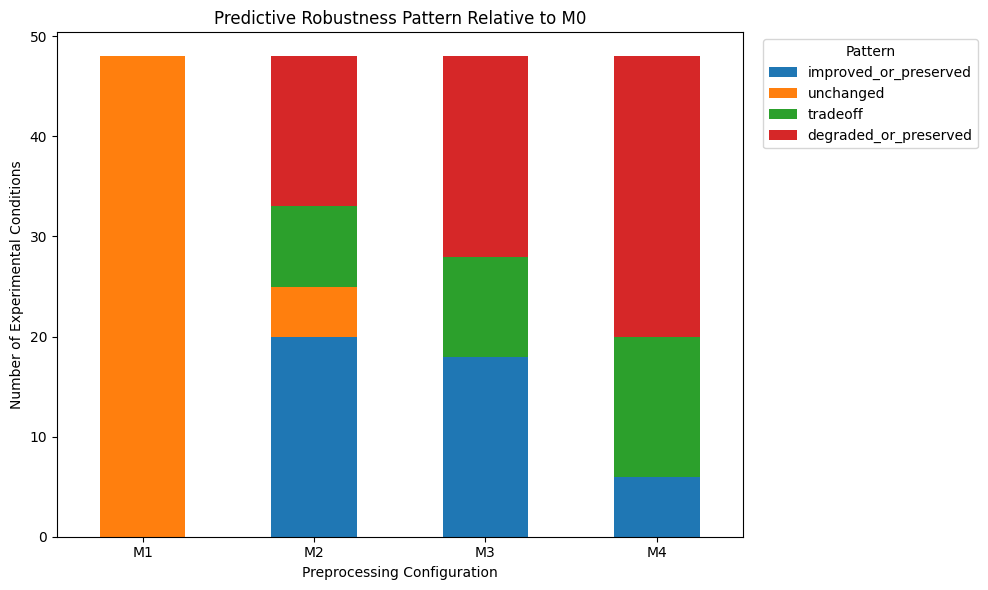

✅ Saved: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_evidence/FIG1_Predictive_Pattern_M0_M4.png


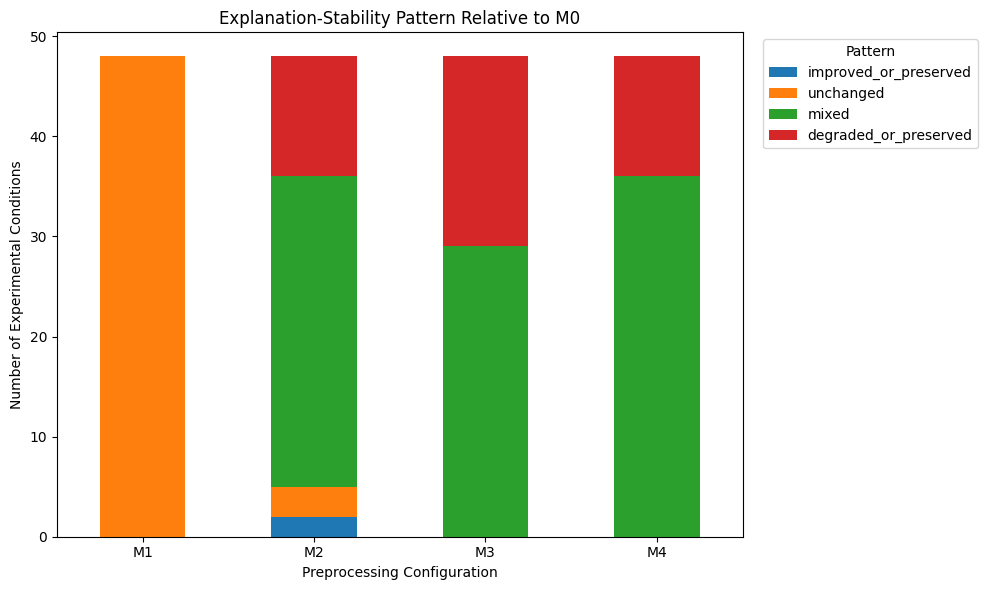

✅ Saved: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_evidence/FIG2_Explanation_Stability_Pattern_M0_M4.png


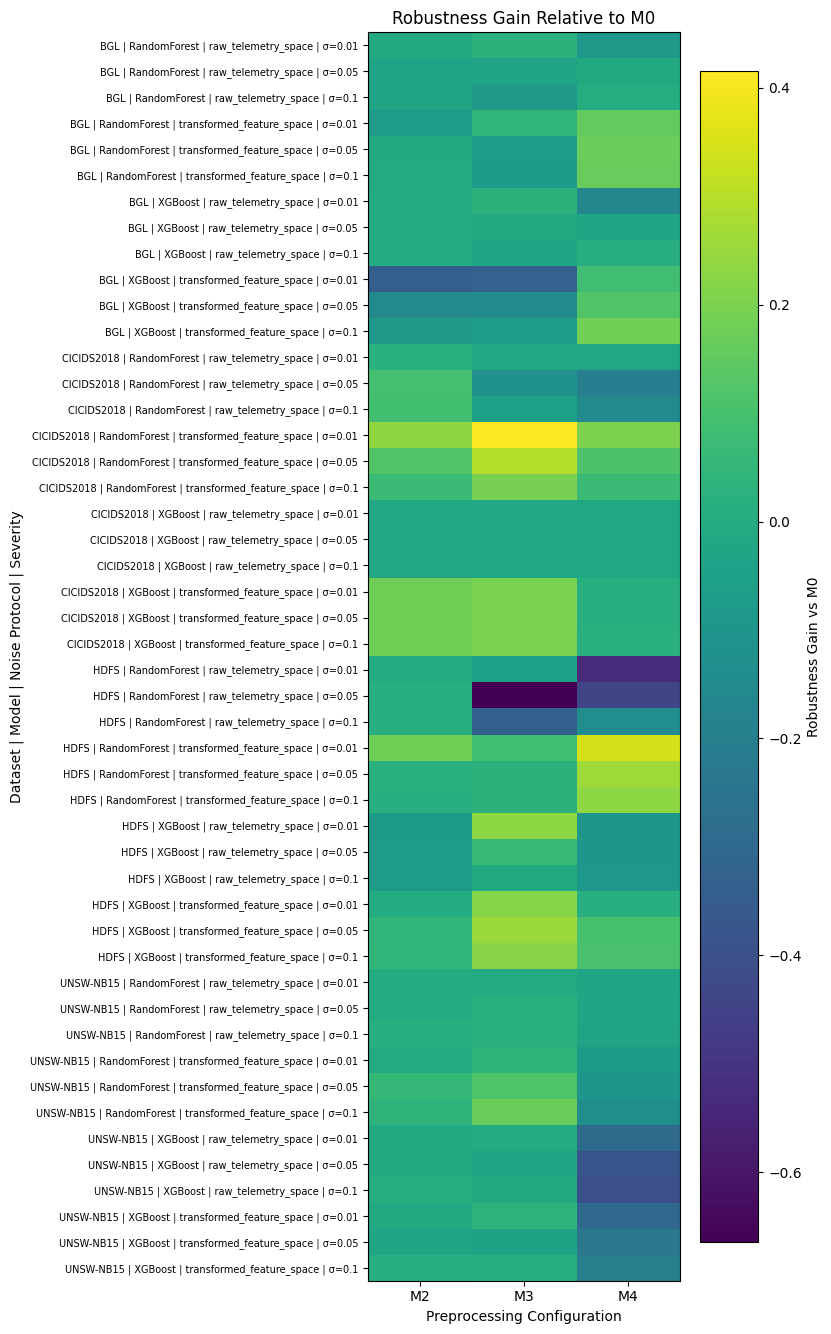

✅ Saved: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_evidence/FIG3_Robustness_Gain_Heatmap_M2_M4.png

VISUALIZATION COMPLETE
1. /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_evidence/FIG1_Predictive_Pattern_M0_M4.png
2. /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_evidence/FIG2_Explanation_Stability_Pattern_M0_M4.png
3. /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_evidence/FIG3_Robustness_Gain_Heatmap_M2_M4.png


In [14]:
# ================================================================
# ER-CyRIS CYCLE-2
# FINAL EVIDENCE VISUALIZATION
#
# Input:
# FINAL_EVIDENCE_MATRIX_CYCLE2.csv
#
# Output:
# 3 publication-ready PNG files
# ================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# PATH
# ------------------------------------------------
FINAL_DIR = (
    Path(BASE)
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'final_evidence'
)

MATRIX_FILE = (
    FINAL_DIR
    / 'FINAL_EVIDENCE_MATRIX_CYCLE2.csv'
)

df = pd.read_csv(MATRIX_FILE)

print("Loaded:", MATRIX_FILE)
print("Rows:", len(df))


# ================================================================
# FIGURE 1
# PREDICTIVE PATTERN COUNTS
# ================================================================
pred = (
    df[df['config'].isin(['M1','M2','M3','M4'])]
    .groupby(
        [
            'config',
            'predictive_pattern_vs_M0'
        ]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        ['M1','M2','M3','M4']
    )
)

preferred_order = [
    'improved_or_preserved',
    'unchanged',
    'tradeoff',
    'degraded_or_preserved'
]

pred = pred[
    [
        c for c in preferred_order
        if c in pred.columns
    ]
]

ax = pred.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

ax.set_title(
    'Predictive Robustness Pattern Relative to M0'
)

ax.set_xlabel(
    'Preprocessing Configuration'
)

ax.set_ylabel(
    'Number of Experimental Conditions'
)

ax.legend(
    title='Pattern',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.xticks(rotation=0)
plt.tight_layout()

fig1 = (
    FINAL_DIR
    / 'FIG1_Predictive_Pattern_M0_M4.png'
)

plt.savefig(
    fig1,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("✅ Saved:", fig1)


# ================================================================
# FIGURE 2
# EXPLANATION-STABILITY PATTERN COUNTS
# ================================================================
expl = (
    df[df['config'].isin(['M1','M2','M3','M4'])]
    .groupby(
        [
            'config',
            'explanation_pattern_vs_M0'
        ]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        ['M1','M2','M3','M4']
    )
)

preferred_order_expl = [
    'improved_or_preserved',
    'unchanged',
    'mixed',
    'degraded_or_preserved'
]

expl = expl[
    [
        c for c in preferred_order_expl
        if c in expl.columns
    ]
]

ax = expl.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

ax.set_title(
    'Explanation-Stability Pattern Relative to M0'
)

ax.set_xlabel(
    'Preprocessing Configuration'
)

ax.set_ylabel(
    'Number of Experimental Conditions'
)

ax.legend(
    title='Pattern',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.xticks(rotation=0)
plt.tight_layout()

fig2 = (
    FINAL_DIR
    / 'FIG2_Explanation_Stability_Pattern_M0_M4.png'
)

plt.savefig(
    fig2,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("✅ Saved:", fig2)


# ================================================================
# FIGURE 3
# HEATMAP — ROBUSTNESS GAIN VS M0
#
# Positive = degradation under noise is smaller than M0
# Negative = degradation is larger than M0
# ================================================================
heat = (
    df[
        df['config'].isin(
            ['M2','M3','M4']
        )
    ]
    .copy()
)

heat['condition'] = (
    heat['dataset'].astype(str)
    + ' | '
    + heat['model'].astype(str)
    + ' | '
    + heat['noise_protocol'].astype(str)
    + ' | σ='
    + heat['sigma'].astype(str)
)

heat_pivot = (
    heat
    .pivot(
        index='condition',
        columns='config',
        values='robustness_delta_mean_gain_vs_M0'
    )
    .reindex(
        columns=['M2','M3','M4']
    )
)

# order conditions for readability
heat_pivot = heat_pivot.sort_index()

fig_height = max(
    10,
    len(heat_pivot) * 0.28
)

fig, ax = plt.subplots(
    figsize=(8, fig_height)
)

im = ax.imshow(
    heat_pivot.values,
    aspect='auto'
)

ax.set_xticks(
    np.arange(
        len(heat_pivot.columns)
    )
)

ax.set_xticklabels(
    heat_pivot.columns
)

ax.set_yticks(
    np.arange(
        len(heat_pivot.index)
    )
)

ax.set_yticklabels(
    heat_pivot.index,
    fontsize=7
)

ax.set_title(
    'Robustness Gain Relative to M0'
)

ax.set_xlabel(
    'Preprocessing Configuration'
)

ax.set_ylabel(
    'Dataset | Model | Noise Protocol | Severity'
)

cbar = plt.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    'Robustness Gain vs M0'
)

plt.tight_layout()

fig3 = (
    FINAL_DIR
    / 'FIG3_Robustness_Gain_Heatmap_M2_M4.png'
)

plt.savefig(
    fig3,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("✅ Saved:", fig3)


print("\n" + "=" * 72)
print("VISUALIZATION COMPLETE")
print("=" * 72)

print("1.", fig1)
print("2.", fig2)
print("3.", fig3)

ER-CyRIS CYCLE-2 — FINAL VISUAL PACKAGE
Evidence rows : 240
Output folder: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals


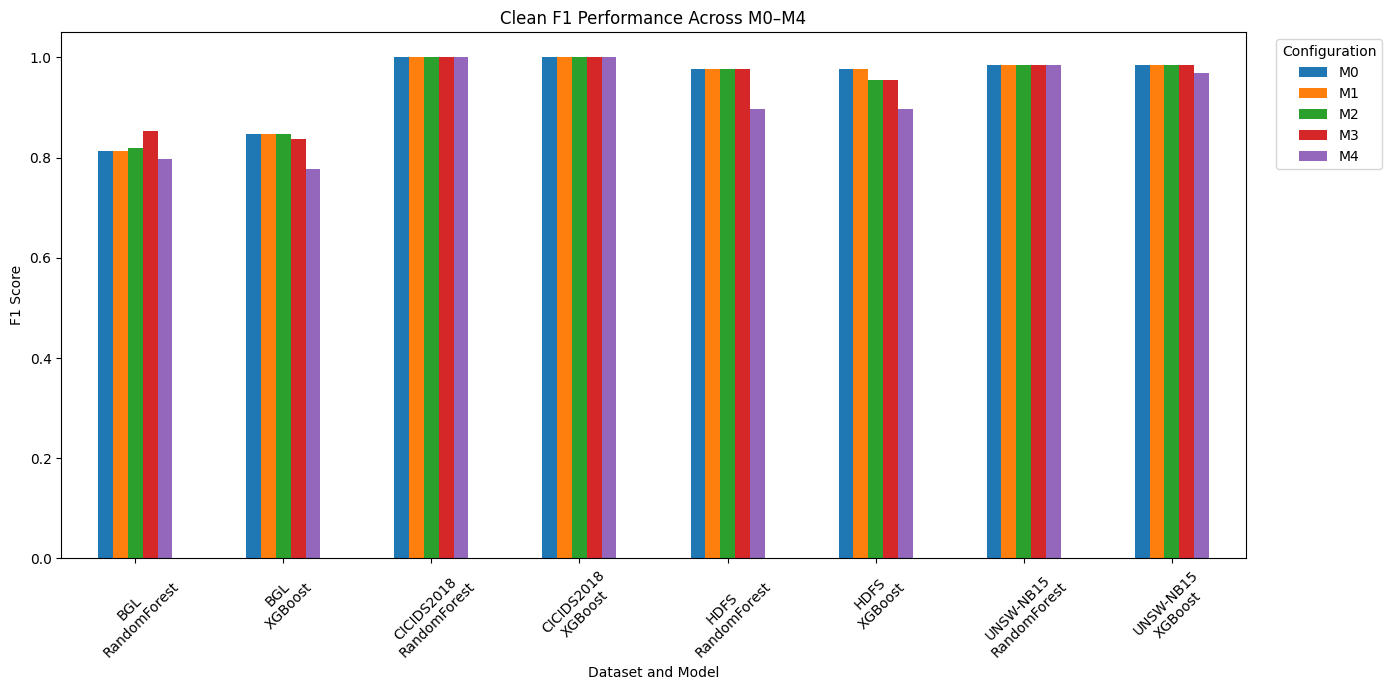

✅ Saved: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals/FIG01_Clean_F1_M0_M4.png


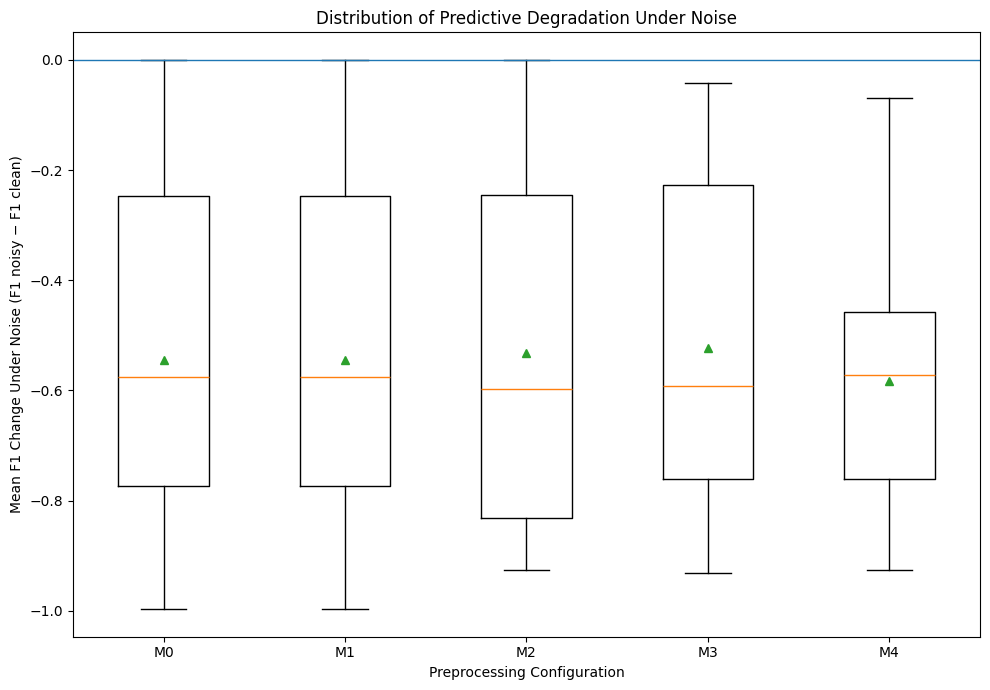

✅ Saved: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals/FIG02_Predictive_Robustness_Distribution_M0_M4.png


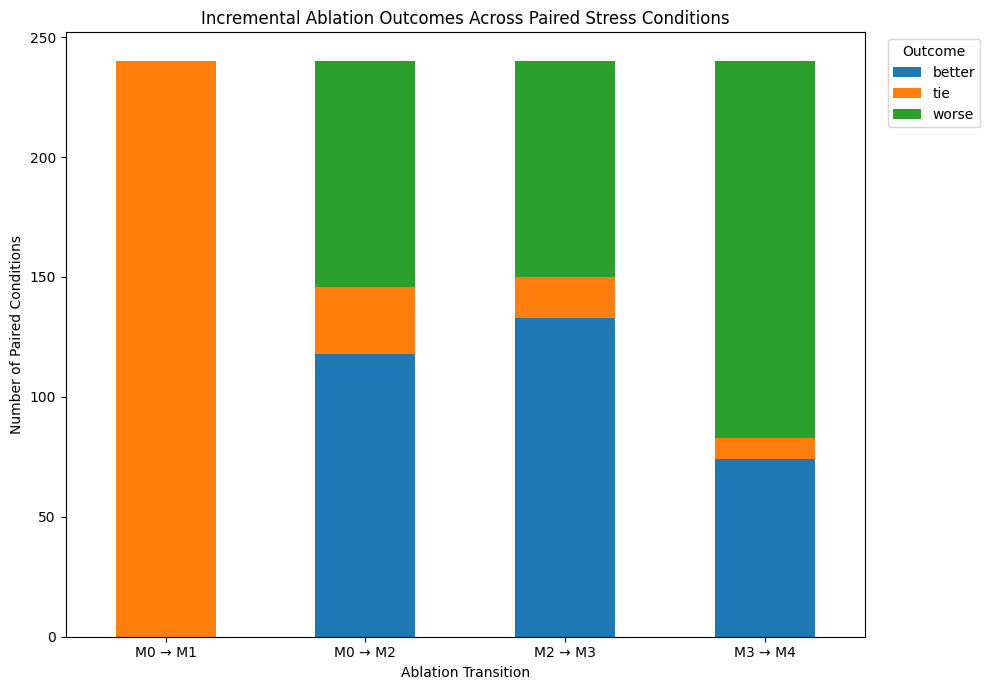

✅ Saved: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals/FIG03_Incremental_Ablation_Outcomes.png


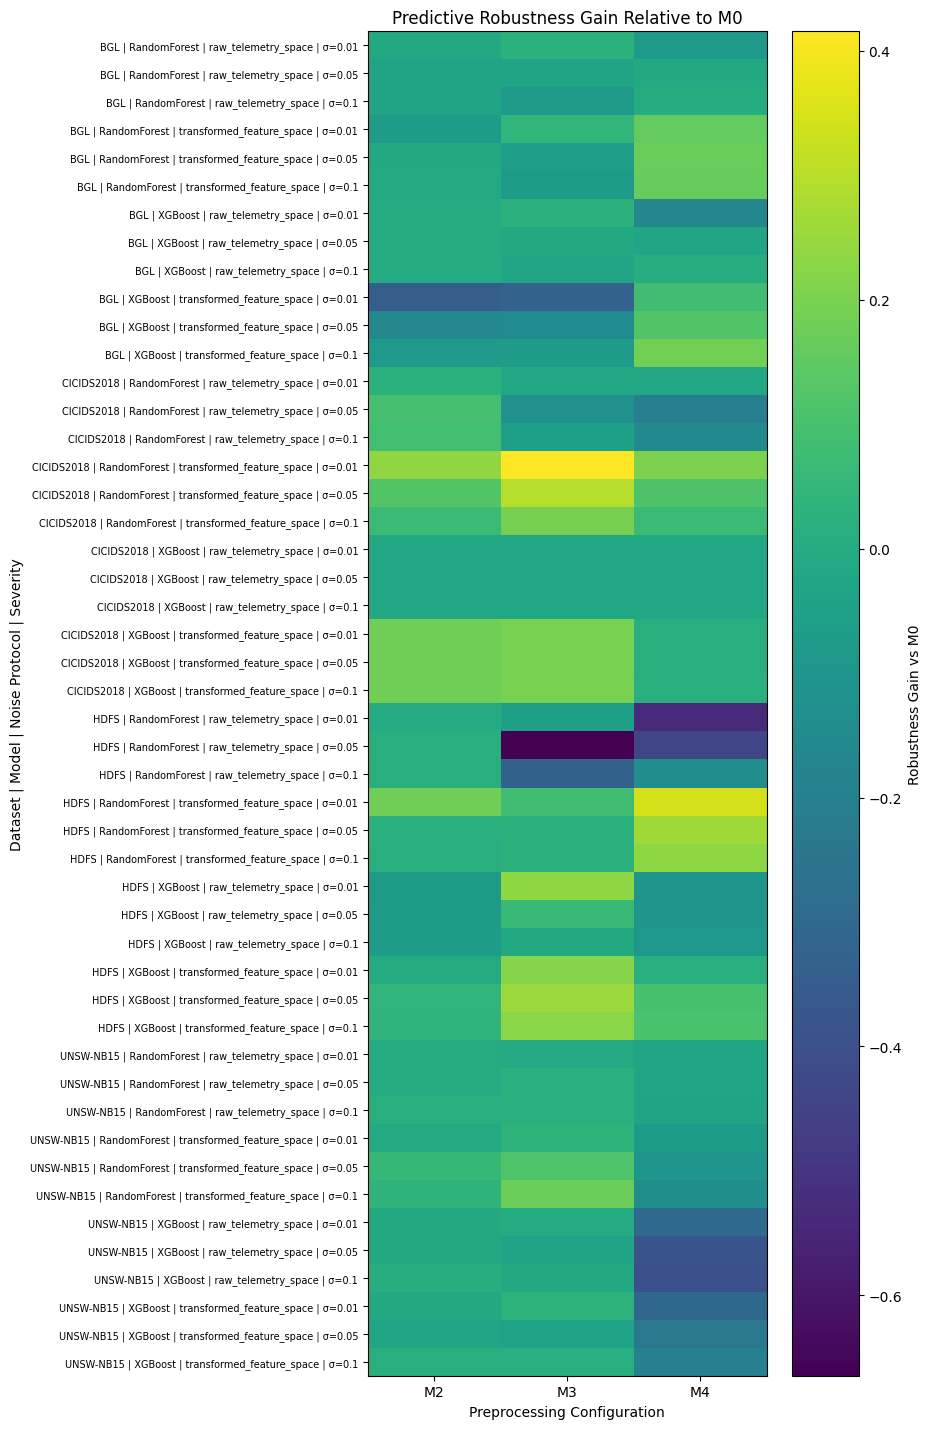

✅ Saved: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals/FIG04_Robustness_Gain_Heatmap_vs_M0.png


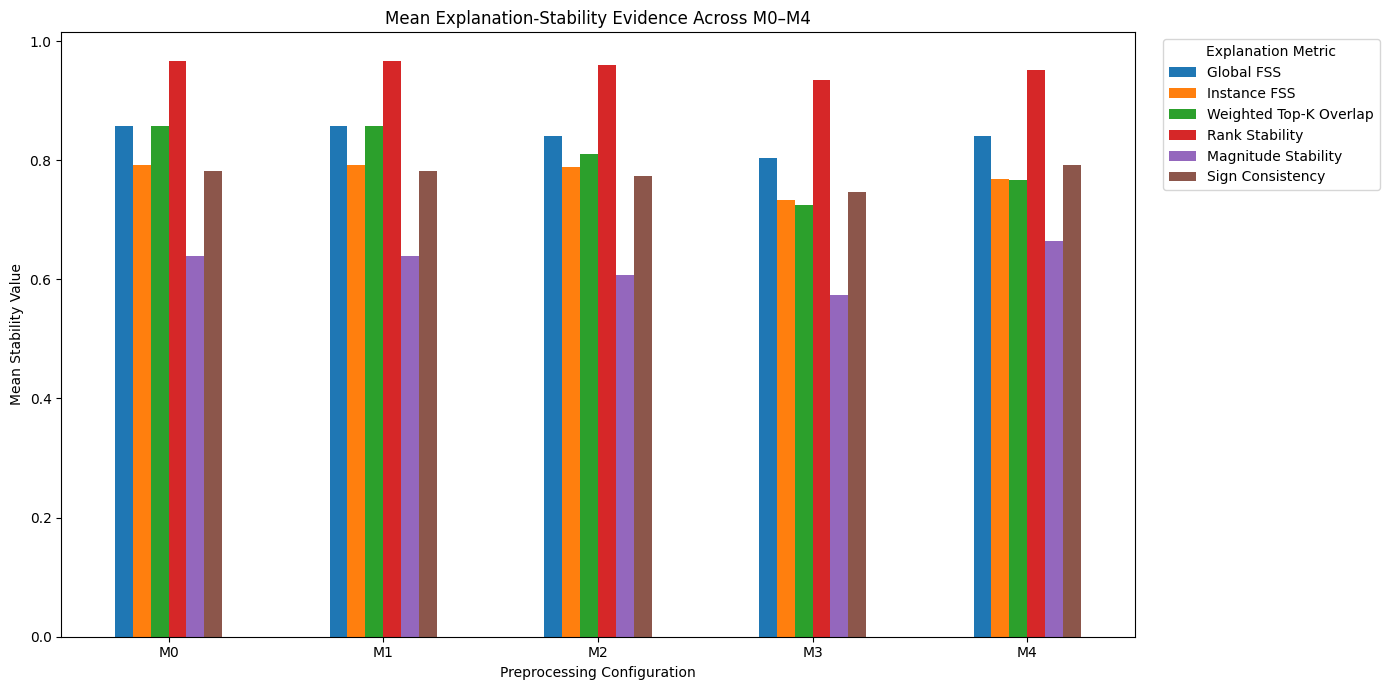

✅ Saved: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals/FIG05_Explanation_Stability_M0_M4.png


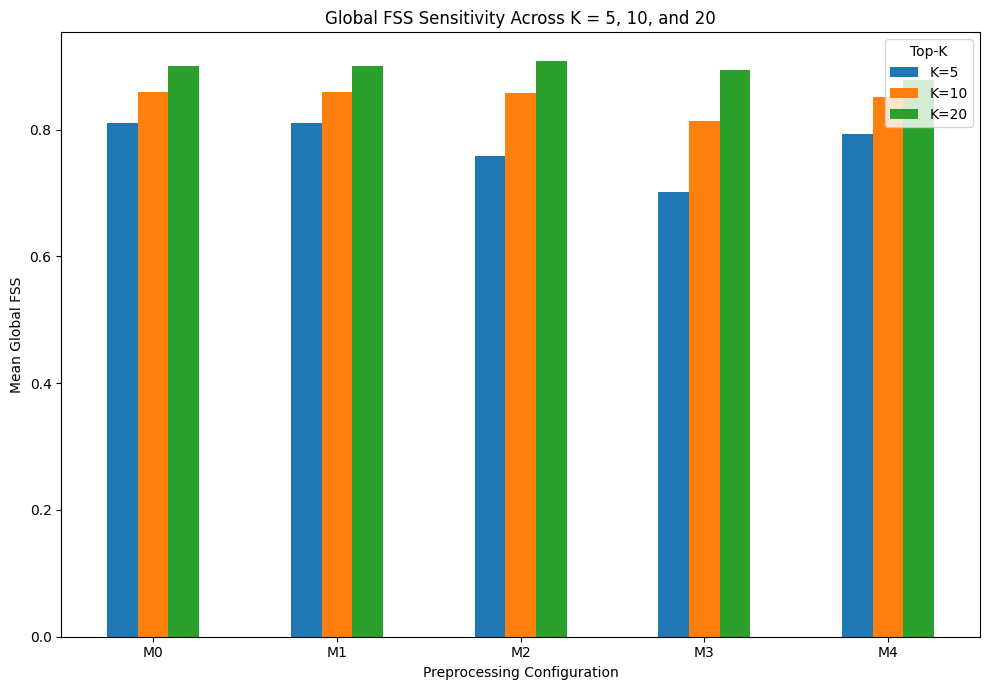

✅ Saved: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals/FIG06_Global_FSS_Sensitivity_K5_K10_K20.png


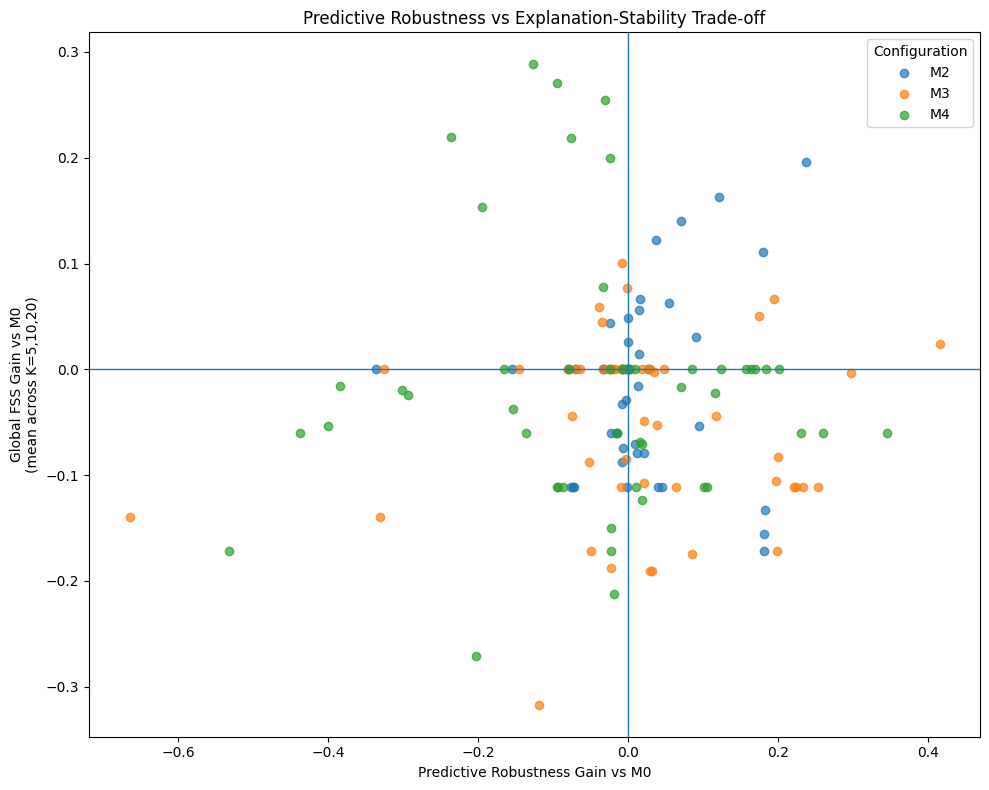

✅ Saved: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals/FIG07_Predictive_Explanation_Tradeoff.png

✅ FINAL VISUAL EVIDENCE PACKAGE COMPLETE
1. /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals/FIG01_Clean_F1_M0_M4.png
2. /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals/FIG02_Predictive_Robustness_Distribution_M0_M4.png
3. /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals/FIG03_Incremental_Ablation_Outcomes.png
4. /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals/FIG04_Robustness_Gain_Heatmap_vs_M0.png
5. /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals/FIG05_Explanation_Stability_M0_M4.png
6. /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals/FIG06_Global_FSS_Sensitivity_K5_K10_K20.png
7. /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_

In [15]:
# ================================================================
# ER-CyRIS CYCLE-2
# FINAL VISUAL EVIDENCE PACKAGE
#
# Generates 7 figures:
# 1. Clean F1 M0-M4
# 2. Predictive robustness distribution M0-M4
# 3. Incremental ablation outcomes
# 4. Robustness heatmap vs M0
# 5. Explanation stability M0-M4
# 6. FSS sensitivity K=5,10,20
# 7. Predictive–Explanation trade-off
#
# NO TRAINING
# NO SHAP
# NO BOOTSTRAP
# CPU ONLY
# ================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ================================================================
# 0. PATHS
# ================================================================
if 'BASE' not in globals():
    BASE = '/content/drive/MyDrive/ercyris_siklus2'

BASE = Path(BASE)

EVIDENCE_DIR = (
    BASE
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'final_evidence'
)

AUDIT_DIR = (
    BASE
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'final_audit'
)

VIS_DIR = (
    BASE
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'final_visuals'
)

VIS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MATRIX_FILE = (
    EVIDENCE_DIR
    / 'FINAL_EVIDENCE_MATRIX_CYCLE2.csv'
)

if not MATRIX_FILE.exists():
    raise FileNotFoundError(
        f"Evidence Matrix tidak ditemukan:\n{MATRIX_FILE}"
    )


# ================================================================
# 1. LOAD FINAL EVIDENCE MATRIX
# ================================================================
df = pd.read_csv(
    MATRIX_FILE
)

if len(df) != 240:
    raise RuntimeError(
        f"Expected 240 evidence rows, found {len(df)}"
    )

CONFIG_ORDER = [
    'M0', 'M1', 'M2', 'M3', 'M4'
]

df['config'] = pd.Categorical(
    df['config'],
    categories=CONFIG_ORDER,
    ordered=True
)

print("=" * 78)
print("ER-CyRIS CYCLE-2 — FINAL VISUAL PACKAGE")
print("=" * 78)
print("Evidence rows :", len(df))
print("Output folder:", VIS_DIR)


# ================================================================
# HELPER
# ================================================================
def save_show(fig, filename):

    path = VIS_DIR / filename

    fig.savefig(
        path,
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()
    plt.close(fig)

    print("✅ Saved:", path)

    return path


generated = []


# ================================================================
# FIGURE 1
# CLEAN F1 — M0 TO M4
# ================================================================
clean = (
    df[
        [
            'config',
            'dataset',
            'model',
            'clean_F1'
        ]
    ]
    .drop_duplicates()
    .copy()
)

clean['condition'] = (
    clean['dataset'].astype(str)
    + '\n'
    + clean['model'].astype(str)
)

clean_pivot = (
    clean
    .pivot(
        index='condition',
        columns='config',
        values='clean_F1'
    )
    .reindex(
        columns=CONFIG_ORDER
    )
)

fig, ax = plt.subplots(
    figsize=(14, 7)
)

clean_pivot.plot(
    kind='bar',
    ax=ax
)

ax.set_title(
    'Clean F1 Performance Across M0–M4'
)

ax.set_xlabel(
    'Dataset and Model'
)

ax.set_ylabel(
    'F1 Score'
)

ax.set_ylim(
    0,
    min(
        1.05,
        max(
            1.0,
            clean_pivot.max().max()
            + 0.05
        )
    )
)

ax.legend(
    title='Configuration',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

ax.tick_params(
    axis='x',
    rotation=45
)

fig.tight_layout()

generated.append(
    save_show(
        fig,
        'FIG01_Clean_F1_M0_M4.png'
    )
)


# ================================================================
# FIGURE 2
# DISTRIBUTION OF F1 CHANGE UNDER NOISE
#
# robustness_delta_mean:
# F1_noisy - F1_clean
#
# Closer to zero = less degradation
# More negative = stronger degradation
# ================================================================
box_data = []

for cfg in CONFIG_ORDER:

    values = (
        df[
            df['config'] == cfg
        ]['robustness_delta_mean']
        .dropna()
        .values
    )

    box_data.append(
        values
    )

fig, ax = plt.subplots(
    figsize=(10, 7)
)

ax.boxplot(
    box_data,
    tick_labels=CONFIG_ORDER,
    showmeans=True
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_title(
    'Distribution of Predictive Degradation Under Noise'
)

ax.set_xlabel(
    'Preprocessing Configuration'
)

ax.set_ylabel(
    'Mean F1 Change Under Noise (F1 noisy − F1 clean)'
)

fig.tight_layout()

generated.append(
    save_show(
        fig,
        'FIG02_Predictive_Robustness_Distribution_M0_M4.png'
    )
)


# ================================================================
# FIGURE 3
# INCREMENTAL ABLATION OUTCOMES
#
# Uses paired seed-level audit:
# 240 conditions/comparison
# ================================================================
PAIR_FILES = {
    'M0 → M1':
        'FINAL_predictive_M1_vs_M0.csv',

    'M0 → M2':
        'FINAL_predictive_M2_vs_M0.csv',

    'M2 → M3':
        'FINAL_predictive_M3_vs_M2.csv',

    'M3 → M4':
        'FINAL_predictive_M4_vs_M3.csv'
}

ablation_rows = []

for label, filename in PAIR_FILES.items():

    path = AUDIT_DIR / filename

    if not path.exists():
        raise FileNotFoundError(
            f"Audit file tidak ditemukan:\n{path}"
        )

    tmp = pd.read_csv(
        path
    )

    counts = (
        tmp['result']
        .value_counts()
    )

    ablation_rows.append({
        'comparison': label,
        'better': int(
            counts.get(
                'better',
                0
            )
        ),
        'tie': int(
            counts.get(
                'tie',
                0
            )
        ),
        'worse': int(
            counts.get(
                'worse',
                0
            )
        )
    })

ablation = (
    pd.DataFrame(
        ablation_rows
    )
    .set_index(
        'comparison'
    )
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

ablation[
    [
        'better',
        'tie',
        'worse'
    ]
].plot(
    kind='bar',
    stacked=True,
    ax=ax
)

ax.set_title(
    'Incremental Ablation Outcomes Across Paired Stress Conditions'
)

ax.set_xlabel(
    'Ablation Transition'
)

ax.set_ylabel(
    'Number of Paired Conditions'
)

ax.legend(
    title='Outcome',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

ax.tick_params(
    axis='x',
    rotation=0
)

fig.tight_layout()

generated.append(
    save_show(
        fig,
        'FIG03_Incremental_Ablation_Outcomes.png'
    )
)


# ================================================================
# FIGURE 4
# ROBUSTNESS GAIN HEATMAP VS M0
#
# Positive = less degradation than M0
# Negative = more degradation than M0
# ================================================================
heat = (
    df[
        df['config'].isin(
            ['M2', 'M3', 'M4']
        )
    ]
    .copy()
)

heat['condition'] = (
    heat['dataset'].astype(str)
    + ' | '
    + heat['model'].astype(str)
    + ' | '
    + heat['noise_protocol'].astype(str)
    + ' | σ='
    + heat['sigma'].astype(str)
)

heat_pivot = (
    heat
    .pivot(
        index='condition',
        columns='config',
        values='robustness_delta_mean_gain_vs_M0'
    )
    .reindex(
        columns=[
            'M2',
            'M3',
            'M4'
        ]
    )
    .sort_index()
)

fig_height = max(
    12,
    len(heat_pivot) * 0.30
)

fig, ax = plt.subplots(
    figsize=(
        9,
        fig_height
    )
)

im = ax.imshow(
    heat_pivot.values,
    aspect='auto'
)

ax.set_xticks(
    np.arange(
        len(
            heat_pivot.columns
        )
    )
)

ax.set_xticklabels(
    heat_pivot.columns
)

ax.set_yticks(
    np.arange(
        len(
            heat_pivot.index
        )
    )
)

ax.set_yticklabels(
    heat_pivot.index,
    fontsize=7
)

ax.set_title(
    'Predictive Robustness Gain Relative to M0'
)

ax.set_xlabel(
    'Preprocessing Configuration'
)

ax.set_ylabel(
    'Dataset | Model | Noise Protocol | Severity'
)

cbar = fig.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    'Robustness Gain vs M0'
)

fig.tight_layout()

generated.append(
    save_show(
        fig,
        'FIG04_Robustness_Gain_Heatmap_vs_M0.png'
    )
)


# ================================================================
# FIGURE 5
# EXPLANATION STABILITY — M0 TO M4
#
# For K-dependent metrics:
# arithmetic mean across K=5,10,20.
#
# IMPORTANT:
# This is NOT a weighted overall score.
# Each metric remains separate.
# ================================================================
expl = df.copy()

expl[
    'FSS_Global_avgK'
] = expl[
    [
        'FSS_global_mean_K5',
        'FSS_global_mean_K10',
        'FSS_global_mean_K20'
    ]
].mean(axis=1)

expl[
    'FSS_Instance_avgK'
] = expl[
    [
        'FSS_instance_mean_K5',
        'FSS_instance_mean_K10',
        'FSS_instance_mean_K20'
    ]
].mean(axis=1)

expl[
    'Weighted_Overlap_avgK'
] = expl[
    [
        'weighted_overlap_mean_K5',
        'weighted_overlap_mean_K10',
        'weighted_overlap_mean_K20'
    ]
].mean(axis=1)

EXPL_DISPLAY = {
    'FSS_Global_avgK':
        'Global FSS',

    'FSS_Instance_avgK':
        'Instance FSS',

    'Weighted_Overlap_avgK':
        'Weighted Top-K Overlap',

    'rank_spearman_mean':
        'Rank Stability',

    'magnitude_stability_mean':
        'Magnitude Stability',

    'sign_consistency_mean':
        'Sign Consistency'
}

expl_mean = (
    expl
    .groupby(
        'config',
        observed=True
    )[
        list(
            EXPL_DISPLAY.keys()
        )
    ]
    .mean()
    .reindex(
        CONFIG_ORDER
    )
    .rename(
        columns=EXPL_DISPLAY
    )
)

fig, ax = plt.subplots(
    figsize=(14, 7)
)

expl_mean.plot(
    kind='bar',
    ax=ax
)

ax.set_title(
    'Mean Explanation-Stability Evidence Across M0–M4'
)

ax.set_xlabel(
    'Preprocessing Configuration'
)

ax.set_ylabel(
    'Mean Stability Value'
)

ax.legend(
    title='Explanation Metric',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

ax.tick_params(
    axis='x',
    rotation=0
)

fig.tight_layout()

generated.append(
    save_show(
        fig,
        'FIG05_Explanation_Stability_M0_M4.png'
    )
)


# ================================================================
# FIGURE 6
# FSS GLOBAL SENSITIVITY TO K
# K = 5, 10, 20
# ================================================================
fss_k = (
    df
    .groupby(
        'config',
        observed=True
    )[
        [
            'FSS_global_mean_K5',
            'FSS_global_mean_K10',
            'FSS_global_mean_K20'
        ]
    ]
    .mean()
    .reindex(
        CONFIG_ORDER
    )
)

fss_k = fss_k.rename(
    columns={
        'FSS_global_mean_K5':
            'K=5',

        'FSS_global_mean_K10':
            'K=10',

        'FSS_global_mean_K20':
            'K=20'
    }
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

fss_k.plot(
    kind='bar',
    ax=ax
)

ax.set_title(
    'Global FSS Sensitivity Across K = 5, 10, and 20'
)

ax.set_xlabel(
    'Preprocessing Configuration'
)

ax.set_ylabel(
    'Mean Global FSS'
)

ax.legend(
    title='Top-K'
)

ax.tick_params(
    axis='x',
    rotation=0
)

fig.tight_layout()

generated.append(
    save_show(
        fig,
        'FIG06_Global_FSS_Sensitivity_K5_K10_K20.png'
    )
)


# ================================================================
# FIGURE 7
# PREDICTIVE–EXPLANATION TRADE-OFF
#
# X = robustness gain vs M0
# Y = mean Global-FSS gain across K=5,10,20
#
# IMPORTANT:
# averaging here is only across K of SAME metric family,
# not a weighted multi-metric score.
# ================================================================
trade = (
    df[
        df['config'].isin(
            [
                'M2',
                'M3',
                'M4'
            ]
        )
    ]
    .copy()
)

trade[
    'FSS_global_gain_avgK_vs_M0'
] = trade[
    [
        'FSS_global_mean_K5_gain_vs_M0',
        'FSS_global_mean_K10_gain_vs_M0',
        'FSS_global_mean_K20_gain_vs_M0'
    ]
].mean(axis=1)


fig, ax = plt.subplots(
    figsize=(10, 8)
)

for cfg in [
    'M2',
    'M3',
    'M4'
]:

    tmp = trade[
        trade['config'] == cfg
    ]

    ax.scatter(
        tmp[
            'robustness_delta_mean_gain_vs_M0'
        ],
        tmp[
            'FSS_global_gain_avgK_vs_M0'
        ],
        alpha=0.7,
        label=cfg
    )


ax.axhline(
    0,
    linewidth=1
)

ax.axvline(
    0,
    linewidth=1
)

ax.set_title(
    'Predictive Robustness vs Explanation-Stability Trade-off'
)

ax.set_xlabel(
    'Predictive Robustness Gain vs M0'
)

ax.set_ylabel(
    'Global FSS Gain vs M0\n(mean across K=5,10,20)'
)

ax.legend(
    title='Configuration'
)

fig.tight_layout()

generated.append(
    save_show(
        fig,
        'FIG07_Predictive_Explanation_Tradeoff.png'
    )
)


# ================================================================
# 8. SAVE SUPPORTING TABLES FOR THE FIGURES
# ================================================================
clean_pivot.to_csv(
    VIS_DIR
    / 'FIG01_data_Clean_F1.csv'
)

ablation.to_csv(
    VIS_DIR
    / 'FIG03_data_Ablation_Outcomes.csv'
)

heat_pivot.to_csv(
    VIS_DIR
    / 'FIG04_data_Robustness_Heatmap.csv'
)

expl_mean.to_csv(
    VIS_DIR
    / 'FIG05_data_Explanation_Stability.csv'
)

fss_k.to_csv(
    VIS_DIR
    / 'FIG06_data_FSS_by_K.csv'
)

trade[
    [
        'config',
        'dataset',
        'model',
        'noise_protocol',
        'sigma',
        'robustness_delta_mean_gain_vs_M0',
        'FSS_global_gain_avgK_vs_M0'
    ]
].to_csv(
    VIS_DIR
    / 'FIG07_data_Tradeoff.csv',
    index=False
)


# ================================================================
# 9. MANIFEST
# ================================================================
manifest = pd.DataFrame({
    'figure': [
        'Figure 1',
        'Figure 2',
        'Figure 3',
        'Figure 4',
        'Figure 5',
        'Figure 6',
        'Figure 7'
    ],

    'purpose': [
        'Clean predictive performance across M0-M4',
        'Distribution of predictive degradation under noise',
        'Incremental ablation evidence',
        'Condition-dependent robustness relative to baseline',
        'Multidimensional explanation-stability evidence',
        'Sensitivity of Global FSS to Top-K',
        'Predictive versus explanation-stability trade-off'
    ],

    'file': [
        Path(x).name
        for x in generated
    ]
})

manifest.to_csv(
    VIS_DIR
    / 'VISUAL_PACKAGE_MANIFEST.csv',
    index=False
)


# ================================================================
# FINAL REPORT
# ================================================================
print("\n" + "=" * 78)
print("✅ FINAL VISUAL EVIDENCE PACKAGE COMPLETE")
print("=" * 78)

for i, path in enumerate(
    generated,
    start=1
):
    print(
        f"{i}. {path}"
    )

print(
    "\nManifest:",
    VIS_DIR
    / 'VISUAL_PACKAGE_MANIFEST.csv'
)

print(
    "\nTotal figures:",
    len(generated)
)

print(
    "\nNO TRAINING / NO SHAP / "
    "NO ADDITIONAL EXPERIMENT WAS PERFORMED."
)

REVISED MAIN VISUAL PACKAGE — CYCLE 2
Evidence rows : 240
Output folder: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals_revised


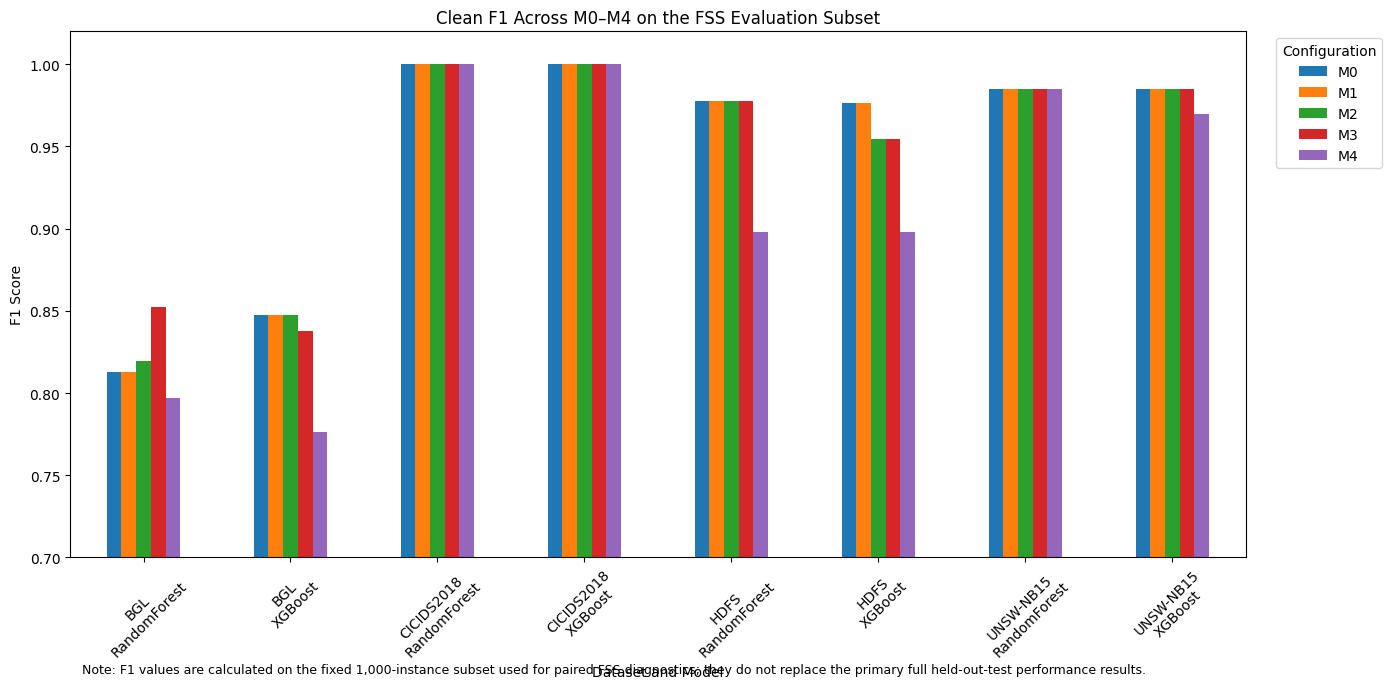

✅ Saved: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals_revised/REVISED_FIG01_Clean_F1_FSS_Evaluation_Subset.png


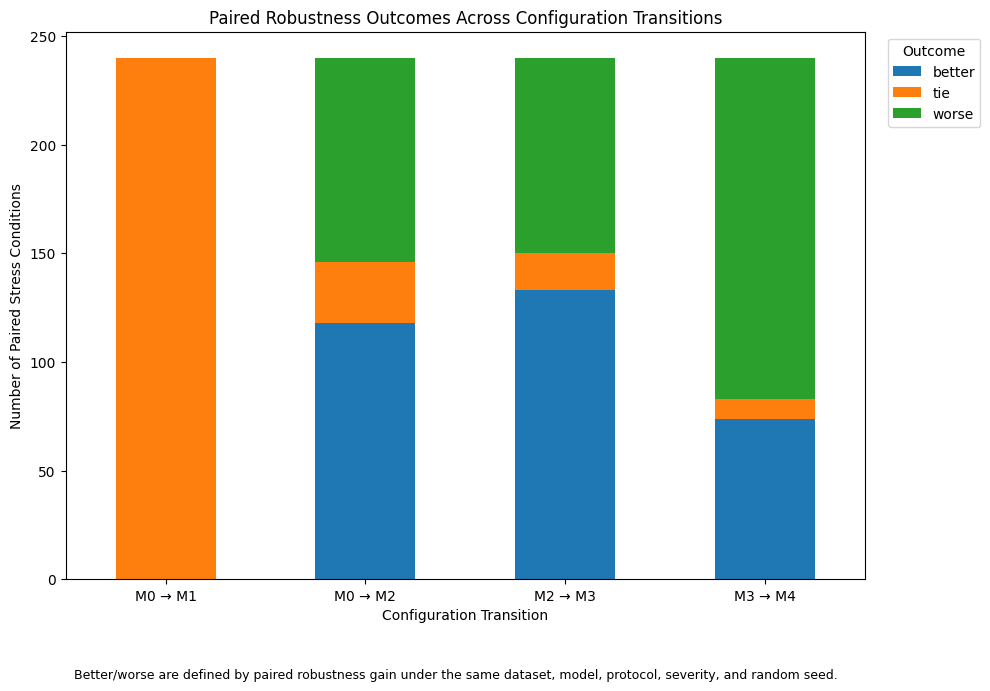

✅ Saved: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals_revised/REVISED_FIG02_Paired_Robustness_Transitions.png


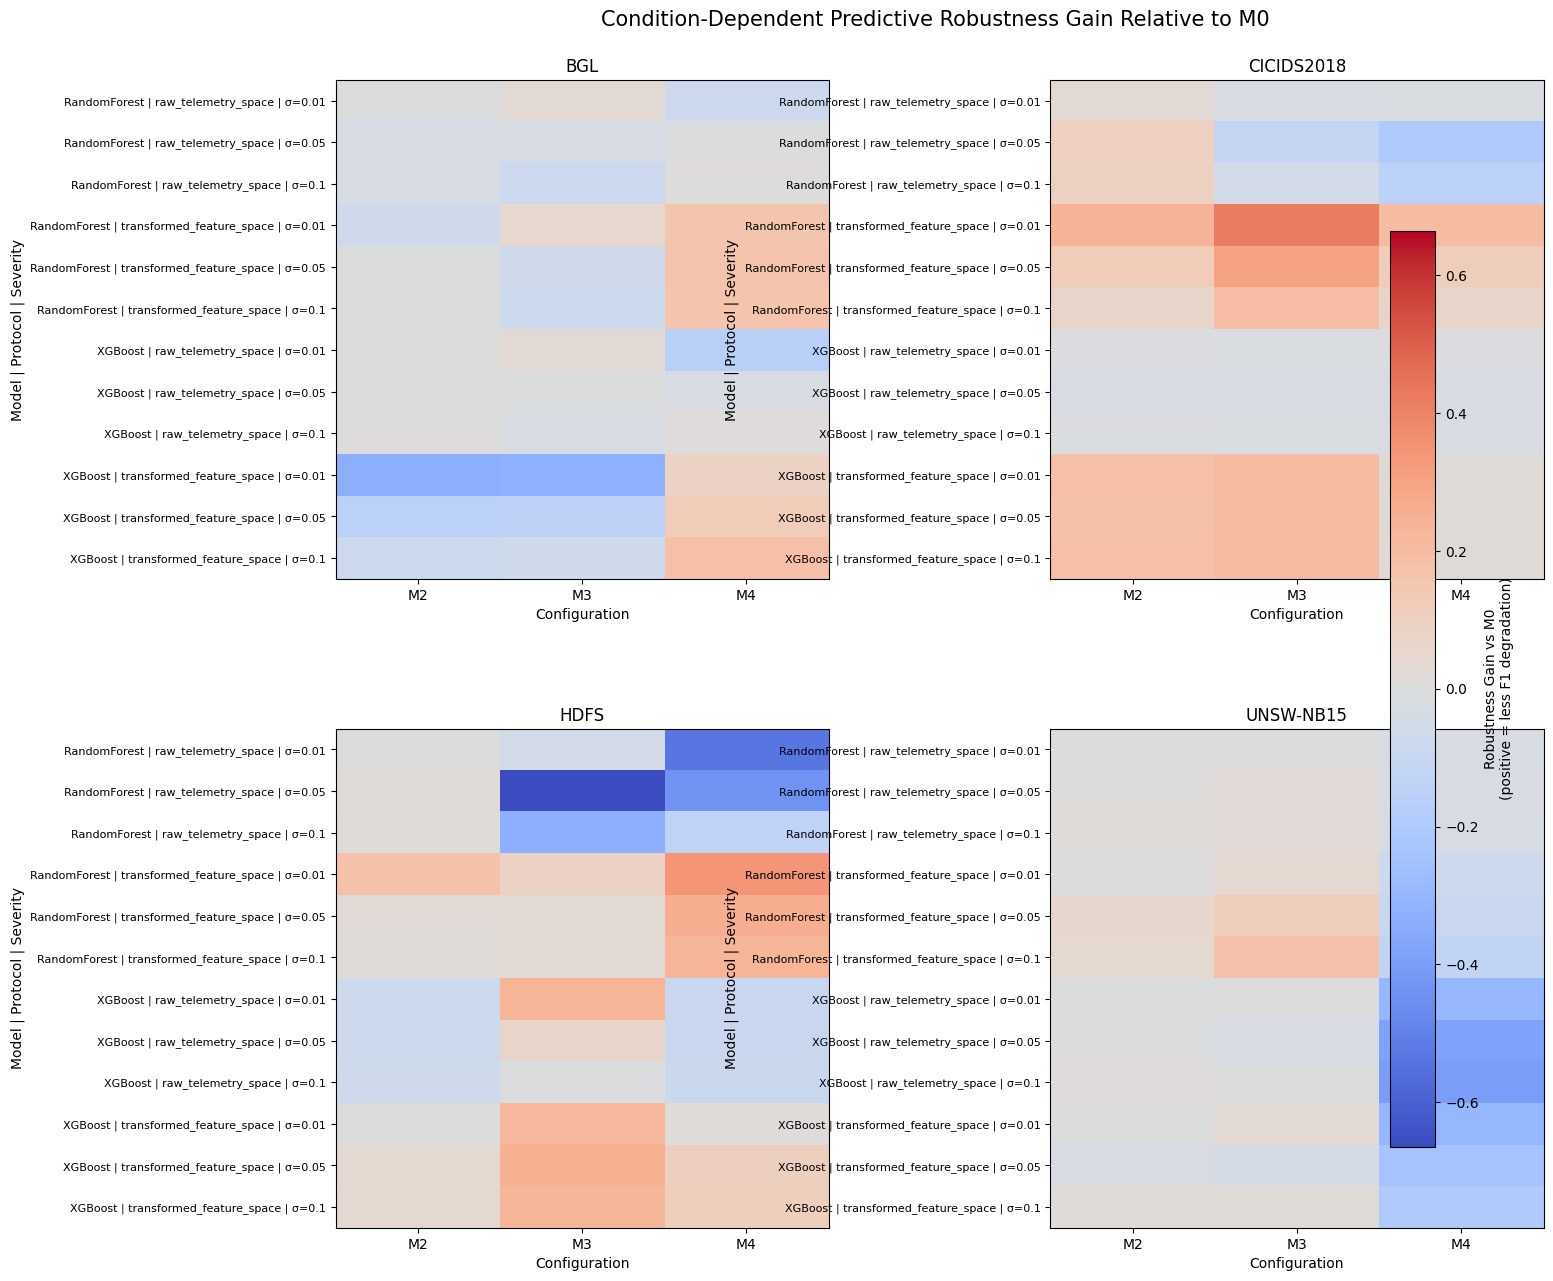

✅ Saved: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals_revised/REVISED_FIG03_Condition_Dependent_Robustness_4_Datasets.png


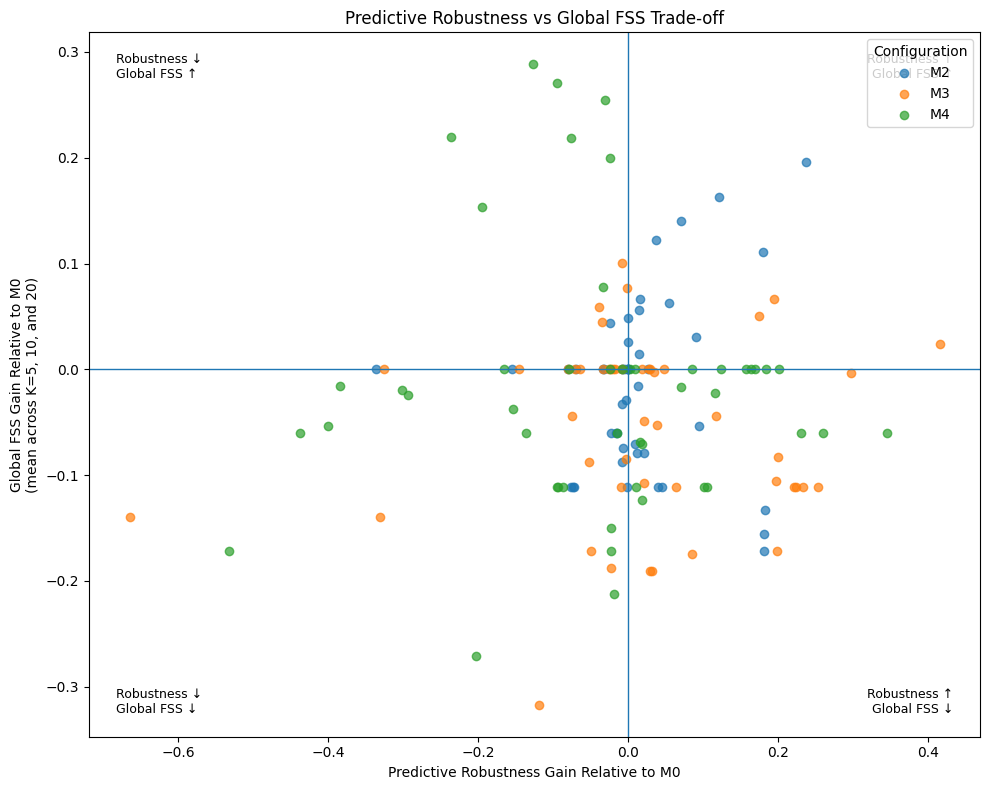

✅ Saved: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals_revised/REVISED_FIG04_Predictive_Robustness_vs_Global_FSS.png

✅ REVISED MAIN VISUAL PACKAGE COMPLETE
1. /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals_revised/REVISED_FIG01_Clean_F1_FSS_Evaluation_Subset.png
2. /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals_revised/REVISED_FIG02_Paired_Robustness_Transitions.png
3. /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals_revised/REVISED_FIG03_Condition_Dependent_Robustness_4_Datasets.png
4. /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals_revised/REVISED_FIG04_Predictive_Robustness_vs_Global_FSS.png

Manifest: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals_revised/REVISED_MAIN_VISUAL_MANIFEST.csv

IMPORTANT:
- Original 7 figures remain preserved.
- These 4 revised figures are the MAIN 

In [16]:
# ================================================================
# ER-CyRIS CYCLE-2
# REVISED MAIN VISUALS FOR BAB VI
#
# Revised figures:
# R1. Clean F1 on FSS evaluation subset
# R2. Paired robustness outcomes across configuration transitions
# R3. Condition-dependent robustness heatmap — 4 dataset panels
# R4. Predictive robustness vs Global FSS trade-off
#
# NO TRAINING
# NO SHAP
# NO BOOTSTRAP
# NO NEW EXPERIMENT
# ================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


# ================================================================
# 0. PATHS
# ================================================================
if 'BASE' not in globals():
    BASE = '/content/drive/MyDrive/ercyris_siklus2'

BASE = Path(BASE)

EVIDENCE_DIR = (
    BASE
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'final_evidence'
)

AUDIT_DIR = (
    BASE
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'final_audit'
)

OUT_DIR = (
    BASE
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'final_visuals_revised'
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MATRIX_FILE = (
    EVIDENCE_DIR
    / 'FINAL_EVIDENCE_MATRIX_CYCLE2.csv'
)

if not MATRIX_FILE.exists():
    raise FileNotFoundError(
        f"Evidence matrix tidak ditemukan:\n{MATRIX_FILE}"
    )


# ================================================================
# 1. LOAD FINAL EVIDENCE
# ================================================================
df = pd.read_csv(MATRIX_FILE)

if len(df) != 240:
    raise RuntimeError(
        f"Expected 240 rows, found {len(df)}"
    )

CONFIG_ORDER = [
    'M0', 'M1', 'M2', 'M3', 'M4'
]

df['config'] = pd.Categorical(
    df['config'],
    categories=CONFIG_ORDER,
    ordered=True
)

print("=" * 78)
print("REVISED MAIN VISUAL PACKAGE — CYCLE 2")
print("=" * 78)
print("Evidence rows :", len(df))
print("Output folder:", OUT_DIR)


def save_fig(fig, filename):
    path = OUT_DIR / filename

    fig.savefig(
        path,
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()
    plt.close(fig)

    print("✅ Saved:", path)

    return path


generated = []


# ================================================================
# R1 — CLEAN F1
#
# IMPORTANT:
# This is clean F1 on the SAME 1,000-instance
# evaluation subset used for FSS analysis.
#
# It is NOT the primary full held-out-test performance table.
# ================================================================
clean = (
    df[
        [
            'config',
            'dataset',
            'model',
            'clean_F1'
        ]
    ]
    .drop_duplicates()
    .copy()
)

clean['condition'] = (
    clean['dataset'].astype(str)
    + '\n'
    + clean['model'].astype(str)
)

clean_pivot = (
    clean
    .pivot(
        index='condition',
        columns='config',
        values='clean_F1'
    )
    .reindex(
        columns=CONFIG_ORDER
    )
)

fig, ax = plt.subplots(
    figsize=(14, 7)
)

clean_pivot.plot(
    kind='bar',
    ax=ax
)

ax.set_title(
    'Clean F1 Across M0–M4 on the FSS Evaluation Subset'
)

ax.set_xlabel(
    'Dataset and Model'
)

ax.set_ylabel(
    'F1 Score'
)

ax.set_ylim(
    0.70,
    1.02
)

ax.legend(
    title='Configuration',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

ax.tick_params(
    axis='x',
    rotation=45
)

ax.text(
    0.01,
    -0.22,
    'Note: F1 values are calculated on the fixed 1,000-instance '
    'subset used for paired FSS diagnostics; they do not replace '
    'the primary full held-out-test performance results.',
    transform=ax.transAxes,
    fontsize=9
)

fig.tight_layout()

generated.append(
    save_fig(
        fig,
        'REVISED_FIG01_Clean_F1_FSS_Evaluation_Subset.png'
    )
)


# ================================================================
# R2 — PAIRED ROBUSTNESS OUTCOMES
#
# M1 vs M0 = implementation-control verification
# M2 vs M0 = substantive representation treatment
# M3 vs M2 = incremental contextual anomaly evidence
# M4 vs M3 = incremental SMOTE/rescaling treatment
# ================================================================
PAIR_FILES = {
    'M0 → M1':
        'FINAL_predictive_M1_vs_M0.csv',

    'M0 → M2':
        'FINAL_predictive_M2_vs_M0.csv',

    'M2 → M3':
        'FINAL_predictive_M3_vs_M2.csv',

    'M3 → M4':
        'FINAL_predictive_M4_vs_M3.csv'
}

rows = []

for label, filename in PAIR_FILES.items():

    path = AUDIT_DIR / filename

    if not path.exists():
        raise FileNotFoundError(
            f"Audit file tidak ditemukan:\n{path}"
        )

    tmp = pd.read_csv(path)

    counts = (
        tmp['result']
        .value_counts()
    )

    rows.append({
        'transition': label,
        'better': int(
            counts.get('better', 0)
        ),
        'tie': int(
            counts.get('tie', 0)
        ),
        'worse': int(
            counts.get('worse', 0)
        )
    })


ablation = (
    pd.DataFrame(rows)
    .set_index('transition')
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

ablation[
    ['better', 'tie', 'worse']
].plot(
    kind='bar',
    stacked=True,
    ax=ax
)

ax.set_title(
    'Paired Robustness Outcomes Across Configuration Transitions'
)

ax.set_xlabel(
    'Configuration Transition'
)

ax.set_ylabel(
    'Number of Paired Stress Conditions'
)

ax.legend(
    title='Outcome',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

ax.tick_params(
    axis='x',
    rotation=0
)

ax.text(
    0.01,
    -0.18,
    'Better/worse are defined by paired robustness gain under '
    'the same dataset, model, protocol, severity, and random seed.',
    transform=ax.transAxes,
    fontsize=9
)

fig.tight_layout()

generated.append(
    save_fig(
        fig,
        'REVISED_FIG02_Paired_Robustness_Transitions.png'
    )
)


# ================================================================
# R3 — CONDITION-DEPENDENT ROBUSTNESS HEATMAP
#
# Four dataset panels.
#
# Positive gain:
# treatment degrades LESS than M0.
#
# Negative gain:
# treatment degrades MORE than M0.
# ================================================================
heat = (
    df[
        df['config'].isin(
            ['M2', 'M3', 'M4']
        )
    ]
    .copy()
)

heat['condition'] = (
    heat['model'].astype(str)
    + ' | '
    + heat['noise_protocol'].astype(str)
    + ' | σ='
    + heat['sigma'].astype(str)
)

datasets = [
    'BGL',
    'CICIDS2018',
    'HDFS',
    'UNSW-NB15'
]

# common scale across four panels
all_values = (
    heat[
        'robustness_delta_mean_gain_vs_M0'
    ]
    .dropna()
    .values
)

max_abs = np.max(
    np.abs(all_values)
)

norm = TwoSlopeNorm(
    vmin=-max_abs,
    vcenter=0,
    vmax=max_abs
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 14)
)

axes = axes.flatten()

last_im = None

for ax, dataset in zip(
    axes,
    datasets
):

    tmp = (
        heat[
            heat['dataset'] == dataset
        ]
        .pivot(
            index='condition',
            columns='config',
            values='robustness_delta_mean_gain_vs_M0'
        )
        .reindex(
            columns=[
                'M2',
                'M3',
                'M4'
            ]
        )
    )

    # explicit ordering:
    # model -> protocol -> sigma
    tmp = tmp.sort_index()

    last_im = ax.imshow(
        tmp.values,
        aspect='auto',
        norm=norm,
        cmap='coolwarm'
    )

    ax.set_xticks(
        np.arange(
            len(tmp.columns)
        )
    )

    ax.set_xticklabels(
        tmp.columns
    )

    ax.set_yticks(
        np.arange(
            len(tmp.index)
        )
    )

    ax.set_yticklabels(
        tmp.index,
        fontsize=8
    )

    ax.set_title(
        dataset
    )

    ax.set_xlabel(
        'Configuration'
    )

    ax.set_ylabel(
        'Model | Protocol | Severity'
    )


fig.suptitle(
    'Condition-Dependent Predictive Robustness Gain Relative to M0',
    fontsize=15
)

cbar = fig.colorbar(
    last_im,
    ax=axes.tolist(),
    shrink=0.85
)

cbar.set_label(
    'Robustness Gain vs M0\n'
    '(positive = less F1 degradation)'
)

fig.subplots_adjust(
    top=0.93,
    right=0.88,
    hspace=0.30,
    wspace=0.45
)

generated.append(
    save_fig(
        fig,
        'REVISED_FIG03_Condition_Dependent_Robustness_4_Datasets.png'
    )
)


# ================================================================
# R4 — PREDICTIVE ROBUSTNESS VS GLOBAL FSS
#
# Do NOT call Y axis "overall explanation stability".
#
# Y only represents Global FSS, averaged across
# sensitivity settings K=5,10,20.
# ================================================================
trade = (
    df[
        df['config'].isin(
            ['M2', 'M3', 'M4']
        )
    ]
    .copy()
)

trade[
    'global_FSS_gain_avgK_vs_M0'
] = trade[
    [
        'FSS_global_mean_K5_gain_vs_M0',
        'FSS_global_mean_K10_gain_vs_M0',
        'FSS_global_mean_K20_gain_vs_M0'
    ]
].mean(axis=1)


fig, ax = plt.subplots(
    figsize=(10, 8)
)

for cfg in [
    'M2',
    'M3',
    'M4'
]:

    tmp = trade[
        trade['config'] == cfg
    ]

    ax.scatter(
        tmp[
            'robustness_delta_mean_gain_vs_M0'
        ],
        tmp[
            'global_FSS_gain_avgK_vs_M0'
        ],
        alpha=0.70,
        label=cfg
    )


ax.axhline(
    0,
    linewidth=1
)

ax.axvline(
    0,
    linewidth=1
)

ax.set_title(
    'Predictive Robustness vs Global FSS Trade-off'
)

ax.set_xlabel(
    'Predictive Robustness Gain Relative to M0'
)

ax.set_ylabel(
    'Global FSS Gain Relative to M0\n'
    '(mean across K=5, 10, and 20)'
)

ax.legend(
    title='Configuration'
)

# Quadrant interpretation
ax.text(
    0.97,
    0.97,
    'Robustness ↑\nGlobal FSS ↑',
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=9
)

ax.text(
    0.03,
    0.97,
    'Robustness ↓\nGlobal FSS ↑',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9
)

ax.text(
    0.97,
    0.03,
    'Robustness ↑\nGlobal FSS ↓',
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=9
)

ax.text(
    0.03,
    0.03,
    'Robustness ↓\nGlobal FSS ↓',
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=9
)

fig.tight_layout()

generated.append(
    save_fig(
        fig,
        'REVISED_FIG04_Predictive_Robustness_vs_Global_FSS.png'
    )
)


# ================================================================
# 5. SAVE SUPPORTING DATA
# ================================================================
clean_pivot.to_csv(
    OUT_DIR
    / 'REVISED_FIG01_data.csv'
)

ablation.to_csv(
    OUT_DIR
    / 'REVISED_FIG02_data.csv'
)

trade[
    [
        'config',
        'dataset',
        'model',
        'noise_protocol',
        'sigma',
        'robustness_delta_mean_gain_vs_M0',
        'global_FSS_gain_avgK_vs_M0'
    ]
].to_csv(
    OUT_DIR
    / 'REVISED_FIG04_data.csv',
    index=False
)


# ================================================================
# 6. MANIFEST
# ================================================================
manifest = pd.DataFrame({

    'figure': [
        'Main Figure 1',
        'Main Figure 2',
        'Main Figure 3',
        'Main Figure 4'
    ],

    'scientific_role': [
        'Clean-condition diagnostic performance on the fixed FSS subset',
        'Paired incremental robustness evidence across configurations',
        'Condition-dependent robustness across dataset/model/protocol/severity',
        'Empirical trade-off between predictive robustness and Global FSS'
    ],

    'recommended_placement': [
        'Bab VI',
        'Bab VI - main ablation evidence',
        'Bab VI - main robustness evidence',
        'Bab VI - robustness/explainability bridge'
    ],

    'filename': [
        Path(x).name
        for x in generated
    ]
})

manifest.to_csv(
    OUT_DIR
    / 'REVISED_MAIN_VISUAL_MANIFEST.csv',
    index=False
)


# ================================================================
# FINAL
# ================================================================
print("\n" + "=" * 78)
print("✅ REVISED MAIN VISUAL PACKAGE COMPLETE")
print("=" * 78)

for i, path in enumerate(
    generated,
    start=1
):
    print(
        f"{i}. {path}"
    )

print(
    "\nManifest:",
    OUT_DIR
    / 'REVISED_MAIN_VISUAL_MANIFEST.csv'
)

print(
    "\nIMPORTANT:"
)

print(
    "- Original 7 figures remain preserved."
)

print(
    "- These 4 revised figures are the MAIN Bab VI candidates."
)

print(
    "- No new experiment was performed."
)

print(
    "- Do not proceed to EQC yet."
)

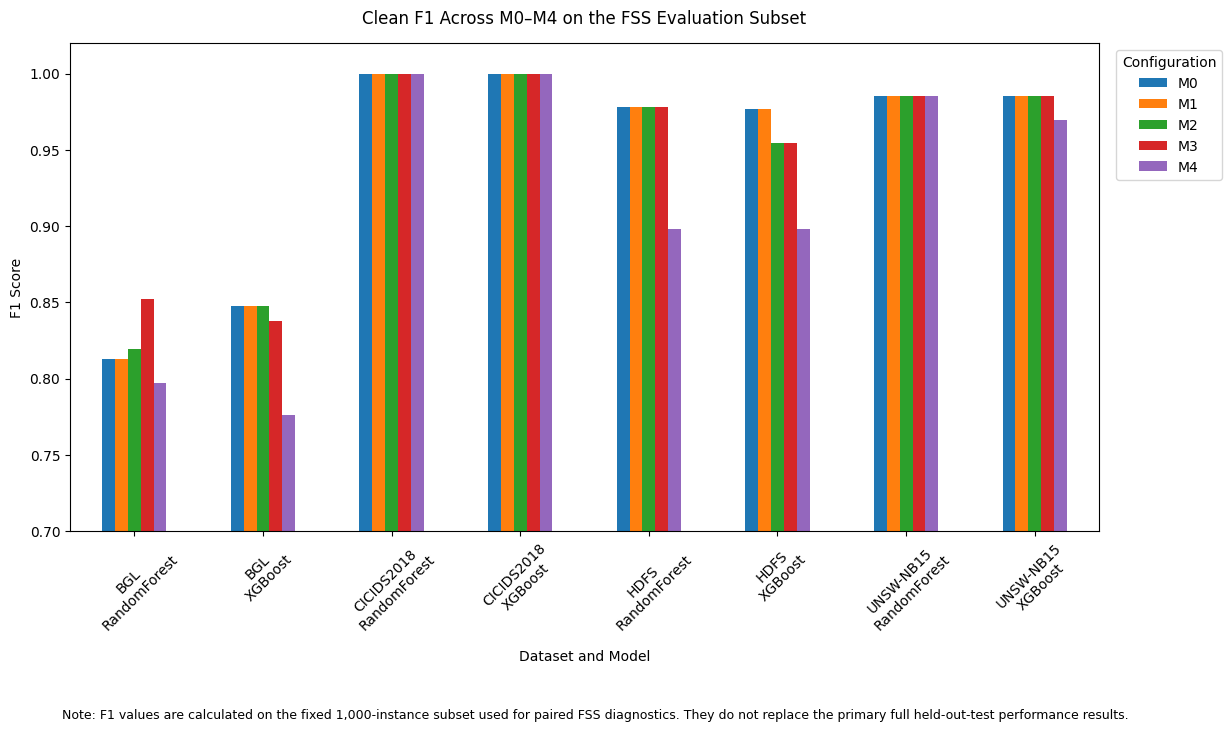

✅ Saved: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals_revised/FINAL_FIG01_Clean_F1_FSS_Evaluation_Subset.png


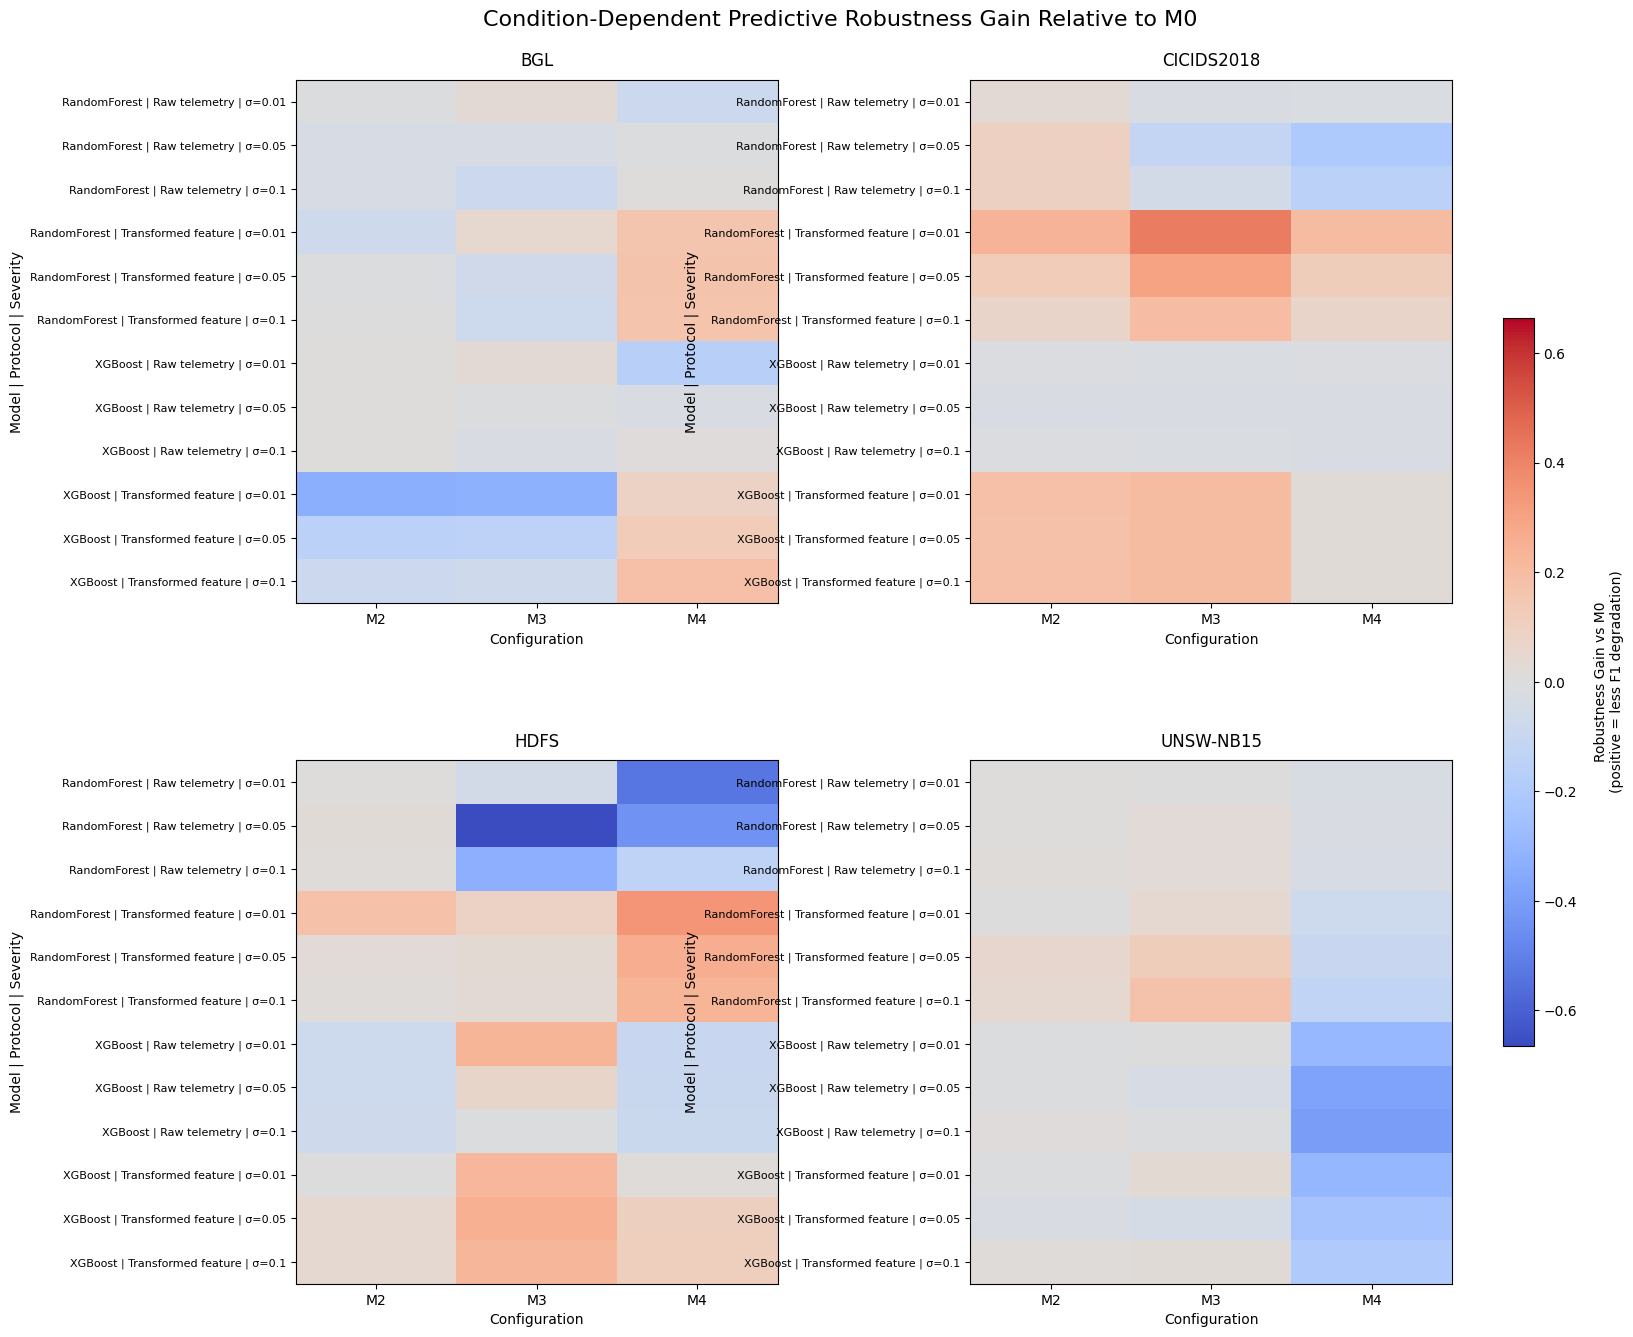

✅ Saved: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals_revised/FINAL_FIG03_Condition_Dependent_Robustness_4_Datasets.png


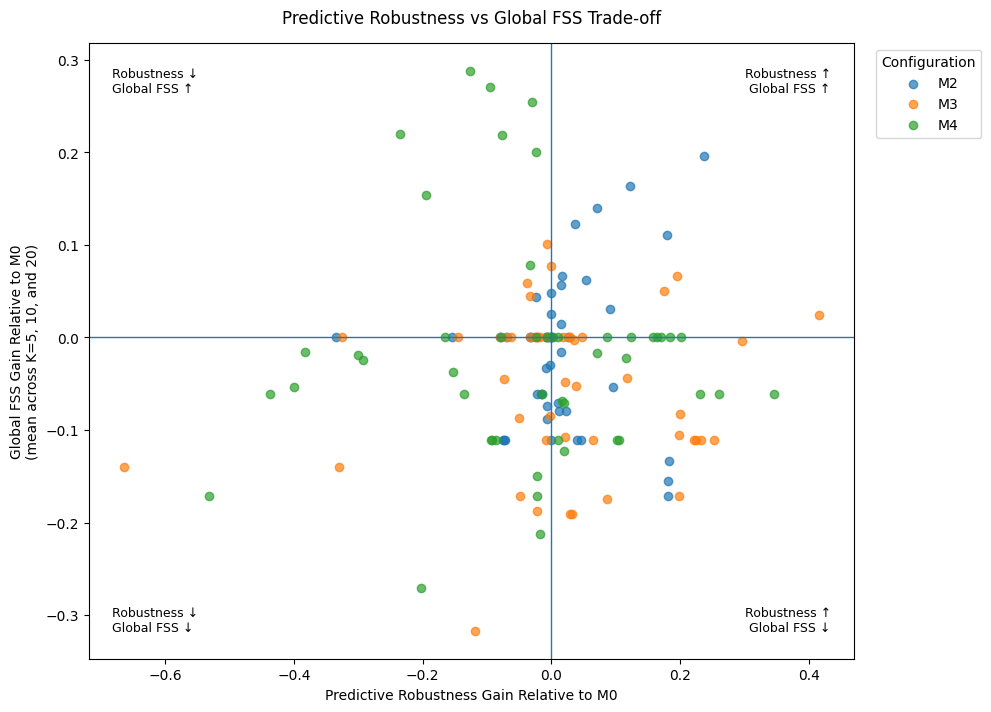

✅ Saved: /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_visuals_revised/FINAL_FIG04_Predictive_Robustness_vs_Global_FSS.png

✅ FINAL VISUAL CORRECTION COMPLETE
FIG02 remains unchanged and is already FINAL.
No experiment or metric was recomputed.


In [17]:
# ================================================================
# ER-CyRIS CYCLE-2
# FINAL COSMETIC FIX — FIG 1, FIG 3, FIG 4 ONLY
#
# NO NEW ANALYSIS
# NO TRAINING
# NO SHAP
# NO NEW EXPERIMENT
# ================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


# ------------------------------------------------
# PATHS
# ------------------------------------------------
if 'BASE' not in globals():
    BASE = '/content/drive/MyDrive/ercyris_siklus2'

BASE = Path(BASE)

EVIDENCE_DIR = (
    BASE
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'final_evidence'
)

OUT_DIR = (
    BASE
    / 'results'
    / 'fss_cycle2_repair_v5'
    / 'final_visuals_revised'
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MATRIX_FILE = (
    EVIDENCE_DIR
    / 'FINAL_EVIDENCE_MATRIX_CYCLE2.csv'
)

df = pd.read_csv(MATRIX_FILE)

CONFIG_ORDER = [
    'M0', 'M1', 'M2', 'M3', 'M4'
]

df['config'] = pd.Categorical(
    df['config'],
    categories=CONFIG_ORDER,
    ordered=True
)


def save_final(fig, filename):

    path = OUT_DIR / filename

    fig.savefig(
        path,
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()
    plt.close(fig)

    print("✅ Saved:", path)


# ================================================================
# FINAL FIGURE 1
# CLEAN F1 — FIX BOTTOM NOTE
# ================================================================
clean = (
    df[
        [
            'config',
            'dataset',
            'model',
            'clean_F1'
        ]
    ]
    .drop_duplicates()
    .copy()
)

clean['condition'] = (
    clean['dataset'].astype(str)
    + '\n'
    + clean['model'].astype(str)
)

clean_pivot = (
    clean
    .pivot(
        index='condition',
        columns='config',
        values='clean_F1'
    )
    .reindex(columns=CONFIG_ORDER)
)

fig, ax = plt.subplots(
    figsize=(14, 8)
)

clean_pivot.plot(
    kind='bar',
    ax=ax
)

ax.set_title(
    'Clean F1 Across M0–M4 on the FSS Evaluation Subset',
    pad=14
)

ax.set_xlabel(
    'Dataset and Model',
    labelpad=12
)

ax.set_ylabel(
    'F1 Score'
)

ax.set_ylim(
    0.70,
    1.02
)

ax.legend(
    title='Configuration',
    bbox_to_anchor=(1.01, 1),
    loc='upper left'
)

ax.tick_params(
    axis='x',
    rotation=45
)

# reserve lower margin for note
fig.subplots_adjust(
    bottom=0.27,
    right=0.86
)

fig.text(
    0.5,
    0.035,
    'Note: F1 values are calculated on the fixed 1,000-instance '
    'subset used for paired FSS diagnostics. They do not replace '
    'the primary full held-out-test performance results.',
    ha='center',
    fontsize=9
)

save_final(
    fig,
    'FINAL_FIG01_Clean_F1_FSS_Evaluation_Subset.png'
)


# ================================================================
# FINAL FIGURE 3
# FOUR-DATASET ROBUSTNESS HEATMAP
# FIX COLORBAR + SPACING
# ================================================================
heat = (
    df[
        df['config'].isin(
            ['M2', 'M3', 'M4']
        )
    ]
    .copy()
)

heat['condition'] = (
    heat['model'].astype(str)
    + ' | '
    + heat['noise_protocol']
        .astype(str)
        .replace({
            'raw_telemetry_space':
                'Raw telemetry',

            'transformed_feature_space':
                'Transformed feature'
        })
    + ' | σ='
    + heat['sigma'].astype(str)
)

datasets = [
    'BGL',
    'CICIDS2018',
    'HDFS',
    'UNSW-NB15'
]

all_values = (
    heat[
        'robustness_delta_mean_gain_vs_M0'
    ]
    .dropna()
    .values
)

max_abs = np.max(
    np.abs(all_values)
)

norm = TwoSlopeNorm(
    vmin=-max_abs,
    vcenter=0,
    vmax=max_abs
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(17, 14)
)

axes = axes.flatten()

last_im = None

for ax, dataset in zip(
    axes,
    datasets
):

    tmp = (
        heat[
            heat['dataset'] == dataset
        ]
        .pivot(
            index='condition',
            columns='config',
            values='robustness_delta_mean_gain_vs_M0'
        )
        .reindex(
            columns=[
                'M2',
                'M3',
                'M4'
            ]
        )
        .sort_index()
    )

    last_im = ax.imshow(
        tmp.values,
        aspect='auto',
        norm=norm,
        cmap='coolwarm'
    )

    ax.set_xticks(
        np.arange(
            len(tmp.columns)
        )
    )

    ax.set_xticklabels(
        tmp.columns
    )

    ax.set_yticks(
        np.arange(
            len(tmp.index)
        )
    )

    ax.set_yticklabels(
        tmp.index,
        fontsize=8
    )

    ax.set_title(
        dataset,
        fontsize=12,
        pad=10
    )

    ax.set_xlabel(
        'Configuration'
    )

    ax.set_ylabel(
        'Model | Protocol | Severity'
    )


fig.suptitle(
    'Condition-Dependent Predictive Robustness Gain Relative to M0',
    fontsize=16,
    y=0.98
)

# leave dedicated area for colorbar
fig.subplots_adjust(
    left=0.18,
    right=0.86,
    top=0.93,
    bottom=0.07,
    hspace=0.30,
    wspace=0.40
)

cbar_ax = fig.add_axes(
    [
        0.89,
        0.24,
        0.018,
        0.52
    ]
)

cbar = fig.colorbar(
    last_im,
    cax=cbar_ax
)

cbar.set_label(
    'Robustness Gain vs M0\n'
    '(positive = less F1 degradation)',
    labelpad=12
)

save_final(
    fig,
    'FINAL_FIG03_Condition_Dependent_Robustness_4_Datasets.png'
)


# ================================================================
# FINAL FIGURE 4
# PREDICTIVE ROBUSTNESS VS GLOBAL FSS
# FIX LEGEND / QUADRANT LABEL OVERLAP
# ================================================================
trade = (
    df[
        df['config'].isin(
            ['M2', 'M3', 'M4']
        )
    ]
    .copy()
)

trade[
    'global_FSS_gain_avgK_vs_M0'
] = trade[
    [
        'FSS_global_mean_K5_gain_vs_M0',
        'FSS_global_mean_K10_gain_vs_M0',
        'FSS_global_mean_K20_gain_vs_M0'
    ]
].mean(axis=1)

fig, ax = plt.subplots(
    figsize=(11, 8)
)

for cfg in [
    'M2',
    'M3',
    'M4'
]:

    tmp = trade[
        trade['config'] == cfg
    ]

    ax.scatter(
        tmp[
            'robustness_delta_mean_gain_vs_M0'
        ],
        tmp[
            'global_FSS_gain_avgK_vs_M0'
        ],
        alpha=0.70,
        label=cfg
    )


ax.axhline(
    0,
    linewidth=1
)

ax.axvline(
    0,
    linewidth=1
)

ax.set_title(
    'Predictive Robustness vs Global FSS Trade-off',
    pad=14
)

ax.set_xlabel(
    'Predictive Robustness Gain Relative to M0'
)

ax.set_ylabel(
    'Global FSS Gain Relative to M0\n'
    '(mean across K=5, 10, and 20)'
)

# legend moved outside plot
ax.legend(
    title='Configuration',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# quadrant labels
ax.text(
    0.97,
    0.96,
    'Robustness ↑\nGlobal FSS ↑',
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=9
)

ax.text(
    0.03,
    0.96,
    'Robustness ↓\nGlobal FSS ↑',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9
)

ax.text(
    0.97,
    0.04,
    'Robustness ↑\nGlobal FSS ↓',
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=9
)

ax.text(
    0.03,
    0.04,
    'Robustness ↓\nGlobal FSS ↓',
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=9
)

fig.subplots_adjust(
    right=0.82
)

save_final(
    fig,
    'FINAL_FIG04_Predictive_Robustness_vs_Global_FSS.png'
)


print("\n" + "=" * 78)
print("✅ FINAL VISUAL CORRECTION COMPLETE")
print("=" * 78)

print(
    "FIG02 remains unchanged and is already FINAL."
)

print(
    "No experiment or metric was recomputed."
)